# 12A — HINT Restoration

**Origin:** New full-production notebook selected by Decision Notebook D01\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/12a_hint_restoration/`\
**Depends on:** Notebooks 02 and 08, Decision Notebook D01, the pinned official HINT source, the released Places2 checkpoint, and the Controlled-300 HINT configuration

## Purpose

Run HINT as the fourth full-coverage restoration method across every case that Notebook 08 marks eligible for masked restoration.

The approved scope contains:

- 1,500 canonical missing-region cases;
- 245 damage-size sensitivity cases;
- 525 mask-robustness cases;
- 350 eligible localized synthetic-degradation diagnostics;
- 2,620 total HINT restoration cases;
- 2,320 model-inference cases;
- 300 identity/no-op zero controls.

HINT adds a second deterministic learned architecture to the full benchmark. Its mask-aware transformer design supplies a materially different learned baseline from LaMa while retaining exact case, mask, and output comparability with the existing evaluation pipeline.

The notebook preserves the D01-approved official repository revision, released Places2 checkpoint, native 768 × 768 adapter, mask conventions, and exact-mask compositing policy. D01's twelve pilot restorations are decision evidence only and are not reused as production candidates.

Binary missing-region masks use foreground values `>= 128`. Eligible synthetic effect masks use the source active threshold of `>= 13`. Zero controls bypass inference and preserve the input exactly.

HINT was trained on Places2 rather than conservation paintings. Its outputs are computational restoration candidates, not evidence of historical authenticity or conservation approval.

## Canonical outputs

- `data/restorations.csv`
- `images/restored/<experiment_id>/<case_id>.png`
- `metrics/runtime_summary.csv`
- `figures/restoration_examples.png`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract, Initialization, and Dependency Preflight

This batch locates the repository, loads the approved configuration and current inventory registry, validates the completed Notebook 08 and D01 handoffs, checks the exact 2,620-case HINT eligibility population, verifies the pinned external source and checkpoint, confirms the CUDA and adapter dependencies, declares every input and output, and creates only approved Notebook 12A output directories.

It performs no HINT inference and writes no canonical table, figure, manifest, artifact manifest, or validation file.


In [1]:
from __future__ import annotations

import importlib.metadata as package_metadata
import json
import platform
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from PIL import Image


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents)
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root from "
        f"{CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION
from restoration_eval.manifests import MANIFESTS_MODULE_VERSION, sha256_file, utc_now_iso
from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)
from restoration_eval.restoration_hint import (
    CONFIG_SCHEMA_VERSION as HINT_CONFIG_SCHEMA_VERSION,
    HELPER_VERSION as HINT_HELPER_VERSION,
    MODEL_ID,
    configuration_fingerprint,
    inspect_hint_asset,
    load_hint_config,
    validate_hint_decision,
)
from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    CASE_REGISTRY_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    RESTORATION_RUNTIME_SUMMARY_SCHEMA,
    RESTORATIONS_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    VALIDATION_CHECKS_SCHEMA,
    validate_dataframe,
)
from restoration_eval.validation import VALIDATION_MODULE_VERSION, ValidationCollector


# ---------------------------------------------------------------------------
# Notebook identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "12A"
NOTEBOOK_STEM = "12a_hint_restoration"
NOTEBOOK_NAME = "HINT Restoration"
ORIGIN = "New full-production notebook selected by Decision Notebook D01"
RUN_STARTED_AT_UTC = utc_now_iso()
SUPPORTED_PYTHON_MINORS = {(3, 11), (3, 12)}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "restoration_hint": HINT_HELPER_VERSION,
}

print("Notebook:", f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}")
print("Repository root:", PROJECT_ROOT)
print("Run started:", RUN_STARTED_AT_UTC)
print("Python executable:", sys.executable)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Pillow:", getattr(Image, "__version__", "unknown"))
print("PyYAML:", yaml.__version__)
print("HINT production helper:", HINT_HELPER_VERSION)


Notebook: 12A - HINT Restoration
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-09-13T16:48:31.401289Z
Python executable: D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Scripts\python.exe
Python: 3.12.6
pandas: 2.3.3
NumPy: 1.26.4
Pillow: 9.5.0
PyYAML: 6.0.3
HINT production helper: 1.0.1


In [2]:
# ---------------------------------------------------------------------------
# Configuration and implementation paths
# ---------------------------------------------------------------------------

CONFIG_PATH = PROJECT_ROOT / "config" / "experiments" / "hint.yaml"
HELPER_PATH = PROJECT_ROOT / "src" / "restoration_eval" / "restoration_hint.py"
WORKER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "restoration_hint_production_worker.py"
)
SCHEMAS_PATH = PROJECT_ROOT / "src" / "restoration_eval" / "schemas.py"
REQUIREMENTS_PATH = PROJECT_ROOT / "requirements_12a.txt"
NOTEBOOK_PATH = PROJECT_ROOT / "notebooks" / "12a_hint_restoration.ipynb"

hint_config = load_hint_config(CONFIG_PATH)
EXPECTED_COUNTS = hint_config["expected"]
configured_inputs = hint_config["inputs"]
configured_output = hint_config["output"]


# ---------------------------------------------------------------------------
# Explicit inputs
# ---------------------------------------------------------------------------

INPUTS = {
    "project_inventory": PROJECT_FILE_INVENTORY_PATH,
    "inventory_run": INVENTORY_RUN_PATH,
    "project_paths_registry": PROJECT_PATHS_JSON_PATH,
    "hint_config": CONFIG_PATH,
    "adapter_requirements": REQUIREMENTS_PATH,
    "case_registry": PROJECT_ROOT / configured_inputs["case_registry_path"],
    "model_eligibility": PROJECT_ROOT / configured_inputs["model_eligibility_path"],
    "schema_registry": PROJECT_ROOT / configured_inputs["schema_registry_path"],
    "upstream_run_manifest": (
        PROJECT_ROOT / configured_inputs["upstream_run_manifest_path"]
    ),
    "upstream_artifacts": PROJECT_ROOT / configured_inputs["upstream_artifacts_path"],
    "decision_manifest": PROJECT_ROOT / configured_inputs["decision_manifest_path"],
    "decision": PROJECT_ROOT / configured_inputs["decision_path"],
    "decision_candidates": (
        PROJECT_ROOT / configured_inputs["decision_candidates_path"]
    ),
    "evaluation_contract_config": (
        PROJECT_ROOT / configured_inputs["evaluation_contract_config_path"]
    ),
    "decision_config": PROJECT_ROOT / configured_inputs["decision_config_path"],
}


# ---------------------------------------------------------------------------
# Current inventory and upstream handoffs
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(INPUTS["project_inventory"], low_memory=False)
with INPUTS["inventory_run"].open("r", encoding="utf-8-sig") as handle:
    inventory_run = json.load(handle)

project_paths_registry = load_project_paths_registry(PROJECT_ROOT)
project_paths_issues = validate_project_paths_registry(project_paths_registry)

case_registry_df = pd.read_csv(INPUTS["case_registry"])
model_eligibility_df = pd.read_csv(INPUTS["model_eligibility"])
upstream_artifacts_df = pd.read_csv(INPUTS["upstream_artifacts"])
decision_candidates_df = pd.read_csv(INPUTS["decision_candidates"])

with INPUTS["upstream_run_manifest"].open("r", encoding="utf-8-sig") as handle:
    upstream_run_manifest = json.load(handle)
with INPUTS["decision_manifest"].open("r", encoding="utf-8-sig") as handle:
    decision_manifest = json.load(handle)
with INPUTS["decision"].open("r", encoding="utf-8-sig") as handle:
    selection_decision = json.load(handle)
with INPUTS["schema_registry"].open("r", encoding="utf-8-sig") as handle:
    upstream_schema_registry = json.load(handle)


# ---------------------------------------------------------------------------
# Notebook-owned outputs
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(NOTEBOOK_STEM, PROJECT_ROOT, create=False)
OUTPUTS = {
    "restorations": OUTPUT_ROOT / configured_output["restorations_path"],
    "restored_images": OUTPUT_ROOT / configured_output["restored_directory"],
    "runtime_summary": OUTPUT_ROOT / configured_output["runtime_summary_path"],
    "restoration_examples": OUTPUT_ROOT / configured_output["examples_figure_path"],
    "run_manifest": OUTPUT_ROOT / configured_output["run_manifest_path"],
    "artifact_manifest": OUTPUT_ROOT / configured_output["artifacts_path"],
    "validation_checks": OUTPUT_ROOT / configured_output["validation_path"],
    "checkpoint": OUTPUT_ROOT / configured_output["checkpoint_path"],
    "progress": OUTPUT_ROOT / configured_output["progress_path"],
    "worker_job": OUTPUT_ROOT / configured_output["worker_job_path"],
    "worker_result": OUTPUT_ROOT / configured_output["worker_result_path"],
}

for output_path in OUTPUTS.values():
    require_notebook_output_path(output_path, NOTEBOOK_STEM, PROJECT_ROOT)

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    ("data", "images", "metrics", "figures", "manifests", "validation", "work"),
    PROJECT_ROOT,
)


# ---------------------------------------------------------------------------
# External HINT asset and environment audit
# ---------------------------------------------------------------------------

hint_asset = inspect_hint_asset(hint_config)
decision_audit = validate_hint_decision(
    selection_decision,
    decision_candidates_df,
    hint_config,
)

try:
    import torch
except Exception as exc:
    torch = None
    torch_import_error = f"{type(exc).__name__}: {exc}"
else:
    torch_import_error = ""

cuda_environment = {
    "torch_imported": torch is not None,
    "torch_version": "" if torch is None else str(torch.__version__),
    "cuda_available": False if torch is None else bool(torch.cuda.is_available()),
    "cuda_device_count": 0 if torch is None else int(torch.cuda.device_count()),
    "cuda_device_name": (
        ""
        if torch is None or not torch.cuda.is_available()
        else str(torch.cuda.get_device_name(0))
    ),
    "import_error": torch_import_error,
}

dependency_versions = {}
for distribution_name in ("einops", "timm"):
    try:
        dependency_versions[distribution_name] = package_metadata.version(
            distribution_name
        )
    except package_metadata.PackageNotFoundError:
        dependency_versions[distribution_name] = ""


# ---------------------------------------------------------------------------
# Normalized input and output contracts
# ---------------------------------------------------------------------------

INPUT_CONTRACT = pd.DataFrame(
    [
        {
            "input_key": key,
            "relative_path": to_repo_relative(path, PROJECT_ROOT),
            "required": True,
            "exists": path.is_file(),
        }
        for key, path in INPUTS.items()
    ]
)

OUTPUT_CONTRACT = pd.DataFrame(
    [
        {
            "output_key": "hint.restorations",
            "relative_path": to_repo_relative(OUTPUTS["restorations"], PROJECT_ROOT),
            "schema_version": RESTORATIONS_SCHEMA.version,
            "expected_cardinality": EXPECTED_COUNTS["restorations_row_count"],
        },
        {
            "output_key": "hint.restored_images",
            "relative_path": to_repo_relative(OUTPUTS["restored_images"], PROJECT_ROOT),
            "schema_version": hint_config["schema_versions"]["restored_images"],
            "expected_cardinality": EXPECTED_COUNTS["restored_file_count"],
        },
        {
            "output_key": "hint.runtime_summary",
            "relative_path": to_repo_relative(OUTPUTS["runtime_summary"], PROJECT_ROOT),
            "schema_version": RESTORATION_RUNTIME_SUMMARY_SCHEMA.version,
            "expected_cardinality": EXPECTED_COUNTS["runtime_summary_row_count"],
        },
        {
            "output_key": "hint.restoration_examples",
            "relative_path": to_repo_relative(
                OUTPUTS["restoration_examples"], PROJECT_ROOT
            ),
            "schema_version": hint_config["schema_versions"]["examples_figure"],
            "expected_cardinality": 1,
        },
        {
            "output_key": "hint.artifact_manifest",
            "relative_path": to_repo_relative(
                OUTPUTS["artifact_manifest"], PROJECT_ROOT
            ),
            "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
            "expected_cardinality": EXPECTED_COUNTS["artifact_record_count"],
        },
        {
            "output_key": "hint.run_manifest",
            "relative_path": to_repo_relative(OUTPUTS["run_manifest"], PROJECT_ROOT),
            "schema_version": hint_config["schema_versions"]["run_manifest"],
            "expected_cardinality": 1,
        },
        {
            "output_key": "hint.validation_checks",
            "relative_path": to_repo_relative(
                OUTPUTS["validation_checks"], PROJECT_ROOT
            ),
            "schema_version": VALIDATION_CHECKS_SCHEMA.version,
            "expected_cardinality": "one consolidated table",
        },
    ]
)

CONFIGURATION_FINGERPRINT = configuration_fingerprint(hint_config)
PREPARATION_CHECKSUMS = {
    "configuration_sha256": sha256_file(CONFIG_PATH),
    "helper_sha256": sha256_file(HELPER_PATH),
    "worker_sha256": sha256_file(WORKER_PATH),
    "schemas_sha256": sha256_file(SCHEMAS_PATH),
    "requirements_sha256": sha256_file(REQUIREMENTS_PATH),
    "hint_checkpoint_sha256": hint_asset["checkpoint_sha256"],
}

print("Loaded inventory rows:", len(inventory_df))
print("Loaded case-registry rows:", len(case_registry_df))
print("Loaded model-eligibility rows:", len(model_eligibility_df))
print("D01 selected method:", selection_decision.get("selected_method"))
print("Pinned HINT source ready:", hint_asset["ready"])
print("Notebook output root:", to_repo_relative(OUTPUT_ROOT, PROJECT_ROOT))


Loaded inventory rows: 37286
Loaded case-registry rows: 3425
Loaded model-eligibility rows: 17125
D01 selected method: hint
Pinned HINT source ready: True
Notebook output root: outputs/12a_hint_restoration


In [3]:
# ---------------------------------------------------------------------------
# Rerunnable Batch 1 validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


def add_batch_1_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    *,
    severity="blocking",
    details="",
):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


python_minor = (sys.version_info.major, sys.version_info.minor)
add_batch_1_check(
    "python_version",
    "Python is one of the two approved notebook runtimes.",
    sorted(SUPPORTED_PYTHON_MINORS),
    python_minor,
    python_minor in SUPPORTED_PYTHON_MINORS,
)

required_implementation_paths = {
    "notebook": NOTEBOOK_PATH,
    "configuration": CONFIG_PATH,
    "helper": HELPER_PATH,
    "worker": WORKER_PATH,
    "schemas": SCHEMAS_PATH,
    "requirements": REQUIREMENTS_PATH,
}
missing_implementation_paths = [
    key for key, path in required_implementation_paths.items() if not path.is_file()
]
add_batch_1_check(
    "implementation_files",
    "The notebook and every versioned Notebook 12A implementation file exist.",
    [],
    missing_implementation_paths,
    not missing_implementation_paths,
)

missing_inputs = INPUT_CONTRACT.loc[~INPUT_CONTRACT["exists"], "input_key"].tolist()
add_batch_1_check(
    "declared_inputs_exist",
    "Every declared repository input exists before planning or inference.",
    [],
    missing_inputs,
    not missing_inputs,
)

add_batch_1_check(
    "inventory_handoff",
    "The current inventory run completed and identifies this repository.",
    {"status": "completed", "repository_root": str(PROJECT_ROOT)},
    {
        "status": inventory_run.get("status"),
        "repository_root": inventory_run.get("repository_root"),
    },
    (
        inventory_run.get("status") == "completed"
        and Path(str(inventory_run.get("repository_root", ""))).resolve()
        == PROJECT_ROOT
    ),
)

add_batch_1_check(
    "project_paths_registry",
    "The in-memory artifact-path registry passes structural validation.",
    [],
    project_paths_issues,
    not project_paths_issues,
)

case_schema = validate_dataframe(
    case_registry_df, CASE_REGISTRY_SCHEMA, allow_extra_columns=False
)
eligibility_schema = validate_dataframe(
    model_eligibility_df, MODEL_ELIGIBILITY_SCHEMA, allow_extra_columns=False
)
add_batch_1_check(
    "notebook_08_schemas",
    "Notebook 08 case and eligibility tables satisfy their normalized schemas.",
    {"case_registry": True, "model_eligibility": True},
    {
        "case_registry": case_schema.passed,
        "model_eligibility": eligibility_schema.passed,
    },
    case_schema.passed and eligibility_schema.passed,
    details={
        "case_registry": case_schema.to_dict(),
        "model_eligibility": eligibility_schema.to_dict(),
    },
)

add_batch_1_check(
    "notebook_08_manifest",
    "Notebook 08 exposes a completed, validated handoff.",
    {"run_status": "completed", "completion_gate_passed": True},
    {
        "run_status": upstream_run_manifest.get("run_status"),
        "completion_gate_passed": upstream_run_manifest.get(
            "completion_gate_passed"
        ),
    },
    (
        upstream_run_manifest.get("run_status")
        == configured_inputs["required_upstream_run_status"]
        and upstream_run_manifest.get("completion_gate_passed") is True
    ),
)

add_batch_1_check(
    "notebook_08_cardinality",
    "Notebook 08 supplies the exact Controlled-300 case-routing population.",
    {
        "case_registry": EXPECTED_COUNTS["case_registry_rows"],
        "model_eligibility": EXPECTED_COUNTS["model_eligibility_rows"],
    },
    {
        "case_registry": len(case_registry_df),
        "model_eligibility": len(model_eligibility_df),
    },
    (
        len(case_registry_df) == EXPECTED_COUNTS["case_registry_rows"]
        and len(model_eligibility_df) == EXPECTED_COUNTS["model_eligibility_rows"]
    ),
)

eligibility_values = model_eligibility_df["eligible"].astype(str).str.lower()
hint_eligible = model_eligibility_df.loc[
    model_eligibility_df["model_id"].astype(str).eq(MODEL_ID)
    & eligibility_values.eq("true")
].copy()
hint_cases = case_registry_df.merge(
    hint_eligible[["case_id"]], on="case_id", how="inner", validate="one_to_one"
)
hint_counts = {
    str(key): int(value)
    for key, value in hint_cases.groupby("experiment_id").size().items()
}
expected_hint_counts = {
    str(key): int(value)
    for key, value in EXPECTED_COUNTS["eligible_case_count_by_experiment"].items()
}
add_batch_1_check(
    "hint_eligibility_population",
    "HINT has exactly one eligible routing row for each approved production case.",
    {
        "eligible_cases": EXPECTED_COUNTS["eligible_case_count"],
        "by_experiment": expected_hint_counts,
    },
    {"eligible_cases": len(hint_cases), "by_experiment": hint_counts},
    (
        len(hint_cases) == EXPECTED_COUNTS["eligible_case_count"]
        and hint_cases["case_id"].nunique() == EXPECTED_COUNTS["eligible_case_count"]
        and hint_counts == expected_hint_counts
    ),
)

zero_controls = int(hint_cases["realized_damage_fraction"].astype(float).eq(0.0).sum())
add_batch_1_check(
    "inference_and_zero_control_split",
    "The production population separates inference cases from identity controls.",
    {
        "model_inference": EXPECTED_COUNTS["model_inference_case_count"],
        "zero_controls": EXPECTED_COUNTS["zero_control_case_count"],
    },
    {
        "model_inference": len(hint_cases) - zero_controls,
        "zero_controls": zero_controls,
    },
    (
        zero_controls == EXPECTED_COUNTS["zero_control_case_count"]
        and len(hint_cases) - zero_controls
        == EXPECTED_COUNTS["model_inference_case_count"]
    ),
)

add_batch_1_check(
    "d01_manifest",
    "Decision Notebook D01 completed with an explicit HINT selection.",
    {
        "run_status": "completed",
        "completion_gate_passed": True,
        "selected_method": "hint",
    },
    {
        "run_status": decision_manifest.get("run_status"),
        "completion_gate_passed": decision_manifest.get("completion_gate_passed"),
        "selected_method": decision_manifest.get("selected_method"),
    },
    (
        decision_manifest.get("run_status") == "completed"
        and decision_manifest.get("completion_gate_passed") is True
        and str(decision_manifest.get("selected_method", "")).lower() == "hint"
    ),
)

add_batch_1_check(
    "d01_decision_evidence",
    "D01 contains twelve completed HINT pilot rows and none are reused as production rows.",
    {"passed": True, "hint_pilot_rows": 12, "pilot_rows_reused": 0},
    decision_audit,
    decision_audit["passed"] and decision_audit["pilot_rows_reused"] == 0,
)

add_batch_1_check(
    "pinned_hint_asset",
    "The official HINT source revision and released Places2 checkpoint are available.",
    {
        "ready": True,
        "revision": hint_config["external_asset"]["repository_revision"],
        "checkpoint_filename": hint_config["external_asset"][
            "expected_checkpoint_filename"
        ],
    },
    {
        "ready": hint_asset["ready"],
        "revision": hint_asset["actual_repository_revision"],
        "checkpoint_filename": Path(hint_asset["checkpoint_path"]).name,
        "checkpoint_size_bytes": hint_asset["checkpoint_size_bytes"],
        "missing_repository_files": hint_asset["missing_repository_files"],
    },
    hint_asset["ready"],
)

dependencies_available = all(dependency_versions.values())
add_batch_1_check(
    "adapter_dependencies",
    "The lightweight HINT adapter dependencies are installed in this kernel.",
    {"einops": "installed", "timm": "installed"},
    dependency_versions,
    dependencies_available,
    details="Install requirements_12a.txt in this same environment if this fails.",
)

add_batch_1_check(
    "cuda_environment",
    "The requested CUDA device is visible; CPU fallback is prohibited.",
    {"torch_imported": True, "cuda_available": True, "minimum_device_count": 1},
    cuda_environment,
    (
        cuda_environment["torch_imported"]
        and cuda_environment["cuda_available"]
        and cuda_environment["cuda_device_count"] >= 1
    ),
)

model = hint_config["model"]
add_batch_1_check(
    "native_adapter_and_compositing",
    "The D01-approved native geometry, mask semantics, and compositing policy are frozen.",
    {
        "resolution": [768, 768],
        "adapter": "native_768_validated_by_d01.v1",
        "mask_semantics": "one_is_missing",
        "zero_control": "identity_noop",
    },
    {
        "resolution": [model["inference_width"], model["inference_height"]],
        "adapter": model["adapter_policy"],
        "mask_semantics": model["canonical_mask_semantics"],
        "zero_control": model["zero_control_policy"],
    },
    (
        model["inference_width"] == 768
        and model["inference_height"] == 768
        and model["output_width"] == 768
        and model["output_height"] == 768
        and model["adapter_policy"] == "native_768_validated_by_d01.v1"
        and model["canonical_mask_semantics"] == "one_is_missing"
        and model["zero_control_policy"] == "identity_noop"
        and "exact" in model["compositing_policy"]
    ),
)

execution = hint_config["execution"]
execution_policy_passed = bool(
    execution["resume_enabled"]
    and not execution["overwrite_existing"]
    and not execution["retry_failed_attempts"]
    and execution["progress_interval_cases"] <= 10
    and execution["checkpoint_interval_cases"] <= 10
    and execution["progress_poll_seconds"] <= 1.0
    and execution["per_case_timeout_seconds"] == 900
    and execution["full_run_budget_seconds"] == 28800
)
add_batch_1_check(
    "guarded_execution_policy",
    "Execution is resumable, single-attempt, progress-bounded, and time-bounded.",
    {
        "resume": True,
        "overwrite": False,
        "retry_failed": False,
        "progress_interval_max": 10,
        "checkpoint_interval_max": 10,
        "progress_poll_seconds_max": 1.0,
        "per_case_seconds": 900,
        "full_run_seconds": 28800,
    },
    execution,
    execution_policy_passed,
)

declared_outputs_inside_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT.resolve()) for path in OUTPUTS.values()
)
add_batch_1_check(
    "output_ownership",
    "Every declared output is owned by the Notebook 12A output root.",
    True,
    declared_outputs_inside_root,
    declared_outputs_inside_root,
)

add_batch_1_check(
    "preparation_checksums",
    "Configuration, helpers, schema, requirements, and checkpoint are checksum-pinned.",
    6,
    sum(bool(value) for value in PREPARATION_CHECKSUMS.values()),
    all(PREPARATION_CHECKSUMS.values()),
    details=PREPARATION_CHECKSUMS,
)

BATCH_1_CHECKS_DF = VALIDATION.to_dataframe()
VALIDATION.raise_for_blocking()


In [4]:
# ---------------------------------------------------------------------------
# Batch 1 review tables
# ---------------------------------------------------------------------------

experiment_scope_df = pd.DataFrame(
    [
        {"experiment_id": experiment_id, "eligible_case_count": count}
        for experiment_id, count in EXPECTED_COUNTS[
            "eligible_case_count_by_experiment"
        ].items()
    ]
).sort_values("experiment_id", kind="stable").reset_index(drop=True)

method_contract_df = pd.DataFrame(
    [
        {"setting": "model_id", "value": model["model_id"]},
        {"setting": "methodological_role", "value": model["methodological_role"]},
        {"setting": "repository_revision", "value": hint_asset["actual_repository_revision"]},
        {"setting": "checkpoint", "value": hint_asset["checkpoint_path"]},
        {"setting": "inference_resolution", "value": "768 x 768 native"},
        {"setting": "output_resolution", "value": "768 x 768 RGB"},
        {"setting": "binary_mask_threshold", "value": ">= 128"},
        {"setting": "synthetic_mask_threshold", "value": ">= 13"},
        {"setting": "zero_control_policy", "value": model["zero_control_policy"]},
        {"setting": "compositing_policy", "value": model["compositing_policy"]},
        {"setting": "progress_interval_cases", "value": execution["progress_interval_cases"]},
        {"setting": "checkpoint_interval_cases", "value": execution["checkpoint_interval_cases"]},
        {"setting": "progress_poll_seconds", "value": execution["progress_poll_seconds"]},
        {"setting": "per_case_timeout_seconds", "value": execution["per_case_timeout_seconds"]},
        {"setting": "full_run_budget_seconds", "value": execution["full_run_budget_seconds"]},
        {"setting": "automatic_retries", "value": execution["retry_failed_attempts"]},
    ]
)

environment_df = pd.DataFrame(
    [
        {"component": "Python", "version": platform.python_version(), "detail": sys.executable},
        {"component": "pandas", "version": pd.__version__, "detail": ""},
        {"component": "NumPy", "version": np.__version__, "detail": ""},
        {"component": "Pillow", "version": getattr(Image, "__version__", "unknown"), "detail": ""},
        {"component": "PyYAML", "version": yaml.__version__, "detail": ""},
        {"component": "PyTorch", "version": cuda_environment["torch_version"], "detail": cuda_environment["cuda_device_name"]},
        {"component": "einops", "version": dependency_versions["einops"], "detail": ""},
        {"component": "timm", "version": dependency_versions["timm"], "detail": ""},
        {"component": "HINT helper", "version": HINT_HELPER_VERSION, "detail": ""},
    ]
)

print("Batch 1 validation checks:")
display(
    BATCH_1_CHECKS_DF[
        ["check_id", "severity", "expected", "observed", "passed"]
    ]
)

print("\nRuntime environment:")
display(environment_df)

print("\nNormalized input contract:")
display(INPUT_CONTRACT)

print("\nNormalized output contract:")
display(OUTPUT_CONTRACT)

print("\nApproved eligible scope:")
display(experiment_scope_df)

print("\nFixed HINT method contract:")
display(method_contract_df)

print("\nPreparation checksums:")
display(
    pd.DataFrame(
        [
            {"component": component, "sha256": checksum}
            for component, checksum in PREPARATION_CHECKSUMS.items()
        ]
    )
)

blocking_failures = int(
    (
        BATCH_1_CHECKS_DF["severity"].eq("blocking")
        & ~BATCH_1_CHECKS_DF["passed"].astype(bool)
    ).sum()
)

print("\nBatch 1 completed successfully.")
print("Checks:", len(BATCH_1_CHECKS_DF))
print("Passed:", int(BATCH_1_CHECKS_DF["passed"].sum()))
print("Blocking failures:", blocking_failures)
print("Inventory run:", inventory_run["inventory_run_id"])
print("Configuration fingerprint:", CONFIGURATION_FINGERPRINT)
print("Declared eligible cases:", EXPECTED_COUNTS["eligible_case_count"])
print("Model inference cases:", EXPECTED_COUNTS["model_inference_case_count"])
print("Identity zero controls:", EXPECTED_COUNTS["zero_control_case_count"])
print("Output root:", to_repo_relative(OUTPUT_ROOT, PROJECT_ROOT))
print(
    "Next approved stage: Batch 2 - exact worklist construction, input-path "
    "validation, checksum materialization, deterministic candidate identity, "
    "mask-threshold routing, and resume-state audit."
)


Batch 1 validation checks:


,check_id,severity,expected,observed,passed
0,python_version,blocking,"[[3, 11], [3, 12]]","[3, 12]",True
1,implementation_files,blocking,[],[],True
2,declared_inputs_exist,blocking,[],[],True
3,inventory_handoff,blocking,"{""repository_root"": ""D:\\Masters\\FH\\Thesis\\...","{""repository_root"": ""D:\\Masters\\FH\\Thesis\\...",True
4,project_paths_registry,blocking,[],[],True
5,notebook_08_schemas,blocking,"{""case_registry"": true, ""model_eligibility"": t...","{""case_registry"": true, ""model_eligibility"": t...",True
6,notebook_08_manifest,blocking,"{""completion_gate_passed"": true, ""run_status"":...","{""completion_gate_passed"": true, ""run_status"":...",True
7,notebook_08_cardinality,blocking,"{""case_registry"": 3425, ""model_eligibility"": 1...","{""case_registry"": 3425, ""model_eligibility"": 1...",True
8,hint_eligibility_population,blocking,"{""by_experiment"": {""canonical_missing_region"":...","{""by_experiment"": {""canonical_missing_region"":...",True
9,inference_and_zero_control_split,blocking,"{""model_inference"": 2320, ""zero_controls"": 300}","{""model_inference"": 2320, ""zero_controls"": 300}",True



Runtime environment:


,component,version,detail
0,Python,3.12.6,D:\Masters\FH\Thesis\painting-restoration-eval...
1,pandas,2.3.3,
2,NumPy,1.26.4,
3,Pillow,9.5.0,
4,PyYAML,6.0.3,
5,PyTorch,2.5.1+cu121,NVIDIA GeForce RTX 3060 Laptop GPU
6,einops,0.8.2,
7,timm,1.0.27,
8,HINT helper,1.0.1,



Normalized input contract:


...


Fixed HINT method contract:


,setting,value
0,model_id,hint_places2
1,methodological_role,learned_deterministic_mask_aware_transformer
2,repository_revision,15e867d8c8689b9d5050383fc3884537ae876145
3,checkpoint,D:\Models\HINT\checkpoints\places2\InpaintingM...
4,inference_resolution,768 x 768 native
5,output_resolution,768 x 768 RGB
6,binary_mask_threshold,>= 128
7,synthetic_mask_threshold,>= 13
8,zero_control_policy,identity_noop
9,compositing_policy,exact_missing_mask_composite_at_768.v1



Preparation checksums:


,component,sha256
0,configuration_sha256,3a4ac3844491ffce7ad784e6ad454ecac5fa6dbf5089b5...
1,helper_sha256,33e57571e1ac811829c629dbabb79c52e39e0ecdf82c58...
2,worker_sha256,e6d6ac8ca12363d2234e521107336a076c025279a40f23...
3,schemas_sha256,ae2f7a847a9227a25c7baaf6c52873b8f314126f4e4f97...
4,requirements_sha256,36e31ebe3782c9fc907ee824dbf7a48c448e00fa0e8583...
5,hint_checkpoint_sha256,f7c78feac68aa06ff10d6efbb2f8e2cc040720d2ce5ebb...



Batch 1 completed successfully.
Checks: 19
Passed: 19
Blocking failures: 0
Inventory run: inventory_20260913T163108Z_8549d11c
Configuration fingerprint: 375201d42dbe082307dd10d88687db53296fd9893868e0317810fe0ca9b1b1a8
Declared eligible cases: 2620
Model inference cases: 2320
Identity zero controls: 300
Output root: outputs/12a_hint_restoration
Next approved stage: Batch 2 - exact worklist construction, input-path validation, checksum materialization, deterministic candidate identity, mask-threshold routing, and resume-state audit.


## Batch 2 — Exact worklist and checksum-aware execution plan

This batch:

- constructs the exact 2,620-case HINT-eligible population from the validated Notebook 08 registries;
- creates one deterministic candidate identity and notebook-owned output path per eligible case;
- resolves every input, clean-image, and mask path before model loading;
- materializes full SHA-256 checksums for execution inputs and masks;
- verifies experiment counts, zero-control routing, mask thresholds, path length, and deterministic ordering; and
- audits any existing checkpoint without retrying failed cases or trusting stale completed outputs.

No HINT inference runs in this batch and no canonical output is written.

In [5]:
from time import perf_counter

from restoration_eval.restoration_hint import (
    HINT_WORK_COLUMNS,
    build_hint_plan,
    build_hint_worklist,
    materialize_input_checksums,
)


# ---------------------------------------------------------------------------
# Exact Notebook 08 worklist and deterministic HINT candidate plan
# ---------------------------------------------------------------------------

print("Constructing the exact HINT-eligible worklist...")
HINT_WORKLIST = build_hint_worklist(
    case_registry_df,
    model_eligibility_df,
    hint_config,
)

PLANNED_RESTORATIONS = build_hint_plan(
    HINT_WORKLIST,
    hint_config,
    project_root=PROJECT_ROOT,
    notebook_output_root=OUTPUT_ROOT,
)

IDENTITY_COLUMNS = [
    "restoration_id",
    "candidate_id",
    "case_id",
    "experiment_id",
    "execution_action",
    "mask_threshold",
    "restored_path",
]

identity_repeat = build_hint_plan(
    HINT_WORKLIST,
    hint_config,
    project_root=PROJECT_ROOT,
    notebook_output_root=OUTPUT_ROOT,
)
IDENTITY_IS_DETERMINISTIC = PLANNED_RESTORATIONS[
    IDENTITY_COLUMNS
].equals(identity_repeat[IDENTITY_COLUMNS])

print(
    "Materializing full SHA-256 checksums for",
    f"{len(PLANNED_RESTORATIONS):,} inputs and masks...",
)
checksum_started = perf_counter()
HINT_PLAN = materialize_input_checksums(
    PLANNED_RESTORATIONS,
    project_root=PROJECT_ROOT,
)
CHECKSUM_MATERIALIZATION_SECONDS = round(
    perf_counter() - checksum_started,
    3,
)

print("Worklist rows:", len(HINT_WORKLIST))
print("Planned candidates:", len(HINT_PLAN))
print("Checksum materialization seconds:", CHECKSUM_MATERIALIZATION_SECONDS)
print("Deterministic identity plan:", IDENTITY_IS_DETERMINISTIC)

Constructing the exact HINT-eligible worklist...
Materializing full SHA-256 checksums for 2,620 inputs and masks...
Worklist rows: 2620
Planned candidates: 2620
Checksum materialization seconds: 150.041
Deterministic identity plan: True


In [6]:
# ---------------------------------------------------------------------------
# Resolved-path, threshold, checksum, and resume-state audit
# ---------------------------------------------------------------------------


def resolve_project_file(path_value):
    path = Path(str(path_value))
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    return path.resolve()


PATH_AUDIT = pd.DataFrame(
    [
        {
            "case_id": str(row.case_id),
            "input_exists": resolve_project_file(
                row.input_image_path
            ).is_file(),
            "clean_exists": resolve_project_file(
                row.clean_image_path
            ).is_file(),
            "mask_exists": resolve_project_file(
                row.mask_path
            ).is_file(),
            "output_owned": resolve_project_file(
                row.restored_path
            ).is_relative_to(OUTPUT_ROOT.resolve()),
            "output_suffix": resolve_project_file(
                row.restored_path
            ).suffix.lower(),
            "output_path_length": len(
                str(resolve_project_file(row.restored_path))
            ),
        }
        for row in HINT_PLAN.itertuples(index=False)
    ]
)

EXPERIMENT_COUNTS = {
    str(key): int(value)
    for key, value in HINT_PLAN.groupby(
        "experiment_id",
        sort=True,
    ).size().items()
}
ACTION_COUNTS = {
    str(key): int(value)
    for key, value in HINT_PLAN[
        "execution_action"
    ].value_counts().items()
}
THRESHOLD_COUNTS = (
    HINT_PLAN.groupby(
        ["experiment_id", "mask_threshold"],
        sort=True,
    )
    .size()
    .rename("case_count")
    .reset_index()
)

EXPECTED_EXPERIMENT_COUNTS = {
    str(key): int(value)
    for key, value in EXPECTED_COUNTS[
        "eligible_case_count_by_experiment"
    ].items()
}
EXPECTED_ACTION_COUNTS = {
    "hint_inpaint": int(
        EXPECTED_COUNTS["model_inference_case_count"]
    ),
    "identity_noop": int(
        EXPECTED_COUNTS["zero_control_case_count"]
    ),
}

ZERO_CONTROL_PLAN = HINT_PLAN.loc[
    HINT_PLAN["execution_action"].eq("identity_noop")
].copy()
INFERENCE_PLAN = HINT_PLAN.loc[
    HINT_PLAN["execution_action"].eq("hint_inpaint")
].copy()


# ---------------------------------------------------------------------------
# Existing checkpoint audit; a missing checkpoint is the expected clean start
# ---------------------------------------------------------------------------

CHECKPOINT_COLUMNS_MATCH = True
CHECKPOINT_ISSUES = []
CHECKPOINT_ROWS = pd.DataFrame(columns=HINT_WORK_COLUMNS)
CHECKPOINT_REUSABLE_COMPLETED = 0
CHECKPOINT_RETAINED_FAILED = 0

if OUTPUTS["checkpoint"].is_file():
    CHECKPOINT_ROWS = pd.read_csv(
        OUTPUTS["checkpoint"],
        keep_default_na=False,
    )
    CHECKPOINT_COLUMNS_MATCH = (
        list(CHECKPOINT_ROWS.columns) == list(HINT_WORK_COLUMNS)
    )
    if not CHECKPOINT_COLUMNS_MATCH:
        CHECKPOINT_ISSUES.append(
            "checkpoint_columns_do_not_match"
        )
    else:
        if CHECKPOINT_ROWS["candidate_id"].duplicated().any():
            CHECKPOINT_ISSUES.append(
                "duplicate_checkpoint_candidate_id"
            )

        planned_by_candidate = HINT_PLAN.set_index(
            "candidate_id",
            drop=False,
        )
        allowed_statuses = {"completed", "failed"}

        for checkpoint_row in CHECKPOINT_ROWS.to_dict("records"):
            candidate_id = str(checkpoint_row["candidate_id"])
            status = str(checkpoint_row["status"])

            if candidate_id not in planned_by_candidate.index:
                CHECKPOINT_ISSUES.append(
                    f"unknown_checkpoint_candidate:{candidate_id}"
                )
                continue

            if status not in allowed_statuses:
                CHECKPOINT_ISSUES.append(
                    f"invalid_checkpoint_status:"
                    f"{candidate_id}:{status}"
                )
                continue

            planned_row = planned_by_candidate.loc[candidate_id]

            if str(checkpoint_row["input_sha256"]) != str(
                planned_row["input_sha256"]
            ):
                CHECKPOINT_ISSUES.append(
                    f"stale_input_checksum:{candidate_id}"
                )

            if str(checkpoint_row["mask_sha256"]) != str(
                planned_row["mask_sha256"]
            ):
                CHECKPOINT_ISSUES.append(
                    f"stale_mask_checksum:{candidate_id}"
                )

            if status == "failed":
                CHECKPOINT_RETAINED_FAILED += 1
                continue

            restored_path = resolve_project_file(
                checkpoint_row["restored_path"]
            )
            recorded_hash = str(
                checkpoint_row["restored_sha256"]
            )

            if not restored_path.is_file():
                CHECKPOINT_ISSUES.append(
                    f"missing_completed_output:{candidate_id}"
                )
            elif not recorded_hash:
                CHECKPOINT_ISSUES.append(
                    f"missing_completed_checksum:{candidate_id}"
                )
            elif sha256_file(restored_path) != recorded_hash:
                CHECKPOINT_ISSUES.append(
                    f"changed_completed_output:{candidate_id}"
                )
            else:
                CHECKPOINT_REUSABLE_COMPLETED += 1

RESUME_AUDIT = {
    "checkpoint_exists": OUTPUTS["checkpoint"].is_file(),
    "checkpoint_rows": int(len(CHECKPOINT_ROWS)),
    "reusable_completed_rows": int(
        CHECKPOINT_REUSABLE_COMPLETED
    ),
    "retained_failed_rows": int(
        CHECKPOINT_RETAINED_FAILED
    ),
    "issue_count": int(len(CHECKPOINT_ISSUES)),
    "issues": CHECKPOINT_ISSUES[:20],
}

print("Resolved path rows:", len(PATH_AUDIT))
print(
    "Missing input files:",
    int((~PATH_AUDIT["input_exists"]).sum()),
)
print(
    "Missing clean files:",
    int((~PATH_AUDIT["clean_exists"]).sum()),
)
print(
    "Missing mask files:",
    int((~PATH_AUDIT["mask_exists"]).sum()),
)
print(
    "Longest planned output path:",
    int(PATH_AUDIT["output_path_length"].max()),
)
print("Resume state:", RESUME_AUDIT)

Resolved path rows: 2620
Missing input files: 0
Missing clean files: 0
Missing mask files: 0
Longest planned output path: 177
Resume state: {'checkpoint_exists': False, 'checkpoint_rows': 0, 'reusable_completed_rows': 0, 'retained_failed_rows': 0, 'issue_count': 0, 'issues': []}


In [7]:
# ---------------------------------------------------------------------------
# Rerunnable Batch 2 validation
# ---------------------------------------------------------------------------

BATCH_2_STAGE = "batch_2_worklist_and_input_validation"
prior_checks = [
    check
    for check in VALIDATION.checks
    if check.validation_stage != BATCH_2_STAGE
]
VALIDATION = ValidationCollector()
VALIDATION.extend(prior_checks)


def add_batch_2_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    *,
    severity="blocking",
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_2_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_total = int(EXPECTED_COUNTS["eligible_case_count"])
expected_zero_controls = int(
    EXPECTED_COUNTS["zero_control_case_count"]
)

add_batch_2_check(
    "exact_worklist_population",
    "The HINT worklist contains every and only eligible "
    "Notebook 08 case.",
    {
        "rows": expected_total,
        "unique_cases": expected_total,
    },
    {
        "rows": int(len(HINT_WORKLIST)),
        "unique_cases": int(
            HINT_WORKLIST["case_id"].nunique()
        ),
    },
    len(HINT_WORKLIST) == expected_total
    and HINT_WORKLIST["case_id"].nunique() == expected_total,
)

add_batch_2_check(
    "experiment_population",
    "Eligible HINT cases match the controlled-300 "
    "experiment contract.",
    EXPECTED_EXPERIMENT_COUNTS,
    EXPERIMENT_COUNTS,
    EXPERIMENT_COUNTS == EXPECTED_EXPERIMENT_COUNTS,
)

add_batch_2_check(
    "candidate_identity",
    "Exactly one unique deterministic HINT candidate "
    "is planned per case.",
    {
        "rows": expected_total,
        "unique_restorations": expected_total,
        "unique_candidates": expected_total,
    },
    {
        "rows": int(len(HINT_PLAN)),
        "unique_restorations": int(
            HINT_PLAN["restoration_id"].nunique()
        ),
        "unique_candidates": int(
            HINT_PLAN["candidate_id"].nunique()
        ),
    },
    len(HINT_PLAN) == expected_total
    and HINT_PLAN["restoration_id"].nunique() == expected_total
    and HINT_PLAN["candidate_id"].nunique() == expected_total,
)

add_batch_2_check(
    "deterministic_plan",
    "Rebuilding the plan reproduces candidate identities "
    "and output paths.",
    True,
    IDENTITY_IS_DETERMINISTIC,
    IDENTITY_IS_DETERMINISTIC,
)

add_batch_2_check(
    "execution_action_split",
    "Nonzero cases use HINT and zero controls use "
    "identity/no-op handling.",
    EXPECTED_ACTION_COUNTS,
    ACTION_COUNTS,
    ACTION_COUNTS == EXPECTED_ACTION_COUNTS,
)

worklist_by_case = HINT_WORKLIST.set_index("case_id")

zero_control_fraction = worklist_by_case.loc[
    ZERO_CONTROL_PLAN["case_id"],
    "realized_damage_fraction",
]
inference_fraction = worklist_by_case.loc[
    INFERENCE_PLAN["case_id"],
    "realized_damage_fraction",
]

zero_control_routing_valid = bool(
    len(ZERO_CONTROL_PLAN) == expected_zero_controls
    and zero_control_fraction.astype(float).eq(0.0).all()
    and inference_fraction.astype(float).gt(0.0).all()
)

add_batch_2_check(
    "zero_control_routing",
    "Identity/no-op is assigned only to exactly "
    "zero-damage controls.",
    {
        "zero_controls": expected_zero_controls,
        "nonzero_inference": True,
    },
    {
        "zero_controls": int(len(ZERO_CONTROL_PLAN)),
        "zero_control_fraction_is_zero": bool(
            zero_control_fraction.astype(float).eq(0.0).all()
        ),
        "inference_fraction_is_positive": bool(
            inference_fraction.astype(float).gt(0.0).all()
        ),
    },
    zero_control_routing_valid,
)

missing_path_counts = {
    "input": int((~PATH_AUDIT["input_exists"]).sum()),
    "clean": int((~PATH_AUDIT["clean_exists"]).sum()),
    "mask": int((~PATH_AUDIT["mask_exists"]).sum()),
}

add_batch_2_check(
    "declared_case_files",
    "Every planned input, clean image, and mask "
    "resolves to a file.",
    {"input": 0, "clean": 0, "mask": 0},
    missing_path_counts,
    all(value == 0 for value in missing_path_counts.values()),
)

valid_hashes = HINT_PLAN[
    ["input_sha256", "mask_sha256"]
].apply(
    lambda values: values.astype(str)
    .str.fullmatch(r"[0-9a-f]{64}")
    .all()
)

add_batch_2_check(
    "input_checksum_materialization",
    "Every planned input and mask has a full SHA-256 digest.",
    {
        "input_sha256": True,
        "mask_sha256": True,
    },
    {
        key: bool(value)
        for key, value in valid_hashes.items()
    },
    bool(valid_hashes.all()),
    details={
        "runtime_seconds": CHECKSUM_MATERIALIZATION_SECONDS
    },
)

expected_thresholds = {
    "canonical_missing_region": {128},
    "damage_size_sensitivity": {128},
    "mask_robustness": {128},
    "synthetic_degradation": {13},
}
observed_thresholds = {
    str(experiment_id): {
        int(value)
        for value in rows["mask_threshold"].unique().tolist()
    }
    for experiment_id, rows in HINT_PLAN.groupby(
        "experiment_id",
        sort=True,
    )
}

add_batch_2_check(
    "mask_threshold_routing",
    "Binary masks and synthetic effect masks use "
    "their approved thresholds.",
    {
        key: sorted(value)
        for key, value in expected_thresholds.items()
    },
    {
        key: sorted(value)
        for key, value in observed_thresholds.items()
    },
    observed_thresholds == expected_thresholds,
)

add_batch_2_check(
    "output_path_ownership",
    "Every planned restoration remains inside the "
    "notebook-owned image tree.",
    {
        "all_owned": True,
        "all_png": True,
    },
    {
        "all_owned": bool(
            PATH_AUDIT["output_owned"].all()
        ),
        "all_png": bool(
            PATH_AUDIT["output_suffix"].eq(".png").all()
        ),
    },
    PATH_AUDIT["output_owned"].all()
    and PATH_AUDIT["output_suffix"].eq(".png").all(),
)

maximum_path_length = int(
    PATH_AUDIT["output_path_length"].max()
)
add_batch_2_check(
    "output_path_length",
    "Planned output paths retain safe headroom "
    "below the Windows limit.",
    "<= 240 characters",
    maximum_path_length,
    maximum_path_length <= 240,
)

stable_order = HINT_PLAN[
    ["experiment_id", "case_id"]
].equals(
    HINT_PLAN[
        ["experiment_id", "case_id"]
    ]
    .sort_values(
        ["experiment_id", "case_id"],
        kind="stable",
    )
    .reset_index(drop=True)
)

add_batch_2_check(
    "stable_execution_order",
    "The execution plan is deterministically sorted "
    "by experiment and case.",
    True,
    stable_order,
    stable_order,
)

add_batch_2_check(
    "resume_state",
    "Any existing checkpoint matches current identities "
    "and file checksums.",
    {"issue_count": 0},
    RESUME_AUDIT,
    len(CHECKPOINT_ISSUES) == 0,
)

In [8]:
# ---------------------------------------------------------------------------
# Batch 2 review tables and completion gate
# ---------------------------------------------------------------------------

BATCH_2_CHECKS = VALIDATION.to_dataframe().loc[
    lambda frame: frame["validation_stage"].eq(BATCH_2_STAGE)
].reset_index(drop=True)

PLAN_SUMMARY = (
    HINT_PLAN.groupby(
        [
            "experiment_id",
            "execution_action",
            "mask_threshold",
        ],
        dropna=False,
        sort=True,
    )
    .agg(
        case_count=("case_id", "size"),
        painting_count=("painting_id", "nunique"),
        unique_input_files=("input_image_path", "nunique"),
        unique_mask_files=("mask_path", "nunique"),
    )
    .reset_index()
)

CHECKSUM_SUMMARY = pd.DataFrame(
    [
        {
            "checksum_field": "input_sha256",
            "populated_rows": int(
                HINT_PLAN["input_sha256"].ne("").sum()
            ),
            "unique_digests": int(
                HINT_PLAN["input_sha256"].nunique()
            ),
        },
        {
            "checksum_field": "mask_sha256",
            "populated_rows": int(
                HINT_PLAN["mask_sha256"].ne("").sum()
            ),
            "unique_digests": int(
                HINT_PLAN["mask_sha256"].nunique()
            ),
        },
    ]
)

PLAN_PREVIEW = pd.concat(
    [HINT_PLAN.head(4), HINT_PLAN.tail(4)],
    ignore_index=True,
)[
    [
        "case_id",
        "painting_id",
        "experiment_id",
        "execution_action",
        "mask_threshold",
        "restored_path",
    ]
]

print("Batch 2 validation checks:")
display(
    BATCH_2_CHECKS[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nExecution-plan composition:")
display(PLAN_SUMMARY)

print("\nChecksum coverage:")
display(CHECKSUM_SUMMARY)

print("\nFirst and last planned candidates:")
display(PLAN_PREVIEW)

print("\nResume-state audit:")
display(pd.DataFrame([RESUME_AUDIT]))

batch_2_failures = BATCH_2_CHECKS.loc[
    BATCH_2_CHECKS["severity"].eq("blocking")
    & ~BATCH_2_CHECKS["passed"]
]

print("\nBatch 2 completed.")
print("Checks:", len(BATCH_2_CHECKS))
print("Passed:", int(BATCH_2_CHECKS["passed"].sum()))
print("Blocking failures:", len(batch_2_failures))
print("Planned candidates:", len(HINT_PLAN))
print("HINT inference cases:", len(INFERENCE_PLAN))
print("Identity zero controls:", len(ZERO_CONTROL_PLAN))
print(
    "Existing reusable checkpoint rows:",
    CHECKPOINT_REUSABLE_COMPLETED,
)
print(
    "Next approved stage: Batch 3 - one HINT inference smoke "
    "case plus one zero-control case, deterministic "
    "repeatability, image geometry, and exact outside-mask "
    "preservation."
)

VALIDATION.raise_for_blocking()

Batch 2 validation checks:


,check_id,severity,expected,observed,passed
0,exact_worklist_population,blocking,"{""rows"": 2620, ""unique_cases"": 2620}","{""rows"": 2620, ""unique_cases"": 2620}",True
1,experiment_population,blocking,"{""canonical_missing_region"": 1500, ""damage_siz...","{""canonical_missing_region"": 1500, ""damage_siz...",True
2,candidate_identity,blocking,"{""rows"": 2620, ""unique_candidates"": 2620, ""uni...","{""rows"": 2620, ""unique_candidates"": 2620, ""uni...",True
3,deterministic_plan,blocking,True,True,True
4,execution_action_split,blocking,"{""hint_inpaint"": 2320, ""identity_noop"": 300}","{""hint_inpaint"": 2320, ""identity_noop"": 300}",True
5,zero_control_routing,blocking,"{""nonzero_inference"": true, ""zero_controls"": 300}","{""inference_fraction_is_positive"": true, ""zero...",True
6,declared_case_files,blocking,"{""clean"": 0, ""input"": 0, ""mask"": 0}","{""clean"": 0, ""input"": 0, ""mask"": 0}",True
7,input_checksum_materialization,blocking,"{""input_sha256"": true, ""mask_sha256"": true}","{""input_sha256"": true, ""mask_sha256"": true}",True
8,mask_threshold_routing,blocking,"{""canonical_missing_region"": [128], ""damage_si...","{""canonical_missing_region"": [128], ""damage_si...",True
9,output_path_ownership,blocking,"{""all_owned"": true, ""all_png"": true}","{""all_owned"": true, ""all_png"": true}",True



Execution-plan composition:


,experiment_id,execution_action,mask_threshold,case_count,painting_count,unique_input_files,unique_mask_files
0,canonical_missing_region,hint_inpaint,128,1200,300,1200,1200
1,canonical_missing_region,identity_noop,128,300,300,300,300
2,damage_size_sensitivity,hint_inpaint,128,245,35,245,245
3,mask_robustness,hint_inpaint,128,525,35,525,525
4,synthetic_degradation,hint_inpaint,13,350,35,350,350



Checksum coverage:


...


First and last planned candidates:


,case_id,painting_id,experiment_id,execution_action,mask_threshold,restored_path
0,canonical__p001__loss_large,p001,canonical_missing_region,hint_inpaint,128,outputs/12a_hint_restoration/images/restored/c...
1,canonical__p001__loss_small,p001,canonical_missing_region,hint_inpaint,128,outputs/12a_hint_restoration/images/restored/c...
2,canonical__p001__mixed_damage,p001,canonical_missing_region,hint_inpaint,128,outputs/12a_hint_restoration/images/restored/c...
3,canonical__p001__scratch_thin,p001,canonical_missing_region,hint_inpaint,128,outputs/12a_hint_restoration/images/restored/c...
4,synthetic_degradation__p294__water_stain__mild,p294,synthetic_degradation,hint_inpaint,13,outputs/12a_hint_restoration/images/restored/s...
5,synthetic_degradation__p294__water_stain__mode...,p294,synthetic_degradation,hint_inpaint,13,outputs/12a_hint_restoration/images/restored/s...
6,synthetic_degradation__p294__water_stain__severe,p294,synthetic_degradation,hint_inpaint,13,outputs/12a_hint_restoration/images/restored/s...
7,synthetic_degradation__p294__water_stain_dirt_...,p294,synthetic_degradation,hint_inpaint,13,outputs/12a_hint_restoration/images/restored/s...



Resume-state audit:


,checkpoint_exists,checkpoint_rows,reusable_completed_rows,retained_failed_rows,issue_count,issues
0,False,0,0,0,0,[]



Batch 2 completed.
Checks: 13
Passed: 13
Blocking failures: 0
Planned candidates: 2620
HINT inference cases: 2320
Identity zero controls: 300
Existing reusable checkpoint rows: 0
Next approved stage: Batch 3 - one HINT inference smoke case plus one zero-control case, deterministic repeatability, image geometry, and exact outside-mask preservation.


## Batch 3 — Representative HINT smoke test

This batch runs a bounded isolated smoke test before the full production run.

- `canonical__p039__loss_large` is restored twice with the same fixed configuration and seed.
- `canonical__p001__zero_control` exercises the identity/no-op path.
- Smoke artifacts remain under `work/smoke/` and are never treated as canonical restoration outputs.
- The two inference results must be byte-identical, valid 768 × 768 RGB images.
- Both inference results must preserve every outside-mask pixel exactly.
- The zero control must remain pixel-identical to its input.

This is a technical gate only. Visual plausibility in one case does not establish restoration quality, historical authenticity, or conservation suitability.

In [9]:
from copy import deepcopy
import os

from restoration_eval.restoration_hint import (
    build_worker_job,
    run_worker_process,
    worker_command,
)


# ---------------------------------------------------------------------------
# Three-row smoke plan: two deterministic repeats plus one zero control
# ---------------------------------------------------------------------------

SMOKE_INFERENCE_CASE_ID = str(
    hint_config["smoke"]["inference_case_id"]
)
SMOKE_ZERO_CASE_ID = str(
    hint_config["smoke"]["zero_control_case_id"]
)
SMOKE_REPEAT_COUNT = int(
    hint_config["smoke"]["deterministic_repeat_count"]
)

if SMOKE_REPEAT_COUNT != 2:
    raise ValueError(
        "Notebook 12A requires exactly two smoke repeats"
    )

inference_match = HINT_PLAN.loc[
    HINT_PLAN["case_id"].eq(SMOKE_INFERENCE_CASE_ID)
]
zero_match = HINT_PLAN.loc[
    HINT_PLAN["case_id"].eq(SMOKE_ZERO_CASE_ID)
]

if len(inference_match) != 1 or len(zero_match) != 1:
    raise ValueError(
        "The declared smoke cases did not resolve uniquely "
        "in the HINT plan"
    )

inference_base = inference_match.iloc[0].to_dict()
zero_base = zero_match.iloc[0].to_dict()

SMOKE_WORK_ROOT = OUTPUT_ROOT / "work" / "smoke"
SMOKE_IMAGE_ROOT = SMOKE_WORK_ROOT / "images"
SMOKE_IMAGE_ROOT.mkdir(parents=True, exist_ok=True)

smoke_records = []

for repeat_index in range(1, SMOKE_REPEAT_COUNT + 1):
    record = dict(inference_base)
    suffix = f"smoke_repeat_{repeat_index:02d}"

    record["restoration_id"] = (
        f"{record['restoration_id']}__{suffix}"
    )
    record["candidate_id"] = (
        f"{record['candidate_id']}__{suffix}"
    )
    record["restored_path"] = to_repo_relative(
        SMOKE_IMAGE_ROOT / f"{suffix}.png",
        PROJECT_ROOT,
    )
    smoke_records.append(record)

zero_record = dict(zero_base)
zero_record["restoration_id"] = (
    f"{zero_record['restoration_id']}__smoke_identity"
)
zero_record["candidate_id"] = (
    f"{zero_record['candidate_id']}__smoke_identity"
)
zero_record["restored_path"] = to_repo_relative(
    SMOKE_IMAGE_ROOT / "zero_control.png",
    PROJECT_ROOT,
)
smoke_records.append(zero_record)

SMOKE_PLAN = pd.DataFrame(
    smoke_records
).reindex(columns=HINT_WORK_COLUMNS)

for column in (
    "restored_sha256",
    "runtime_seconds",
    "model_load_seconds",
    "inference_seconds",
    "gpu_peak_memory_bytes",
    "outside_mask_changed_pixels",
    "error_type",
    "error_message",
    "issue",
):
    SMOKE_PLAN[column] = ""

SMOKE_PLAN["started_at_utc"] = ""
SMOKE_PLAN["completed_at_utc"] = ""
SMOKE_PLAN["status"] = "planned"
SMOKE_PLAN["output_geometry_valid"] = False
SMOKE_PLAN["technical_validation_passed"] = False
SMOKE_PLAN["failure_type"] = "none"

SMOKE_CONFIG = deepcopy(hint_config)
SMOKE_CONFIG["output"].update(
    {
        "worker_job_path": "work/smoke/job.json",
        "worker_result_path": "work/smoke/result.json",
        "checkpoint_path": "work/smoke/checkpoint.csv",
        "progress_path": "work/smoke/progress.json",
    }
)
SMOKE_CONFIG["execution"].update(
    {
        "resume_enabled": False,
        "progress_interval_cases": 1,
        "checkpoint_interval_cases": 1,
        "full_run_budget_seconds": 1800,
    }
)

SMOKE_TRANSIENT_PATHS = [
    SMOKE_WORK_ROOT / "job.json",
    SMOKE_WORK_ROOT / "result.json",
    SMOKE_WORK_ROOT / "checkpoint.csv",
    SMOKE_WORK_ROOT / "progress.json",
    *[
        resolve_project_file(path)
        for path in SMOKE_PLAN["restored_path"]
    ],
]

for transient_path in SMOKE_TRANSIENT_PATHS:
    transient_path.unlink(missing_ok=True)

SMOKE_JOB, SMOKE_JOB_PATHS = build_worker_job(
    SMOKE_PLAN,
    SMOKE_CONFIG,
    project_root=PROJECT_ROOT,
    notebook_output_root=OUTPUT_ROOT,
)

(
    SMOKE_JOB_PATH,
    SMOKE_RESULT_PATH,
    SMOKE_CHECKPOINT_PATH,
    SMOKE_PROGRESS_PATH,
) = SMOKE_JOB_PATHS

SMOKE_ENVIRONMENT = os.environ.copy()
existing_pythonpath = SMOKE_ENVIRONMENT.get(
    "PYTHONPATH",
    "",
)
SMOKE_ENVIRONMENT["PYTHONPATH"] = os.pathsep.join(
    value
    for value in (
        str(SOURCE_DIRECTORY),
        existing_pythonpath,
    )
    if value
)

print("Smoke inference case:", SMOKE_INFERENCE_CASE_ID)
print("Smoke zero-control case:", SMOKE_ZERO_CASE_ID)
print("Smoke worker rows:", len(SMOKE_PLAN))
print(
    "Smoke job:",
    to_repo_relative(SMOKE_JOB_PATH, PROJECT_ROOT),
)
print("Canonical restoration files written by this batch: 0")

Smoke inference case: canonical__p039__loss_large
Smoke zero-control case: canonical__p001__zero_control
Smoke worker rows: 3
Smoke job: outputs/12a_hint_restoration/work/smoke/job.json
Canonical restoration files written by this batch: 0


In [10]:
# ---------------------------------------------------------------------------
# Guarded isolated smoke execution
# ---------------------------------------------------------------------------

print("Starting isolated HINT smoke worker...")
print("Maximum smoke budget: 30 minutes")

SMOKE_PROCESS = run_worker_process(
    worker_command(SMOKE_JOB_PATH),
    timeout_seconds=1800,
    cwd=PROJECT_ROOT,
    environment=SMOKE_ENVIRONMENT,
    progress_path=SMOKE_PROGRESS_PATH,
    startup_timeout_seconds=float(
        hint_config["execution"][
            "model_load_timeout_seconds"
        ]
    ),
    stall_timeout_seconds=float(
        hint_config["execution"][
            "per_case_timeout_seconds"
        ]
    ),
    poll_interval_seconds=float(
        hint_config["execution"]["progress_poll_seconds"]
    ),
)

if SMOKE_PROCESS.stdout.strip():
    print("\nSmoke worker output:")
    print(SMOKE_PROCESS.stdout.strip())

if SMOKE_PROCESS.stderr.strip():
    print("\nSmoke worker diagnostics:")
    print(SMOKE_PROCESS.stderr.strip())

SMOKE_RESULT = {}

if SMOKE_RESULT_PATH.is_file():
    with SMOKE_RESULT_PATH.open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        SMOKE_RESULT = json.load(handle)

if SMOKE_CHECKPOINT_PATH.is_file():
    SMOKE_ROWS = pd.read_csv(
        SMOKE_CHECKPOINT_PATH,
        keep_default_na=False,
    ).reindex(columns=HINT_WORK_COLUMNS)
else:
    SMOKE_ROWS = pd.DataFrame(
        columns=HINT_WORK_COLUMNS
    )

print("\nSmoke return code:", SMOKE_PROCESS.return_code)
print("Smoke timed out:", SMOKE_PROCESS.timed_out)
print(
    "Smoke timeout reason:",
    SMOKE_PROCESS.timeout_reason or "none",
)
print(
    "Smoke wall time seconds:",
    SMOKE_PROCESS.runtime_seconds,
)
print("Resolved smoke rows:", len(SMOKE_ROWS))
print(
    "Smoke result status:",
    SMOKE_RESULT.get("status", "missing"),
)

Starting isolated HINT smoke worker...
Maximum smoke budget: 30 minutes

Smoke worker output:
HINT progress 1/3: canonical__p039__loss_large -> completed
HINT progress 2/3: canonical__p039__loss_large -> completed
HINT progress 3/3: canonical__p001__zero_control -> completed
{"result_schema_version": "hint_production_worker_result.v1", "worker_version": "1.0.1", "model_load_audit": {"model_load_seconds": 2.577, "matched_state_keys": 973, "model_state_key_count": 973, "missing_state_keys": 0, "unexpected_state_keys": 153}, "runtime_seconds": 21.018, "resolved_rows": 3, "successful_rows": 3, "resumed_rows": 0, "status": "completed", "completed_at_utc": "2026-09-13T17:16:17.579249Z"}

Smoke return code: 0
Smoke timed out: False
Smoke timeout reason: none
Smoke wall time seconds: 33.03
Resolved smoke rows: 3
Smoke result status: completed


Smoke output audit:


,candidate_id,case_id,execution_action,output_exists,mode,width,height,sha256_matches
0,candidate__hint_places2__canonical__p039__loss...,canonical__p039__loss_large,hint_inpaint,True,RGB,768,768,True
1,candidate__hint_places2__canonical__p039__loss...,canonical__p039__loss_large,hint_inpaint,True,RGB,768,768,True
2,candidate__hint_places2__canonical__p001__zero...,canonical__p001__zero_control,identity_noop,True,RGB,768,768,True



Smoke worker rows:


,case_id,execution_action,status,model_load_seconds,inference_seconds,runtime_seconds,gpu_peak_memory_bytes,output_geometry_valid,outside_mask_changed_pixels,technical_validation_passed,failure_type
0,canonical__p039__loss_large,hint_inpaint,completed,2.577,14.129,14.539,5432973312,True,0,True,none
1,canonical__p039__loss_large,hint_inpaint,completed,0.000,5.433,5.818,5432973312,True,0,True,none
2,canonical__p001__zero_control,identity_noop,completed,0.000,0.000,0.586,5432973312,True,0,True,none



Repeat SHA-256 equality: True
Repeat different pixels: 0
Changed pixels inside inference mask: [49001, 49001]
Zero-control pixel identity: True


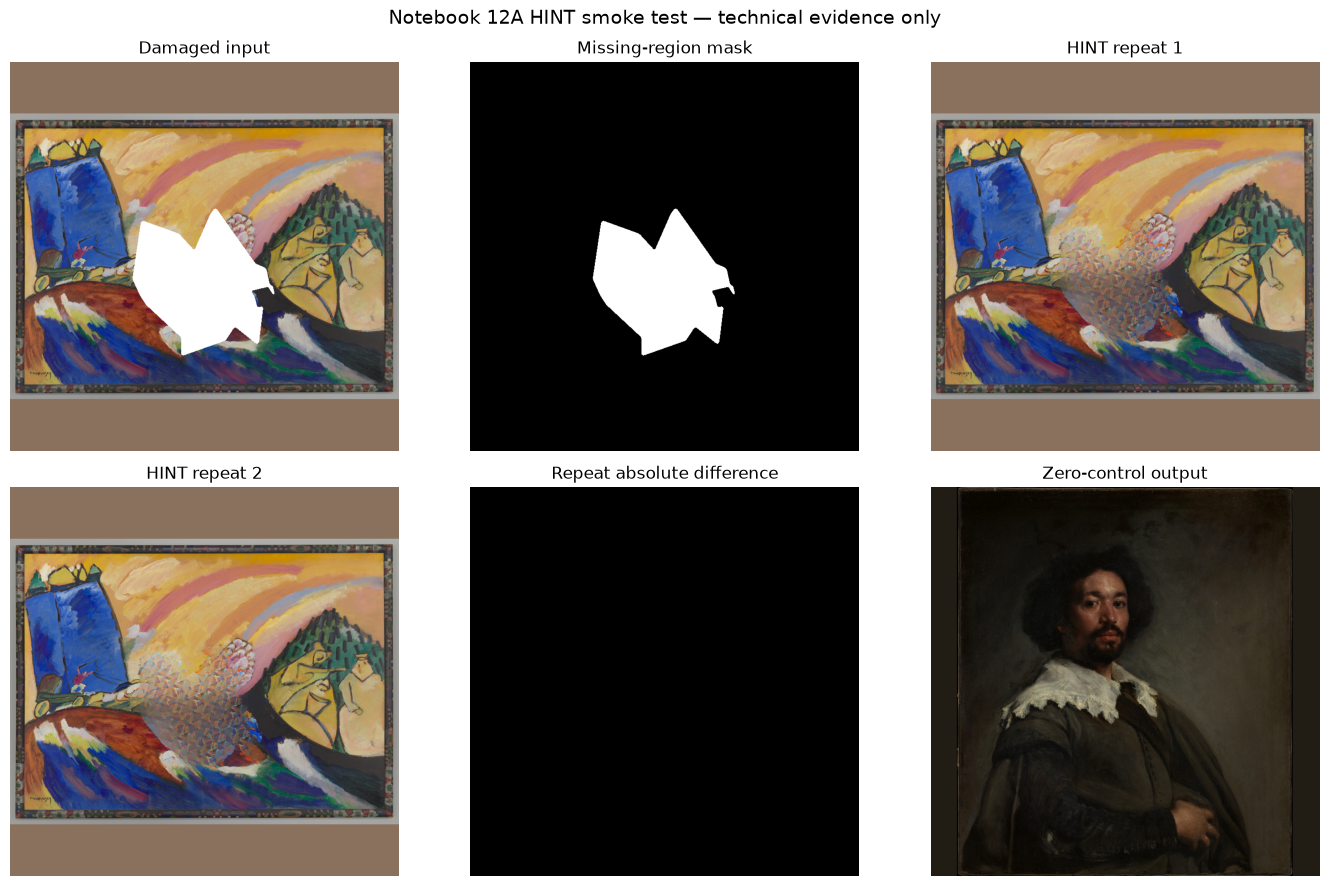

In [11]:
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Reload smoke images and measure repeatability and exact compositing
# ---------------------------------------------------------------------------

SMOKE_FILE_AUDIT = []

for row in SMOKE_ROWS.to_dict("records"):
    output_path = resolve_project_file(
        row["restored_path"]
    )
    audit = {
        "candidate_id": str(row["candidate_id"]),
        "case_id": str(row["case_id"]),
        "execution_action": str(
            row["execution_action"]
        ),
        "output_exists": output_path.is_file(),
        "mode": "",
        "width": 0,
        "height": 0,
        "sha256_matches": False,
    }

    if output_path.is_file():
        with Image.open(output_path) as handle:
            audit.update(
                {
                    "mode": str(handle.mode),
                    "width": int(handle.width),
                    "height": int(handle.height),
                }
            )

        audit["sha256_matches"] = (
            sha256_file(output_path)
            == str(row["restored_sha256"])
        )

    SMOKE_FILE_AUDIT.append(audit)

SMOKE_FILE_AUDIT = pd.DataFrame(
    SMOKE_FILE_AUDIT,
    columns=[
        "candidate_id",
        "case_id",
        "execution_action",
        "output_exists",
        "mode",
        "width",
        "height",
        "sha256_matches",
    ],
)

inference_rows = SMOKE_ROWS.loc[
    SMOKE_ROWS["execution_action"].eq("hint_inpaint")
].sort_values("candidate_id", kind="stable")

zero_rows = SMOKE_ROWS.loc[
    SMOKE_ROWS["execution_action"].eq("identity_noop")
]

SMOKE_REPEAT_SHA256_EQUAL = False
SMOKE_REPEAT_DIFFERENT_PIXELS = None
SMOKE_INFERENCE_CHANGED_MASK_PIXELS = []
SMOKE_ZERO_IDENTITY = False

if len(inference_rows) == 2 and all(
    resolve_project_file(path).is_file()
    for path in inference_rows["restored_path"]
):
    repeat_arrays = []

    for path in inference_rows["restored_path"]:
        with Image.open(
            resolve_project_file(path)
        ) as handle:
            repeat_arrays.append(
                np.asarray(
                    handle.convert("RGB"),
                    dtype=np.uint8,
                )
            )

    SMOKE_REPEAT_SHA256_EQUAL = (
        inference_rows["restored_sha256"].nunique() == 1
    )
    SMOKE_REPEAT_DIFFERENT_PIXELS = int(
        np.any(
            repeat_arrays[0] != repeat_arrays[1],
            axis=2,
        ).sum()
    )

    inference_input_path = resolve_project_file(
        inference_rows.iloc[0]["input_image_path"]
    )
    inference_mask_path = resolve_project_file(
        inference_rows.iloc[0]["mask_path"]
    )

    with Image.open(inference_input_path) as handle:
        inference_input = np.asarray(
            handle.convert("RGB"),
            dtype=np.uint8,
        )

    with Image.open(inference_mask_path) as handle:
        inference_mask = (
            np.asarray(
                handle.convert("L"),
                dtype=np.uint8,
            )
            >= int(
                inference_rows.iloc[0]["mask_threshold"]
            )
        )

    SMOKE_INFERENCE_CHANGED_MASK_PIXELS = [
        int(
            np.any(
                result != inference_input,
                axis=2,
            )[inference_mask].sum()
        )
        for result in repeat_arrays
    ]

if len(zero_rows) == 1:
    zero_row = zero_rows.iloc[0]
    zero_input_path = resolve_project_file(
        zero_row["input_image_path"]
    )
    zero_output_path = resolve_project_file(
        zero_row["restored_path"]
    )

    if (
        zero_input_path.is_file()
        and zero_output_path.is_file()
    ):
        with Image.open(zero_input_path) as handle:
            zero_input = np.asarray(
                handle.convert("RGB"),
                dtype=np.uint8,
            )

        with Image.open(zero_output_path) as handle:
            zero_output = np.asarray(
                handle.convert("RGB"),
                dtype=np.uint8,
            )

        SMOKE_ZERO_IDENTITY = bool(
            np.array_equal(zero_input, zero_output)
        )

print("Smoke output audit:")
display(SMOKE_FILE_AUDIT)

print("\nSmoke worker rows:")
display(
    SMOKE_ROWS[
        [
            "case_id",
            "execution_action",
            "status",
            "model_load_seconds",
            "inference_seconds",
            "runtime_seconds",
            "gpu_peak_memory_bytes",
            "output_geometry_valid",
            "outside_mask_changed_pixels",
            "technical_validation_passed",
            "failure_type",
        ]
    ]
)

print(
    "\nRepeat SHA-256 equality:",
    SMOKE_REPEAT_SHA256_EQUAL,
)
print(
    "Repeat different pixels:",
    SMOKE_REPEAT_DIFFERENT_PIXELS,
)
print(
    "Changed pixels inside inference mask:",
    SMOKE_INFERENCE_CHANGED_MASK_PIXELS,
)
print(
    "Zero-control pixel identity:",
    SMOKE_ZERO_IDENTITY,
)


# ---------------------------------------------------------------------------
# Compact rendered smoke comparison
# ---------------------------------------------------------------------------

if (
    len(inference_rows) == 2
    and len(zero_rows) == 1
    and SMOKE_FILE_AUDIT["output_exists"].all()
):
    absolute_difference = np.abs(
        repeat_arrays[0].astype(np.int16)
        - repeat_arrays[1].astype(np.int16)
    ).astype(np.uint8)

    panels = [
        (inference_input, "Damaged input"),
        (inference_mask, "Missing-region mask"),
        (repeat_arrays[0], "HINT repeat 1"),
        (repeat_arrays[1], "HINT repeat 2"),
        (
            absolute_difference,
            "Repeat absolute difference",
        ),
        (zero_output, "Zero-control output"),
    ]

    figure, axes = plt.subplots(
        2,
        3,
        figsize=(14, 9),
    )

    for axis, (panel, title) in zip(
        axes.ravel(),
        panels,
    ):
        axis.imshow(
            panel,
            cmap="gray" if panel.ndim == 2 else None,
        )
        axis.set_title(title)
        axis.axis("off")

    figure.suptitle(
        "Notebook 12A HINT smoke test — "
        "technical evidence only",
        fontsize=14,
    )
    figure.tight_layout()
    plt.show()
else:
    print(
        "Smoke comparison not rendered because "
        "required outputs are missing."
    )

In [12]:
# ---------------------------------------------------------------------------
# Rerunnable Batch 3 validation
# ---------------------------------------------------------------------------

BATCH_3_STAGE = "batch_3_representative_smoke_test"
prior_checks = [
    check
    for check in VALIDATION.checks
    if check.validation_stage != BATCH_3_STAGE
]
VALIDATION = ValidationCollector()
VALIDATION.extend(prior_checks)


def add_batch_3_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    *,
    severity="blocking",
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_3_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_3_check(
    "isolated_worker_completion",
    "The bounded HINT smoke worker completes without "
    "timeout or process error.",
    {
        "timed_out": False,
        "return_code": 0,
        "status": "completed",
    },
    {
        "timed_out": SMOKE_PROCESS.timed_out,
        "timeout_reason": SMOKE_PROCESS.timeout_reason,
        "return_code": SMOKE_PROCESS.return_code,
        "status": SMOKE_RESULT.get(
            "status",
            "missing",
        ),
    },
    not SMOKE_PROCESS.timed_out
    and SMOKE_PROCESS.return_code == 0
    and SMOKE_RESULT.get("status") == "completed",
)

status_counts = {
    str(key): int(value)
    for key, value in SMOKE_ROWS[
        "status"
    ].value_counts().items()
}

add_batch_3_check(
    "smoke_row_resolution",
    "Both inference repeats and the zero control "
    "resolve successfully.",
    {
        "rows": 3,
        "completed": 3,
    },
    {
        "rows": int(len(SMOKE_ROWS)),
        "completed": int(
            status_counts.get("completed", 0)
        ),
    },
    len(SMOKE_ROWS) == 3
    and status_counts == {"completed": 3},
)

file_gate = bool(
    len(SMOKE_FILE_AUDIT) == 3
    and SMOKE_FILE_AUDIT["output_exists"].all()
    and SMOKE_FILE_AUDIT["mode"].eq("RGB").all()
    and SMOKE_FILE_AUDIT["width"].eq(768).all()
    and SMOKE_FILE_AUDIT["height"].eq(768).all()
    and SMOKE_FILE_AUDIT["sha256_matches"].all()
)

add_batch_3_check(
    "smoke_output_files",
    "All smoke outputs are readable RGB 768 x 768 "
    "PNGs with matching hashes.",
    {
        "rows": 3,
        "all_exist": True,
        "mode": "RGB",
        "size": [768, 768],
        "hashes_match": True,
    },
    {
        "rows": int(len(SMOKE_FILE_AUDIT)),
        "all_exist": bool(
            len(SMOKE_FILE_AUDIT) == 3
            and SMOKE_FILE_AUDIT[
                "output_exists"
            ].all()
        ),
        "modes": sorted(
            SMOKE_FILE_AUDIT["mode"].unique().tolist()
        ),
        "sizes": sorted(
            {
                (int(row.width), int(row.height))
                for row in SMOKE_FILE_AUDIT.itertuples(
                    index=False
                )
            }
        ),
        "hashes_match": bool(
            len(SMOKE_FILE_AUDIT) == 3
            and SMOKE_FILE_AUDIT[
                "sha256_matches"
            ].all()
        ),
    },
    file_gate,
)

technical_values = (
    SMOKE_ROWS["technical_validation_passed"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)
outside_values = pd.to_numeric(
    SMOKE_ROWS["outside_mask_changed_pixels"],
    errors="coerce",
)

add_batch_3_check(
    "exact_outside_mask_preservation",
    "Every smoke output preserves all pixels outside "
    "its permitted mask.",
    {
        "all_technical_checks_pass": True,
        "maximum_outside_changed_pixels": 0,
    },
    {
        "all_technical_checks_pass": bool(
            technical_values.all()
        ),
        "maximum_outside_changed_pixels": (
            None
            if outside_values.isna().all()
            else int(outside_values.max())
        ),
    },
    len(SMOKE_ROWS) == 3
    and technical_values.all()
    and outside_values.notna().all()
    and outside_values.eq(0).all(),
)

add_batch_3_check(
    "deterministic_repeatability",
    "Repeated HINT inference with the fixed seed "
    "and configuration is exact.",
    {
        "sha256_equal": True,
        "different_pixels": 0,
    },
    {
        "sha256_equal": SMOKE_REPEAT_SHA256_EQUAL,
        "different_pixels": (
            SMOKE_REPEAT_DIFFERENT_PIXELS
        ),
    },
    SMOKE_REPEAT_SHA256_EQUAL
    and SMOKE_REPEAT_DIFFERENT_PIXELS == 0,
)

add_batch_3_check(
    "inference_changes_missing_region",
    "Each HINT repeat changes at least one pixel "
    "inside the missing region.",
    "> 0 changed masked pixels for both repeats",
    SMOKE_INFERENCE_CHANGED_MASK_PIXELS,
    len(SMOKE_INFERENCE_CHANGED_MASK_PIXELS) == 2
    and all(
        value > 0
        for value in SMOKE_INFERENCE_CHANGED_MASK_PIXELS
    ),
)

add_batch_3_check(
    "zero_control_identity",
    "The zero-control output remains exactly identical "
    "to its input in pixels.",
    True,
    SMOKE_ZERO_IDENTITY,
    SMOKE_ZERO_IDENTITY,
)

smoke_paths_owned = bool(
    len(SMOKE_FILE_AUDIT) == 3
    and all(
        resolve_project_file(path).is_relative_to(
            SMOKE_WORK_ROOT.resolve()
        )
        for path in SMOKE_ROWS["restored_path"]
    )
)

add_batch_3_check(
    "smoke_output_isolation",
    "Smoke images stay in work/smoke and cannot be "
    "counted as canonical output.",
    True,
    smoke_paths_owned,
    smoke_paths_owned,
)

In [13]:
# ---------------------------------------------------------------------------
# Batch 3 completion gate
# ---------------------------------------------------------------------------

BATCH_3_CHECKS = VALIDATION.to_dataframe().loc[
    lambda frame: frame["validation_stage"].eq(
        BATCH_3_STAGE
    )
].reset_index(drop=True)

print("Batch 3 validation checks:")
display(
    BATCH_3_CHECKS[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

batch_3_failures = BATCH_3_CHECKS.loc[
    BATCH_3_CHECKS["severity"].eq("blocking")
    & ~BATCH_3_CHECKS["passed"]
]

print("\nBatch 3 completed.")
print("Checks:", len(BATCH_3_CHECKS))
print(
    "Passed:",
    int(BATCH_3_CHECKS["passed"].sum()),
)
print(
    "Blocking failures:",
    len(batch_3_failures),
)
print(
    "Smoke worker wall time seconds:",
    SMOKE_PROCESS.runtime_seconds,
)
print(
    "Repeat outputs identical:",
    SMOKE_REPEAT_SHA256_EQUAL,
)
print(
    "Outside-mask changed pixels:",
    outside_values.tolist(),
)
print(
    "Zero-control identity:",
    SMOKE_ZERO_IDENTITY,
)
print(
    "Canonical restoration files written by Batch 3: 0"
)
print(
    "Next approved stage: Batch 4 - guarded full HINT "
    "execution with ten-case progress, atomic "
    "checkpointing, checksum-aware resume, per-case "
    "stall protection, and an eight-hour upper "
    "process budget."
)

VALIDATION.raise_for_blocking()

Batch 3 validation checks:


,check_id,severity,expected,observed,passed
0,isolated_worker_completion,blocking,"{""return_code"": 0, ""status"": ""completed"", ""tim...","{""return_code"": 0, ""status"": ""completed"", ""tim...",True
1,smoke_row_resolution,blocking,"{""completed"": 3, ""rows"": 3}","{""completed"": 3, ""rows"": 3}",True
2,smoke_output_files,blocking,"{""all_exist"": true, ""hashes_match"": true, ""mod...","{""all_exist"": true, ""hashes_match"": true, ""mod...",True
3,exact_outside_mask_preservation,blocking,"{""all_technical_checks_pass"": true, ""maximum_o...","{""all_technical_checks_pass"": true, ""maximum_o...",True
4,deterministic_repeatability,blocking,"{""different_pixels"": 0, ""sha256_equal"": true}","{""different_pixels"": 0, ""sha256_equal"": true}",True
5,inference_changes_missing_region,blocking,> 0 changed masked pixels for both repeats,"[49001, 49001]",True
6,zero_control_identity,blocking,True,True,True
7,smoke_output_isolation,blocking,True,True,True



Batch 3 completed.
Checks: 8
Passed: 8
Blocking failures: 0
Smoke worker wall time seconds: 33.03
Repeat outputs identical: True
Outside-mask changed pixels: [0, 0, 0]
Zero-control identity: True
Canonical restoration files written by Batch 3: 0
Next approved stage: Batch 4 - guarded full HINT execution with ten-case progress, atomic checkpointing, checksum-aware resume, per-case stall protection, and an eight-hour upper process budget.


## Batch 4 — Guarded full HINT execution

This batch runs the complete 2,620-case HINT production plan in an isolated process.

- The model is loaded once and receives 2,320 nonzero inference cases plus 300 identity zero controls.
- Progress is displayed every ten resolved cases.
- An atomic checkpoint is written every ten cases and immediately after any failure.
- A rerun preserves checksum-valid completed rows and retained failures, then continues unresolved cases.
- Failed cases are never retried automatically.
- The parent process stops the worker if model loading or one case stalls for 15 minutes, or if the total run exceeds eight hours.
- Canonical images are written only below `images/restored/<experiment_id>/`.

Based on the smoke test and D01 measurements, the expected local runtime is approximately four to six hours. Keep the laptop connected to power and prevent Windows sleep while this cell runs. A kernel, application, or system interruption should lose at most the work since the most recent ten-case checkpoint.

In [15]:
import subprocess
import time


# ---------------------------------------------------------------------------
# Re-audit any production checkpoint before constructing the worker job
# ---------------------------------------------------------------------------


def audit_production_checkpoint(checkpoint_path, plan):
    expected_columns = list(HINT_WORK_COLUMNS)
    plan_by_candidate = plan.set_index(
        "candidate_id",
        drop=False,
    )
    issues = []

    if not checkpoint_path.is_file():
        return (
            pd.DataFrame(columns=expected_columns),
            {
                "checkpoint_exists": False,
                "resolved_rows": 0,
                "completed_rows": 0,
                "failed_rows": 0,
                "issue_count": 0,
                "issues": [],
            },
        )

    rows = pd.read_csv(
        checkpoint_path,
        keep_default_na=False,
    )

    if list(rows.columns) != expected_columns:
        issues.append("checkpoint_columns_do_not_match")
        return (
            rows,
            {
                "checkpoint_exists": True,
                "resolved_rows": int(len(rows)),
                "completed_rows": 0,
                "failed_rows": 0,
                "issue_count": len(issues),
                "issues": issues,
            },
        )

    if rows["candidate_id"].duplicated().any():
        issues.append(
            "duplicate_checkpoint_candidate_id"
        )

    for row in rows.to_dict("records"):
        candidate_id = str(row["candidate_id"])
        status = str(row["status"])

        if candidate_id not in plan_by_candidate.index:
            issues.append(
                f"unknown_candidate:{candidate_id}"
            )
            continue

        if status not in {"completed", "failed"}:
            issues.append(
                f"invalid_status:{candidate_id}:{status}"
            )
            continue

        planned = plan_by_candidate.loc[candidate_id]

        if str(row["input_sha256"]) != str(
            planned["input_sha256"]
        ):
            issues.append(
                f"stale_input:{candidate_id}"
            )

        if str(row["mask_sha256"]) != str(
            planned["mask_sha256"]
        ):
            issues.append(
                f"stale_mask:{candidate_id}"
            )

        if status == "completed":
            output_path = resolve_project_file(
                row["restored_path"]
            )
            recorded_hash = str(
                row["restored_sha256"]
            )

            if not output_path.is_file():
                issues.append(
                    f"missing_output:{candidate_id}"
                )
            elif not recorded_hash:
                issues.append(
                    f"missing_output_hash:{candidate_id}"
                )
            elif sha256_file(output_path) != recorded_hash:
                issues.append(
                    f"changed_output:{candidate_id}"
                )

    status_counts = (
        rows["status"].value_counts().to_dict()
    )
    audit = {
        "checkpoint_exists": True,
        "resolved_rows": int(len(rows)),
        "completed_rows": int(
            status_counts.get("completed", 0)
        ),
        "failed_rows": int(
            status_counts.get("failed", 0)
        ),
        "issue_count": int(len(issues)),
        "issues": issues[:20],
    }

    return rows, audit


(
    FULL_CHECKPOINT_BEFORE,
    FULL_RESUME_AUDIT,
) = audit_production_checkpoint(
    OUTPUTS["checkpoint"],
    HINT_PLAN,
)

if FULL_RESUME_AUDIT["issue_count"]:
    raise ValueError(
        "The production checkpoint is stale or invalid: "
        f"{FULL_RESUME_AUDIT['issues']}"
    )

FULL_JOB, FULL_JOB_PATHS = build_worker_job(
    HINT_PLAN,
    hint_config,
    project_root=PROJECT_ROOT,
    notebook_output_root=OUTPUT_ROOT,
)

(
    FULL_JOB_PATH,
    FULL_RESULT_PATH,
    FULL_CHECKPOINT_PATH,
    FULL_PROGRESS_PATH,
) = FULL_JOB_PATHS

FULL_STDOUT_PATH = (
    OUTPUT_ROOT / "work" / "worker_stdout.log"
)
FULL_STDERR_PATH = (
    OUTPUT_ROOT / "work" / "worker_stderr.log"
)

job_candidate_ids = [
    str(row["candidate_id"])
    for row in FULL_JOB["candidates"]
]
plan_candidate_ids = (
    HINT_PLAN["candidate_id"].astype(str).tolist()
)

FULL_JOB_READY = bool(
    len(FULL_JOB["candidates"])
    == int(EXPECTED_COUNTS["eligible_case_count"])
    and job_candidate_ids == plan_candidate_ids
    and all(
        Path(
            str(row["restored_path"])
        ).is_relative_to(
            OUTPUTS["restored_images"].resolve()
        )
        for row in FULL_JOB["candidates"]
    )
    and int(
        FULL_JOB["execution"][
            "progress_interval_cases"
        ]
    )
    == 10
    and int(
        FULL_JOB["execution"][
            "checkpoint_interval_cases"
        ]
    )
    == 10
    and not bool(
        FULL_JOB["execution"][
            "retry_failed_attempts"
        ]
    )
)

print(
    "Full production candidates:",
    len(FULL_JOB["candidates"]),
)
print(
    "Checkpoint state before execution:",
    FULL_RESUME_AUDIT,
)
print(
    "Full worker job:",
    to_repo_relative(
        FULL_JOB_PATH,
        PROJECT_ROOT,
    ),
)
print(
    "Full checkpoint:",
    to_repo_relative(
        FULL_CHECKPOINT_PATH,
        PROJECT_ROOT,
    ),
)
print(
    "Progress interval:",
    FULL_JOB["execution"][
        "progress_interval_cases"
    ],
)
print(
    "Checkpoint interval:",
    FULL_JOB["execution"][
        "checkpoint_interval_cases"
    ],
)
print(
    "Automatic failed-case retries:",
    FULL_JOB["execution"][
        "retry_failed_attempts"
    ],
)
print(
    "Eight-hour upper budget:",
    FULL_JOB["execution"][
        "full_run_budget_seconds"
    ],
)
print("Full job ready:", FULL_JOB_READY)

if not FULL_JOB_READY:
    raise ValueError(
        "The full HINT worker job does not match "
        "the approved contract"
    )

Full production candidates: 2620
Checkpoint state before execution: {'checkpoint_exists': False, 'resolved_rows': 0, 'completed_rows': 0, 'failed_rows': 0, 'issue_count': 0, 'issues': []}
Full worker job: outputs/12a_hint_restoration/work/job.json
Full checkpoint: outputs/12a_hint_restoration/work/restoration_checkpoint.csv
Progress interval: 10
Checkpoint interval: 10
Automatic failed-case retries: False
Eight-hour upper budget: 28800
Full job ready: True


In [16]:
# ---------------------------------------------------------------------------
# Execute or resume with live progress and three independent guards
# ---------------------------------------------------------------------------


def read_json_if_available(path):
    try:
        with path.open(
            "r",
            encoding="utf-8-sig",
        ) as handle:
            return json.load(handle)
    except (
        FileNotFoundError,
        json.JSONDecodeError,
        OSError,
    ):
        return {}


expected_total = int(
    EXPECTED_COUNTS["eligible_case_count"]
)
resolved_before = int(
    FULL_RESUME_AUDIT["resolved_rows"]
)
FULL_EXECUTION_NEEDED = (
    resolved_before < expected_total
)

FULL_EXECUTION_SKIPPED = (
    not FULL_EXECUTION_NEEDED
)
FULL_PROCESS_TIMED_OUT = False
FULL_PROCESS_TIMEOUT_REASON = ""
FULL_PROCESS_RETURN_CODE = None
FULL_PROCESS_RUNTIME_SECONDS = 0.0

if FULL_EXECUTION_NEEDED:
    FULL_RESULT_PATH.unlink(missing_ok=True)
    FULL_PROGRESS_PATH.unlink(missing_ok=True)
    FULL_STDOUT_PATH.unlink(missing_ok=True)
    FULL_STDERR_PATH.unlink(missing_ok=True)

    command = worker_command(FULL_JOB_PATH)
    global_limit = float(
        hint_config["execution"][
            "full_run_budget_seconds"
        ]
    )
    startup_limit = float(
        hint_config["execution"][
            "model_load_timeout_seconds"
        ]
    )
    stall_limit = float(
        hint_config["execution"][
            "per_case_timeout_seconds"
        ]
    )
    poll_seconds = float(
        hint_config["execution"][
            "progress_poll_seconds"
        ]
    )

    print(
        "Starting guarded full HINT execution..."
    )
    print(
        "Expected runtime: approximately 4-6 hours"
    )
    print(
        "Already resolved from checkpoint:",
        resolved_before,
    )
    print(
        "Global budget hours:",
        round(global_limit / 3600, 2),
    )
    print(
        "Progress will print every 10 resolved cases.\n"
    )

    process_started = perf_counter()
    last_progress_at = process_started
    progress_seen = False
    last_progress_signature = None
    last_printed_resolved = -1

    with FULL_STDOUT_PATH.open(
        "w",
        encoding="utf-8",
        newline="\n",
    ) as stdout_handle, FULL_STDERR_PATH.open(
        "w",
        encoding="utf-8",
        newline="\n",
    ) as stderr_handle:
        process = subprocess.Popen(
            command,
            cwd=str(PROJECT_ROOT),
            env=SMOKE_ENVIRONMENT,
            stdout=stdout_handle,
            stderr=stderr_handle,
            text=True,
        )

        try:
            while process.poll() is None:
                now = perf_counter()

                if (
                    now - process_started
                    > global_limit
                ):
                    FULL_PROCESS_TIMED_OUT = True
                    FULL_PROCESS_TIMEOUT_REASON = (
                        "global_budget_exceeded"
                    )
                    process.kill()
                    break

                if FULL_PROGRESS_PATH.is_file():
                    stat = FULL_PROGRESS_PATH.stat()
                    signature = (
                        int(stat.st_mtime_ns),
                        int(stat.st_size),
                    )

                    if (
                        signature
                        != last_progress_signature
                    ):
                        last_progress_signature = (
                            signature
                        )
                        last_progress_at = now
                        progress_seen = True
                        progress = (
                            read_json_if_available(
                                FULL_PROGRESS_PATH
                            )
                        )

                        stage = str(
                            progress.get("stage", "")
                        )
                        resolved = int(
                            progress.get(
                                "resolved_cases",
                                0,
                            )
                        )
                        successful = int(
                            progress.get(
                                "successful_cases",
                                0,
                            )
                        )

                        if (
                            stage == "model_loaded"
                            and last_printed_resolved < 0
                        ):
                            print(
                                "HINT model loaded; "
                                "case execution started."
                            )
                            last_printed_resolved = 0

                        elif (
                            resolved == expected_total
                            or resolved % 10 == 0
                        ) and (
                            resolved
                            != last_printed_resolved
                        ):
                            elapsed_hours = (
                                now - process_started
                            ) / 3600

                            print(
                                f"HINT progress "
                                f"{resolved}/"
                                f"{expected_total} | "
                                f"completed "
                                f"{successful} | "
                                f"elapsed "
                                f"{elapsed_hours:.2f} h"
                            )
                            last_printed_resolved = (
                                resolved
                            )

                applicable_limit = (
                    stall_limit
                    if progress_seen
                    else startup_limit
                )

                if (
                    now - last_progress_at
                    > applicable_limit
                ):
                    FULL_PROCESS_TIMED_OUT = True
                    FULL_PROCESS_TIMEOUT_REASON = (
                        "case_progress_stalled"
                        if progress_seen
                        else "model_load_stalled"
                    )
                    process.kill()
                    break

                time.sleep(
                    max(0.1, poll_seconds)
                )

        except BaseException:
            if process.poll() is None:
                process.kill()

            process.wait(timeout=30)
            raise

        FULL_PROCESS_RETURN_CODE = (
            process.wait(timeout=30)
        )

    FULL_PROCESS_RUNTIME_SECONDS = round(
        perf_counter() - process_started,
        3,
    )

else:
    FULL_PROCESS_RETURN_CODE = 0
    print(
        "The checkpoint already resolves all 2,620 "
        "candidates; the worker was not launched again."
    )

stdout_lines = (
    FULL_STDOUT_PATH.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()
    if FULL_STDOUT_PATH.is_file()
    else []
)
stderr_lines = (
    FULL_STDERR_PATH.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()
    if FULL_STDERR_PATH.is_file()
    else []
)

print("\nFull execution finished or stopped.")
print(
    "Worker launched:",
    FULL_EXECUTION_NEEDED,
)
print(
    "Return code:",
    FULL_PROCESS_RETURN_CODE,
)
print(
    "Timed out:",
    FULL_PROCESS_TIMED_OUT,
)
print(
    "Timeout reason:",
    FULL_PROCESS_TIMEOUT_REASON or "none",
)
print(
    "Parent wall time seconds:",
    FULL_PROCESS_RUNTIME_SECONDS,
)

if stdout_lines:
    print("\nFinal worker output lines:")
    print("\n".join(stdout_lines[-12:]))

if stderr_lines:
    print("\nFinal worker diagnostics:")
    print("\n".join(stderr_lines[-20:]))

Starting guarded full HINT execution...
Expected runtime: approximately 4-6 hours
Already resolved from checkpoint: 0
Global budget hours: 8.0
Progress will print every 10 resolved cases.

HINT model loaded; case execution started.
HINT progress 10/2620 | completed 10 | elapsed 0.02 h
HINT progress 20/2620 | completed 20 | elapsed 0.03 h
HINT progress 30/2620 | completed 30 | elapsed 0.05 h
HINT progress 40/2620 | completed 40 | elapsed 0.07 h
HINT progress 50/2620 | completed 50 | elapsed 0.08 h
HINT progress 60/2620 | completed 60 | elapsed 0.10 h
HINT progress 70/2620 | completed 70 | elapsed 0.12 h
HINT progress 80/2620 | completed 80 | elapsed 0.14 h
HINT progress 90/2620 | completed 90 | elapsed 0.16 h
HINT progress 100/2620 | completed 100 | elapsed 0.17 h
HINT progress 110/2620 | completed 110 | elapsed 0.19 h
HINT progress 120/2620 | completed 120 | elapsed 0.21 h
HINT progress 130/2620 | completed 130 | elapsed 0.23 h
HINT progress 140/2620 | completed 140 | elapsed 0.25 h
HI

In [17]:
# ---------------------------------------------------------------------------
# Reload checkpoint, result, progress, and image population
# ---------------------------------------------------------------------------

FULL_RESULT = read_json_if_available(
    FULL_RESULT_PATH
)
FULL_PROGRESS = read_json_if_available(
    FULL_PROGRESS_PATH
)

if FULL_CHECKPOINT_PATH.is_file():
    FULL_ROWS = pd.read_csv(
        FULL_CHECKPOINT_PATH,
        keep_default_na=False,
    ).reindex(columns=HINT_WORK_COLUMNS)
else:
    FULL_ROWS = pd.DataFrame(
        columns=HINT_WORK_COLUMNS
    )

FULL_STATUS_COUNTS = {
    str(key): int(value)
    for key, value in FULL_ROWS[
        "status"
    ].value_counts().items()
}
FULL_IMAGE_PATHS = sorted(
    OUTPUTS["restored_images"].rglob("*.png")
)

FULL_RUNTIME_BY_EXPERIMENT = (
    FULL_ROWS.assign(
        runtime_numeric=pd.to_numeric(
            FULL_ROWS["runtime_seconds"],
            errors="coerce",
        ),
        inference_numeric=pd.to_numeric(
            FULL_ROWS["inference_seconds"],
            errors="coerce",
        ),
    )
    .groupby(
        [
            "experiment_id",
            "execution_action",
        ],
        dropna=False,
        sort=True,
    )
    .agg(
        resolved_cases=("case_id", "size"),
        completed_cases=(
            "status",
            lambda values: int(
                values.eq("completed").sum()
            ),
        ),
        failed_cases=(
            "status",
            lambda values: int(
                values.eq("failed").sum()
            ),
        ),
        total_runtime_seconds=(
            "runtime_numeric",
            "sum",
        ),
        mean_runtime_seconds=(
            "runtime_numeric",
            "mean",
        ),
        mean_inference_seconds=(
            "inference_numeric",
            "mean",
        ),
    )
    .reset_index()
)

expected_ids = set(
    HINT_PLAN["candidate_id"].astype(str)
)
resolved_ids = set(
    FULL_ROWS["candidate_id"].astype(str)
)

print(
    "Resolved production rows:",
    len(FULL_ROWS),
)
print(
    "Status counts:",
    FULL_STATUS_COUNTS,
)
print(
    "Canonical restored PNG files:",
    len(FULL_IMAGE_PATHS),
)
print(
    "Missing candidate IDs:",
    len(expected_ids - resolved_ids),
)
print(
    "Unexpected candidate IDs:",
    len(resolved_ids - expected_ids),
)
print(
    "Worker result status:",
    FULL_RESULT.get("status", "missing"),
)
print(
    "Final progress state:",
    FULL_PROGRESS,
)

print("\nRuntime by experiment and action:")
display(FULL_RUNTIME_BY_EXPERIMENT)

if not FULL_ROWS.empty:
    print("\nFinal resolved rows:")
    display(
        FULL_ROWS.tail(10)[
            [
                "case_id",
                "experiment_id",
                "execution_action",
                "status",
                "runtime_seconds",
                "inference_seconds",
                "technical_validation_passed",
                "failure_type",
            ]
        ]
    )

Resolved production rows: 2620
Status counts: {'completed': 2620}
Canonical restored PNG files: 2620
Missing candidate IDs: 0
Unexpected candidate IDs: 0
Worker result status: completed
Final progress state: {'stage': 'case_resolved', 'resolved_cases': 2620, 'total_cases': 2620, 'successful_cases': 2620, 'current_case_id': 'synthetic_degradation__p294__water_stain_dirt__moderate', 'updated_at_utc': '2026-09-13T21:57:19.886237Z'}

Runtime by experiment and action:


,experiment_id,execution_action,resolved_cases,completed_cases,failed_cases,total_runtime_seconds,mean_runtime_seconds,mean_inference_seconds
0,canonical_missing_region,hint_inpaint,1200,1200,0,8275.887,6.896573,6.486637
1,canonical_missing_region,identity_noop,300,300,0,159.837,0.532790,0.000000
2,damage_size_sensitivity,hint_inpaint,245,245,0,1649.883,6.734216,6.350792
3,mask_robustness,hint_inpaint,525,525,0,3604.432,6.865585,6.474145
4,synthetic_degradation,hint_inpaint,350,350,0,2335.711,6.673460,6.294506



Final resolved rows:


,case_id,experiment_id,execution_action,status,runtime_seconds,inference_seconds,technical_validation_passed,failure_type
2610,synthetic_degradation__p294__dirt_dust__mild,synthetic_degradation,hint_inpaint,completed,7.360,7.024,True,none
2611,synthetic_degradation__p294__dirt_dust__moderate,synthetic_degradation,hint_inpaint,completed,6.605,6.256,True,none
2612,synthetic_degradation__p294__dirt_dust__severe,synthetic_degradation,hint_inpaint,completed,6.895,6.558,True,none
2613,synthetic_degradation__p294__partial_transpare...,synthetic_degradation,hint_inpaint,completed,6.735,6.403,True,none
2614,synthetic_degradation__p294__partial_transpare...,synthetic_degradation,hint_inpaint,completed,6.705,6.382,True,none
2615,synthetic_degradation__p294__partial_transpare...,synthetic_degradation,hint_inpaint,completed,6.445,6.131,True,none
2616,synthetic_degradation__p294__water_stain__mild,synthetic_degradation,hint_inpaint,completed,6.855,6.517,True,none
2617,synthetic_degradation__p294__water_stain__mode...,synthetic_degradation,hint_inpaint,completed,6.627,6.289,True,none
2618,synthetic_degradation__p294__water_stain__severe,synthetic_degradation,hint_inpaint,completed,6.719,6.381,True,none
2619,synthetic_degradation__p294__water_stain_dirt_...,synthetic_degradation,hint_inpaint,completed,7.072,6.723,True,none


In [18]:
# ---------------------------------------------------------------------------
# Rerunnable Batch 4 validation and completion gate
# ---------------------------------------------------------------------------

BATCH_4_STAGE = "batch_4_guarded_full_execution"
prior_checks = [
    check
    for check in VALIDATION.checks
    if check.validation_stage != BATCH_4_STAGE
]
VALIDATION = ValidationCollector()
VALIDATION.extend(prior_checks)


def add_batch_4_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    *,
    severity="blocking",
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_4_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_total = int(
    EXPECTED_COUNTS["eligible_case_count"]
)

add_batch_4_check(
    "worker_process_completion",
    "The full worker finishes within all "
    "parent-process guards.",
    {
        "return_code": 0,
        "timed_out": False,
    },
    {
        "return_code": FULL_PROCESS_RETURN_CODE,
        "timed_out": FULL_PROCESS_TIMED_OUT,
        "timeout_reason": (
            FULL_PROCESS_TIMEOUT_REASON
        ),
        "execution_skipped_as_complete": (
            FULL_EXECUTION_SKIPPED
        ),
    },
    FULL_PROCESS_RETURN_CODE == 0
    and not FULL_PROCESS_TIMED_OUT,
)

add_batch_4_check(
    "worker_result_completion",
    "The worker result resolves the complete "
    "production plan.",
    {
        "status": "completed",
        "resolved_rows": expected_total,
        "successful_rows": expected_total,
    },
    {
        "status": FULL_RESULT.get(
            "status",
            "missing",
        ),
        "resolved_rows": FULL_RESULT.get(
            "resolved_rows"
        ),
        "successful_rows": FULL_RESULT.get(
            "successful_rows"
        ),
    },
    FULL_RESULT.get("status") == "completed"
    and int(
        FULL_RESULT.get("resolved_rows", -1)
    )
    == expected_total
    and int(
        FULL_RESULT.get("successful_rows", -1)
    )
    == expected_total,
)

add_batch_4_check(
    "checkpoint_population",
    "The atomic checkpoint contains every "
    "planned candidate exactly once.",
    {
        "rows": expected_total,
        "unique_candidates": expected_total,
    },
    {
        "rows": int(len(FULL_ROWS)),
        "unique_candidates": int(
            FULL_ROWS["candidate_id"].nunique()
        ),
    },
    len(FULL_ROWS) == expected_total
    and FULL_ROWS["candidate_id"].nunique()
    == expected_total,
)

add_batch_4_check(
    "candidate_identity_reconciliation",
    "Checkpoint candidate identities exactly "
    "match the approved plan.",
    {
        "missing": 0,
        "unexpected": 0,
    },
    {
        "missing": int(
            len(expected_ids - resolved_ids)
        ),
        "unexpected": int(
            len(resolved_ids - expected_ids)
        ),
    },
    expected_ids == resolved_ids,
)

add_batch_4_check(
    "all_candidates_completed",
    "Every planned production candidate completed "
    "without a retained failure.",
    {
        "completed": expected_total,
        "failed": 0,
    },
    {
        "completed": int(
            FULL_STATUS_COUNTS.get(
                "completed",
                0,
            )
        ),
        "failed": int(
            FULL_STATUS_COUNTS.get(
                "failed",
                0,
            )
        ),
    },
    FULL_STATUS_COUNTS
    == {"completed": expected_total},
)

add_batch_4_check(
    "canonical_image_population",
    "Exactly one canonical restored PNG exists "
    "for every candidate.",
    expected_total,
    len(FULL_IMAGE_PATHS),
    len(FULL_IMAGE_PATHS) == expected_total,
)

progress_resolved = int(
    FULL_PROGRESS.get("resolved_cases", -1)
)
progress_successful = int(
    FULL_PROGRESS.get("successful_cases", -1)
)

add_batch_4_check(
    "final_progress_reconciliation",
    "The final progress record reconciles with "
    "the completed checkpoint.",
    {
        "resolved": expected_total,
        "successful": expected_total,
    },
    {
        "resolved": progress_resolved,
        "successful": progress_successful,
    },
    progress_resolved == expected_total
    and progress_successful == expected_total,
)

add_batch_4_check(
    "execution_policy",
    "Progress, checkpoint, timeout, and no-retry "
    "policies remain unchanged.",
    {
        "progress_interval": 10,
        "checkpoint_interval": 10,
        "model_load_timeout": 900,
        "per_case_timeout": 900,
        "global_budget": 28800,
        "retry_failed": False,
    },
    {
        "progress_interval": int(
            FULL_JOB["execution"][
                "progress_interval_cases"
            ]
        ),
        "checkpoint_interval": int(
            FULL_JOB["execution"][
                "checkpoint_interval_cases"
            ]
        ),
        "model_load_timeout": int(
            FULL_JOB["execution"][
                "model_load_timeout_seconds"
            ]
        ),
        "per_case_timeout": int(
            FULL_JOB["execution"][
                "per_case_timeout_seconds"
            ]
        ),
        "global_budget": int(
            FULL_JOB["execution"][
                "full_run_budget_seconds"
            ]
        ),
        "retry_failed": bool(
            FULL_JOB["execution"][
                "retry_failed_attempts"
            ]
        ),
    },
    int(
        FULL_JOB["execution"][
            "progress_interval_cases"
        ]
    )
    == 10
    and int(
        FULL_JOB["execution"][
            "checkpoint_interval_cases"
        ]
    )
    == 10
    and int(
        FULL_JOB["execution"][
            "model_load_timeout_seconds"
        ]
    )
    == 900
    and int(
        FULL_JOB["execution"][
            "per_case_timeout_seconds"
        ]
    )
    == 900
    and int(
        FULL_JOB["execution"][
            "full_run_budget_seconds"
        ]
    )
    == 28800
    and not bool(
        FULL_JOB["execution"][
            "retry_failed_attempts"
        ]
    ),
)

add_batch_4_check(
    "checkpoint_resume_audit",
    "Any checkpoint present before execution "
    "passed identity and checksum audit.",
    {"issue_count": 0},
    FULL_RESUME_AUDIT,
    FULL_RESUME_AUDIT["issue_count"] == 0,
)

BATCH_4_CHECKS = VALIDATION.to_dataframe().loc[
    lambda frame: frame["validation_stage"].eq(
        BATCH_4_STAGE
    )
].reset_index(drop=True)

print("Batch 4 validation checks:")
display(
    BATCH_4_CHECKS[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

batch_4_failures = BATCH_4_CHECKS.loc[
    BATCH_4_CHECKS["severity"].eq("blocking")
    & ~BATCH_4_CHECKS["passed"]
]

print("\nBatch 4 completed.")
print("Checks:", len(BATCH_4_CHECKS))
print(
    "Passed:",
    int(BATCH_4_CHECKS["passed"].sum()),
)
print(
    "Blocking failures:",
    len(batch_4_failures),
)
print(
    "Completed production candidates:",
    FULL_STATUS_COUNTS.get("completed", 0),
)
print(
    "Failed production candidates:",
    FULL_STATUS_COUNTS.get("failed", 0),
)
print(
    "Canonical restored PNG files:",
    len(FULL_IMAGE_PATHS),
)
print(
    "Worker runtime seconds:",
    FULL_RESULT.get("runtime_seconds"),
)
print(
    "Next approved stage: Batch 5 - canonical "
    "restoration-table assembly and five-row "
    "experiment-level runtime summary."
)

VALIDATION.raise_for_blocking()

Batch 4 validation checks:


,check_id,severity,expected,observed,passed
0,worker_process_completion,blocking,"{""return_code"": 0, ""timed_out"": false}","{""execution_skipped_as_complete"": false, ""retu...",True
1,worker_result_completion,blocking,"{""resolved_rows"": 2620, ""status"": ""completed"",...","{""resolved_rows"": 2620, ""status"": ""completed"",...",True
2,checkpoint_population,blocking,"{""rows"": 2620, ""unique_candidates"": 2620}","{""rows"": 2620, ""unique_candidates"": 2620}",True
3,candidate_identity_reconciliation,blocking,"{""missing"": 0, ""unexpected"": 0}","{""missing"": 0, ""unexpected"": 0}",True
4,all_candidates_completed,blocking,"{""completed"": 2620, ""failed"": 0}","{""completed"": 2620, ""failed"": 0}",True
5,canonical_image_population,blocking,2620,2620,True
6,final_progress_reconciliation,blocking,"{""resolved"": 2620, ""successful"": 2620}","{""resolved"": 2620, ""successful"": 2620}",True
7,execution_policy,blocking,"{""checkpoint_interval"": 10, ""global_budget"": 2...","{""checkpoint_interval"": 10, ""global_budget"": 2...",True
8,checkpoint_resume_audit,blocking,"{""issue_count"": 0}","{""checkpoint_exists"": false, ""completed_rows"":...",True



Batch 4 completed.
Checks: 9
Passed: 9
Blocking failures: 0
Completed production candidates: 2620
Failed production candidates: 0
Canonical restored PNG files: 2620
Worker runtime seconds: 16067.14
Next approved stage: Batch 5 - canonical restoration-table assembly and five-row experiment-level runtime summary.


## Batch 5 — Canonical tables and runtime evidence

This batch converts the completed worker checkpoint into normalized downstream evidence.

- Exactly one `restorations.v1` row is retained per approved HINT case.
- Worker-only diagnostic fields remain available in memory but are excluded from the canonical table.
- Absolute worker paths are normalized to stable repository-relative paths.
- Runtime evidence is summarized overall and for each experiment family.
- No canonical file is written until Batch 7.

In [19]:
# ---------------------------------------------------------------------------
# Reusable rerunnable-stage helper
# ---------------------------------------------------------------------------


def replace_validation_stage(collector, stage, checks):
    retained = [
        check
        for check in collector.checks
        if check.validation_stage != stage
    ]

    updated = ValidationCollector()
    updated.extend(retained)

    for check in checks:
        updated.add(
            validation_stage=stage,
            check_id=check["check_id"],
            check_description=check["description"],
            severity=check.get("severity", "blocking"),
            expected=check["expected"],
            observed=check["observed"],
            passed=bool(check["passed"]),
            details=check.get("details", ""),
        )

    return updated


def validation_stage_frame(collector, stage):
    return (
        collector.to_dataframe()
        .loc[lambda frame: frame["validation_stage"].eq(stage)]
        .reset_index(drop=True)
    )


# ---------------------------------------------------------------------------
# Normalize the completed checkpoint to restorations.v1
# ---------------------------------------------------------------------------

CANONICAL_RESTORATIONS = FULL_ROWS.loc[
    :,
    list(RESTORATIONS_SCHEMA.required_columns),
].copy()

CANONICAL_RESTORATIONS["restored_path"] = (
    CANONICAL_RESTORATIONS["restored_path"].map(
        lambda value: to_repo_relative(
            resolve_project_file(value),
            PROJECT_ROOT,
        )
    )
)

for column in (
    "candidate_index",
    "seed",
    "mask_threshold",
    "retry_count",
):
    CANONICAL_RESTORATIONS[column] = pd.to_numeric(
        CANONICAL_RESTORATIONS[column],
        errors="raise",
    ).astype("int64")

CANONICAL_RESTORATIONS["runtime_seconds"] = pd.to_numeric(
    CANONICAL_RESTORATIONS["runtime_seconds"],
    errors="raise",
).astype(float)

CANONICAL_RESTORATIONS = (
    CANONICAL_RESTORATIONS
    .sort_values(
        ["case_id", "candidate_id"],
        kind="stable",
    )
    .reset_index(drop=True)
)

RESTORATIONS_SCHEMA_RESULT = validate_dataframe(
    CANONICAL_RESTORATIONS,
    RESTORATIONS_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Build the five-row normalized runtime summary
# ---------------------------------------------------------------------------


def summarize_hint_runtime(rows, summary_scope, experiment_id):
    runtime = pd.to_numeric(
        rows["runtime_seconds"],
        errors="coerce",
    )

    completed_count = int(
        rows["status"].eq("completed").sum()
    )
    failed_count = int(
        rows["status"].eq("failed").sum()
    )
    total_runtime = float(runtime.sum())

    return {
        "summary_scope": summary_scope,
        "experiment_id": experiment_id,
        "case_count": int(len(rows)),
        "completed_count": completed_count,
        "failed_count": failed_count,
        "total_runtime_seconds": round(total_runtime, 6),
        "mean_runtime_seconds": round(
            float(runtime.mean()),
            6,
        ),
        "median_runtime_seconds": round(
            float(runtime.median()),
            6,
        ),
        "p95_runtime_seconds": round(
            float(runtime.quantile(0.95)),
            6,
        ),
        "max_runtime_seconds": round(
            float(runtime.max()),
            6,
        ),
        "throughput_cases_per_second": round(
            (
                completed_count / total_runtime
                if total_runtime > 0
                else 0.0
            ),
            6,
        ),
        "status": (
            "completed"
            if (
                completed_count == len(rows)
                and failed_count == 0
            )
            else "has_failures"
        ),
    }


runtime_records = [
    summarize_hint_runtime(
        FULL_ROWS,
        "overall",
        "all",
    )
]

for experiment_id in EXPECTED_EXPERIMENT_COUNTS:
    experiment_rows = FULL_ROWS.loc[
        FULL_ROWS["experiment_id"].eq(
            experiment_id
        )
    ]

    runtime_records.append(
        summarize_hint_runtime(
            experiment_rows,
            "experiment",
            experiment_id,
        )
    )

RUNTIME_SUMMARY = pd.DataFrame(
    runtime_records,
    columns=(
        RESTORATION_RUNTIME_SUMMARY_SCHEMA
        .required_columns
    ),
)

for column in (
    "case_count",
    "completed_count",
    "failed_count",
):
    RUNTIME_SUMMARY[column] = (
        RUNTIME_SUMMARY[column].astype("int64")
    )

RUNTIME_SUMMARY_SCHEMA_RESULT = validate_dataframe(
    RUNTIME_SUMMARY,
    RESTORATION_RUNTIME_SUMMARY_SCHEMA,
    allow_extra_columns=False,
)

print(
    "Canonical restoration rows:",
    len(CANONICAL_RESTORATIONS),
)
print(
    "Runtime-summary rows:",
    len(RUNTIME_SUMMARY),
)
print(
    "Restoration schema passed:",
    RESTORATIONS_SCHEMA_RESULT.passed,
)
print(
    "Runtime schema passed:",
    RUNTIME_SUMMARY_SCHEMA_RESULT.passed,
)

Canonical restoration rows: 2620
Runtime-summary rows: 5
Restoration schema passed: True
Runtime schema passed: True


In [20]:
# ---------------------------------------------------------------------------
# Rerunnable Batch 5 validation
# ---------------------------------------------------------------------------

BATCH_5_STAGE = (
    "batch_5_canonical_tables_and_runtime"
)

expected_total = int(
    EXPECTED_COUNTS["restorations_row_count"]
)

canonical_experiment_counts = {
    str(key): int(value)
    for key, value in (
        FULL_ROWS
        .groupby("experiment_id", sort=True)
        .size()
        .items()
    )
}

canonical_action_counts = {
    str(key): int(value)
    for key, value in (
        CANONICAL_RESTORATIONS[
            "execution_action"
        ]
        .value_counts()
        .items()
    )
}

runtime_values = pd.to_numeric(
    CANONICAL_RESTORATIONS[
        "runtime_seconds"
    ],
    errors="coerce",
)

overall_runtime_row = RUNTIME_SUMMARY.loc[
    RUNTIME_SUMMARY[
        "summary_scope"
    ].eq("overall")
]

experiment_runtime_rows = RUNTIME_SUMMARY.loc[
    RUNTIME_SUMMARY[
        "summary_scope"
    ].eq("experiment")
]

canonical_paths = (
    CANONICAL_RESTORATIONS[
        "restored_path"
    ].astype(str)
)

canonical_paths_are_relative = bool(
    all(
        not Path(path).is_absolute()
        for path in canonical_paths
    )
)

canonical_paths_are_owned = bool(
    canonical_paths.str.startswith(
        "outputs/12a_hint_restoration/"
        "images/restored/"
    ).all()
)

canonical_paths_exist = bool(
    all(
        (PROJECT_ROOT / path).is_file()
        for path in canonical_paths
    )
)

hash_fields_valid = bool(
    CANONICAL_RESTORATIONS[
        [
            "input_sha256",
            "mask_sha256",
            "restored_sha256",
        ]
    ]
    .apply(
        lambda values: (
            values.astype(str)
            .str.fullmatch(r"[0-9a-f]{64}")
            .all()
        )
    )
    .all()
)

model_metadata_valid = bool(
    CANONICAL_RESTORATIONS[
        "model_id"
    ].eq(MODEL_ID).all()
    and CANONICAL_RESTORATIONS[
        "model_version"
    ].eq(
        hint_config[
            "external_asset"
        ][
            "repository_revision"
        ]
    ).all()
    and CANONICAL_RESTORATIONS[
        "configuration_id"
    ].eq(
        hint_config[
            "model"
        ][
            "configuration_id"
        ]
    ).all()
    and CANONICAL_RESTORATIONS[
        "device"
    ].eq("cuda").all()
    and CANONICAL_RESTORATIONS[
        "precision"
    ].eq(
        hint_config["model"]["precision"]
    ).all()
)

summed_case_runtime = float(
    runtime_values.sum()
)

reported_case_runtime = (
    float(
        overall_runtime_row.iloc[0][
            "total_runtime_seconds"
        ]
    )
    if len(overall_runtime_row) == 1
    else float("nan")
)

batch_5_checks = [
    {
        "check_id": "restoration_schema",
        "description": (
            "The normalized HINT handoff "
            "satisfies restorations.v1."
        ),
        "expected": True,
        "observed": (
            RESTORATIONS_SCHEMA_RESULT.to_dict()
        ),
        "passed": (
            RESTORATIONS_SCHEMA_RESULT.passed
        ),
    },
    {
        "check_id": "runtime_summary_schema",
        "description": (
            "The runtime handoff satisfies its "
            "normalized schema and row count."
        ),
        "expected": {
            "schema": (
                RESTORATION_RUNTIME_SUMMARY_SCHEMA
                .version
            ),
            "rows": 5,
        },
        "observed": {
            "schema_passed": (
                RUNTIME_SUMMARY_SCHEMA_RESULT
                .passed
            ),
            "rows": len(RUNTIME_SUMMARY),
        },
        "passed": (
            RUNTIME_SUMMARY_SCHEMA_RESULT.passed
            and len(RUNTIME_SUMMARY) == 5
        ),
    },
    {
        "check_id": "canonical_identity",
        "description": (
            "Every approved case contributes one "
            "unique restoration and candidate."
        ),
        "expected": {
            "rows": expected_total,
            "unique_cases": expected_total,
        },
        "observed": {
            "rows": len(
                CANONICAL_RESTORATIONS
            ),
            "unique_cases": int(
                CANONICAL_RESTORATIONS[
                    "case_id"
                ].nunique()
            ),
            "unique_candidates": int(
                CANONICAL_RESTORATIONS[
                    "candidate_id"
                ].nunique()
            ),
        },
        "passed": bool(
            len(CANONICAL_RESTORATIONS)
            == expected_total
            and CANONICAL_RESTORATIONS[
                "case_id"
            ].is_unique
            and CANONICAL_RESTORATIONS[
                "candidate_id"
            ].is_unique
            and CANONICAL_RESTORATIONS[
                "restoration_id"
            ].is_unique
            and set(
                CANONICAL_RESTORATIONS[
                    "candidate_id"
                ].astype(str)
            )
            == set(
                HINT_PLAN[
                    "candidate_id"
                ].astype(str)
            )
        ),
    },
    {
        "check_id": (
            "canonical_experiment_population"
        ),
        "description": (
            "The canonical table retains every "
            "approved experiment population."
        ),
        "expected": (
            EXPECTED_EXPERIMENT_COUNTS
        ),
        "observed": (
            canonical_experiment_counts
        ),
        "passed": (
            canonical_experiment_counts
            == EXPECTED_EXPERIMENT_COUNTS
        ),
    },
    {
        "check_id": (
            "canonical_action_population"
        ),
        "description": (
            "The canonical table retains the "
            "approved inference/control split."
        ),
        "expected": EXPECTED_ACTION_COUNTS,
        "observed": canonical_action_counts,
        "passed": (
            canonical_action_counts
            == EXPECTED_ACTION_COUNTS
        ),
    },
    {
        "check_id": "per_case_runtime_values",
        "description": (
            "Every candidate retains a finite "
            "non-negative runtime."
        ),
        "expected": True,
        "observed": {
            "finite": bool(
                runtime_values.notna().all()
                and np.isfinite(
                    runtime_values
                ).all()
            ),
            "minimum": float(
                runtime_values.min()
            ),
            "maximum": float(
                runtime_values.max()
            ),
        },
        "passed": bool(
            runtime_values.notna().all()
            and np.isfinite(
                runtime_values
            ).all()
            and runtime_values.ge(0).all()
        ),
    },
    {
        "check_id": "runtime_summary_scopes",
        "description": (
            "Runtime evidence contains one overall "
            "and four experiment summaries."
        ),
        "expected": {
            "overall": 1,
            "experiments": sorted(
                EXPECTED_EXPERIMENT_COUNTS
            ),
            "status": "completed",
        },
        "observed": {
            "overall": len(
                overall_runtime_row
            ),
            "experiments": sorted(
                experiment_runtime_rows[
                    "experiment_id"
                ].astype(str).tolist()
            ),
            "statuses": sorted(
                RUNTIME_SUMMARY[
                    "status"
                ].unique().tolist()
            ),
        },
        "passed": bool(
            len(overall_runtime_row) == 1
            and overall_runtime_row.iloc[0][
                "experiment_id"
            ] == "all"
            and len(
                experiment_runtime_rows
            ) == 4
            and set(
                experiment_runtime_rows[
                    "experiment_id"
                ].astype(str)
            )
            == set(
                EXPECTED_EXPERIMENT_COUNTS
            )
            and RUNTIME_SUMMARY[
                "status"
            ].eq("completed").all()
        ),
    },
    {
        "check_id": (
            "runtime_total_reconciliation"
        ),
        "description": (
            "The overall runtime equals the sum "
            "of retained per-case runtimes."
        ),
        "expected": round(
            summed_case_runtime,
            6,
        ),
        "observed": round(
            reported_case_runtime,
            6,
        ),
        "passed": bool(
            np.isclose(
                summed_case_runtime,
                reported_case_runtime,
                atol=1e-6,
            )
        ),
    },
    {
        "check_id": (
            "canonical_path_normalization"
        ),
        "description": (
            "Restoration paths are relative, "
            "notebook-owned, and present."
        ),
        "expected": {
            "relative": True,
            "owned": True,
            "existing": expected_total,
        },
        "observed": {
            "relative": (
                canonical_paths_are_relative
            ),
            "owned": (
                canonical_paths_are_owned
            ),
            "existing": int(
                sum(
                    (
                        PROJECT_ROOT / path
                    ).is_file()
                    for path in canonical_paths
                )
            ),
        },
        "passed": bool(
            canonical_paths_are_relative
            and canonical_paths_are_owned
            and canonical_paths_exist
        ),
    },
    {
        "check_id": (
            "canonical_checksum_fields"
        ),
        "description": (
            "Every row retains complete input, "
            "mask, and restoration hashes."
        ),
        "expected": True,
        "observed": hash_fields_valid,
        "passed": hash_fields_valid,
    },
    {
        "check_id": (
            "model_execution_metadata"
        ),
        "description": (
            "Rows retain the fixed HINT revision "
            "and execution configuration."
        ),
        "expected": True,
        "observed": model_metadata_valid,
        "passed": model_metadata_valid,
    },
]

VALIDATION = replace_validation_stage(
    VALIDATION,
    BATCH_5_STAGE,
    batch_5_checks,
)

BATCH_5_CHECKS = validation_stage_frame(
    VALIDATION,
    BATCH_5_STAGE,
)

CANONICAL_POPULATION_SUMMARY = (
    FULL_ROWS
    .groupby(
        [
            "experiment_id",
            "execution_action",
        ],
        sort=True,
    )
    .agg(
        cases=("case_id", "size"),
        paintings=(
            "painting_id",
            "nunique",
        ),
        completed=(
            "status",
            lambda values: int(
                values.eq(
                    "completed"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

print("Batch 5 validation checks:")
display(
    BATCH_5_CHECKS[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nCanonical population:")
display(CANONICAL_POPULATION_SUMMARY)

print("\nRuntime summary:")
display(RUNTIME_SUMMARY)

print("\nCanonical restoration sample:")
display(
    pd.concat(
        [
            CANONICAL_RESTORATIONS.head(4),
            CANONICAL_RESTORATIONS.tail(4),
        ],
        ignore_index=True,
    )[
        [
            "case_id",
            "model_id",
            "execution_action",
            "restored_path",
            "runtime_seconds",
            "status",
        ]
    ]
)

batch_5_failures = BATCH_5_CHECKS.loc[
    BATCH_5_CHECKS[
        "severity"
    ].eq("blocking")
    & ~BATCH_5_CHECKS[
        "passed"
    ].astype(bool)
]

print("\nBatch 5 completed.")
print("Checks:", len(BATCH_5_CHECKS))
print(
    "Passed:",
    int(
        BATCH_5_CHECKS[
            "passed"
        ].sum()
    ),
)
print(
    "Blocking failures:",
    len(batch_5_failures),
)
print(
    "Canonical rows:",
    len(CANONICAL_RESTORATIONS),
)
print(
    "Case-runtime hours:",
    round(
        summed_case_runtime / 3600,
        3,
    ),
)
print(
    "Worker wall-clock hours:",
    round(
        float(
            FULL_RESULT[
                "runtime_seconds"
            ]
        ) / 3600,
        3,
    ),
)
print("Canonical files written: 0")
print(
    "Next: Batch 6 - independent image "
    "validation and representative figure."
)

VALIDATION.raise_for_blocking()

Batch 5 validation checks:


,check_id,expected,observed,passed
0,restoration_schema,True,"{""column_count"": 30, ""duplicate_primary_key_ro...",True
1,runtime_summary_schema,"{""rows"": 5, ""schema"": ""restoration_runtime_sum...","{""rows"": 5, ""schema_passed"": true}",True
2,canonical_identity,"{""rows"": 2620, ""unique_cases"": 2620}","{""rows"": 2620, ""unique_candidates"": 2620, ""uni...",True
3,canonical_experiment_population,"{""canonical_missing_region"": 1500, ""damage_siz...","{""canonical_missing_region"": 1500, ""damage_siz...",True
4,canonical_action_population,"{""hint_inpaint"": 2320, ""identity_noop"": 300}","{""hint_inpaint"": 2320, ""identity_noop"": 300}",True
5,per_case_runtime_values,True,"{""finite"": true, ""maximum"": 10.707, ""minimum"":...",True
6,runtime_summary_scopes,"{""experiments"": [""canonical_missing_region"", ""...","{""experiments"": [""canonical_missing_region"", ""...",True
7,runtime_total_reconciliation,16025.75,16025.75,True
8,canonical_path_normalization,"{""existing"": 2620, ""owned"": true, ""relative"": ...","{""existing"": 2620, ""owned"": true, ""relative"": ...",True
9,canonical_checksum_fields,True,True,True



Canonical population:


,experiment_id,execution_action,cases,paintings,completed
0,canonical_missing_region,hint_inpaint,1200,300,1200
1,canonical_missing_region,identity_noop,300,300,300
2,damage_size_sensitivity,hint_inpaint,245,35,245
3,mask_robustness,hint_inpaint,525,35,525
4,synthetic_degradation,hint_inpaint,350,35,350



Runtime summary:


,summary_scope,experiment_id,case_count,completed_count,failed_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds,throughput_cases_per_second,status
0,overall,all,2620,2620,0,16025.750,6.116698,6.677,7.85100,10.707,0.163487,completed
1,experiment,canonical_missing_region,1500,1500,0,8435.724,5.623816,6.643,8.04505,10.707,0.177815,completed
2,experiment,damage_size_sensitivity,245,245,0,1649.883,6.734216,6.720,7.18520,7.460,0.148495,completed
3,experiment,mask_robustness,525,525,0,3604.432,6.865585,6.758,7.77180,9.605,0.145654,completed
4,experiment,synthetic_degradation,350,350,0,2335.711,6.673460,6.667,7.02335,7.553,0.149847,completed



Canonical restoration sample:


,case_id,model_id,execution_action,restored_path,runtime_seconds,status
0,canonical__p001__loss_large,hint_places2,hint_inpaint,outputs/12a_hint_restoration/images/restored/c...,10.707,completed
1,canonical__p001__loss_small,hint_places2,hint_inpaint,outputs/12a_hint_restoration/images/restored/c...,6.676,completed
2,canonical__p001__mixed_damage,hint_places2,hint_inpaint,outputs/12a_hint_restoration/images/restored/c...,6.403,completed
3,canonical__p001__scratch_thin,hint_places2,hint_inpaint,outputs/12a_hint_restoration/images/restored/c...,6.665,completed
4,synthetic_degradation__p294__water_stain__mild,hint_places2,hint_inpaint,outputs/12a_hint_restoration/images/restored/s...,6.855,completed
5,synthetic_degradation__p294__water_stain__mode...,hint_places2,hint_inpaint,outputs/12a_hint_restoration/images/restored/s...,6.627,completed
6,synthetic_degradation__p294__water_stain__severe,hint_places2,hint_inpaint,outputs/12a_hint_restoration/images/restored/s...,6.719,completed
7,synthetic_degradation__p294__water_stain_dirt_...,hint_places2,hint_inpaint,outputs/12a_hint_restoration/images/restored/s...,7.072,completed



Batch 5 completed.
Checks: 11
Passed: 11
Blocking failures: 0
Canonical rows: 2620
Case-runtime hours: 4.452
Worker wall-clock hours: 4.463
Canonical files written: 0
Next: Batch 6 - independent image validation and representative figure.


## Batch 6 — Scientific and technical validation

This batch independently reloads every HINT output and validates:

- image readability, format, mode, and 768 × 768 geometry;
- recorded restoration checksums;
- exact outside-mask invariance;
- zero-control identity;
- positive inside-mask change for nonzero cases;
- exact filesystem population;
- the eight predeclared representative cases.

It then renders the canonical four-column representative figure: clean reference, damaged input, mask overlay, and HINT restoration.

These checks establish execution and spatial integrity. They do not establish historical authenticity, visual correctness, or conservation suitability.

In [21]:
from time import perf_counter

import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Independently inspect every persisted restoration
# ---------------------------------------------------------------------------

result_by_candidate = FULL_ROWS.set_index(
    "candidate_id",
    drop=False,
)

scientific_audit_records = []
audit_started = perf_counter()
audit_total = len(HINT_PLAN)

print(
    "Starting independent HINT image audit:",
    audit_total,
    "cases",
)

for number, plan_row in enumerate(
    HINT_PLAN.itertuples(index=False),
    start=1,
):
    candidate_id = str(
        plan_row.candidate_id
    )
    result_row = result_by_candidate.loc[
        candidate_id
    ]

    input_path = resolve_project_file(
        plan_row.input_image_path
    )
    mask_path = resolve_project_file(
        plan_row.mask_path
    )
    restored_path = resolve_project_file(
        result_row["restored_path"]
    )

    issue = ""
    readable = False
    geometry_valid = False
    checksum_matches = False
    outside_changed_pixels = -1
    inside_changed_pixels = -1
    mask_pixels = -1
    zero_control_valid = False
    inside_change_valid = False
    image_format = ""
    image_mode = ""
    image_width = -1
    image_height = -1

    try:
        with Image.open(
            restored_path
        ) as restored_image:
            image_format = str(
                restored_image.format or ""
            )
            image_mode = str(
                restored_image.mode
            )
            image_width = int(
                restored_image.width
            )
            image_height = int(
                restored_image.height
            )
            restored_array = np.asarray(
                restored_image.convert("RGB"),
                dtype=np.uint8,
            )

        with Image.open(
            input_path
        ) as input_image:
            input_array = np.asarray(
                input_image.convert("RGB"),
                dtype=np.uint8,
            )

        with Image.open(
            mask_path
        ) as mask_image:
            mask_array = np.asarray(
                mask_image.convert("L"),
                dtype=np.uint8,
            )

        readable = True

        geometry_valid = bool(
            restored_array.shape
            == (768, 768, 3)
            and input_array.shape
            == restored_array.shape
            and mask_array.shape
            == restored_array.shape[:2]
            and image_width == 768
            and image_height == 768
            and image_mode == "RGB"
            and image_format == "PNG"
        )

        if geometry_valid:
            active_mask = (
                mask_array
                >= int(
                    plan_row.mask_threshold
                )
            )
            changed_pixels = np.any(
                restored_array != input_array,
                axis=2,
            )

            mask_pixels = int(
                active_mask.sum()
            )
            inside_changed_pixels = int(
                (
                    changed_pixels
                    & active_mask
                ).sum()
            )
            outside_changed_pixels = int(
                (
                    changed_pixels
                    & ~active_mask
                ).sum()
            )

            if str(
                plan_row.execution_action
            ) == "identity_noop":
                zero_control_valid = bool(
                    mask_pixels == 0
                    and not changed_pixels.any()
                )
                inside_change_valid = True
            else:
                zero_control_valid = True
                inside_change_valid = bool(
                    mask_pixels > 0
                    and inside_changed_pixels > 0
                )

        checksum_matches = bool(
            restored_path.is_file()
            and sha256_file(
                restored_path
            )
            == str(
                result_row[
                    "restored_sha256"
                ]
            )
        )

    except Exception as exc:
        issue = (
            f"{type(exc).__name__}: {exc}"
        )

    worker_validation_passed = (
        str(
            result_row[
                "technical_validation_passed"
            ]
        )
        .strip()
        .lower()
        == "true"
    )

    validation_passed = bool(
        readable
        and geometry_valid
        and checksum_matches
        and outside_changed_pixels == 0
        and zero_control_valid
        and inside_change_valid
        and worker_validation_passed
        and not issue
    )

    scientific_audit_records.append(
        {
            "candidate_id": candidate_id,
            "case_id": str(
                plan_row.case_id
            ),
            "painting_id": str(
                plan_row.painting_id
            ),
            "experiment_id": str(
                plan_row.experiment_id
            ),
            "execution_action": str(
                plan_row.execution_action
            ),
            "restored_path": (
                to_repo_relative(
                    restored_path,
                    PROJECT_ROOT,
                )
            ),
            "file_exists": (
                restored_path.is_file()
            ),
            "readable": readable,
            "format": image_format,
            "mode": image_mode,
            "width": image_width,
            "height": image_height,
            "mask_pixels": mask_pixels,
            "changed_inside_mask_pixels": (
                inside_changed_pixels
            ),
            "changed_outside_mask_pixels": (
                outside_changed_pixels
            ),
            "checksum_matches": (
                checksum_matches
            ),
            "worker_validation_passed": (
                worker_validation_passed
            ),
            "zero_control_valid": (
                zero_control_valid
            ),
            "inside_change_valid": (
                inside_change_valid
            ),
            "validation_passed": (
                validation_passed
            ),
            "issue": issue,
        }
    )

    if (
        number % 100 == 0
        or number == audit_total
    ):
        elapsed = max(
            perf_counter()
            - audit_started,
            1e-12,
        )
        print(
            f"Validated {number:,}/"
            f"{audit_total:,}"
            f" | elapsed={elapsed:.1f}s"
            f" | throughput="
            f"{number / elapsed:.2f} cases/s"
        )

SCIENTIFIC_AUDIT = pd.DataFrame(
    scientific_audit_records
)

SCIENTIFIC_AUDIT_SECONDS = round(
    perf_counter() - audit_started,
    3,
)

print(
    "Scientific audit rows:",
    len(SCIENTIFIC_AUDIT),
)
print(
    "Passing rows:",
    int(
        SCIENTIFIC_AUDIT[
            "validation_passed"
        ].sum()
    ),
)
print(
    "Audit runtime seconds:",
    SCIENTIFIC_AUDIT_SECONDS,
)

Starting independent HINT image audit: 2620 cases
Validated 100/2,620 | elapsed=19.3s | throughput=5.17 cases/s
Validated 200/2,620 | elapsed=40.2s | throughput=4.97 cases/s
Validated 300/2,620 | elapsed=61.3s | throughput=4.90 cases/s
Validated 400/2,620 | elapsed=81.4s | throughput=4.92 cases/s
Validated 500/2,620 | elapsed=103.7s | throughput=4.82 cases/s
Validated 600/2,620 | elapsed=120.2s | throughput=4.99 cases/s
Validated 700/2,620 | elapsed=136.6s | throughput=5.12 cases/s
Validated 800/2,620 | elapsed=151.6s | throughput=5.28 cases/s
Validated 900/2,620 | elapsed=166.1s | throughput=5.42 cases/s
Validated 1,000/2,620 | elapsed=180.9s | throughput=5.53 cases/s
Validated 1,100/2,620 | elapsed=195.7s | throughput=5.62 cases/s
Validated 1,200/2,620 | elapsed=211.2s | throughput=5.68 cases/s
Validated 1,300/2,620 | elapsed=226.6s | throughput=5.74 cases/s
Validated 1,400/2,620 | elapsed=242.3s | throughput=5.78 cases/s
Validated 1,500/2,620 | elapsed=258.1s | throughput=5.81 cases

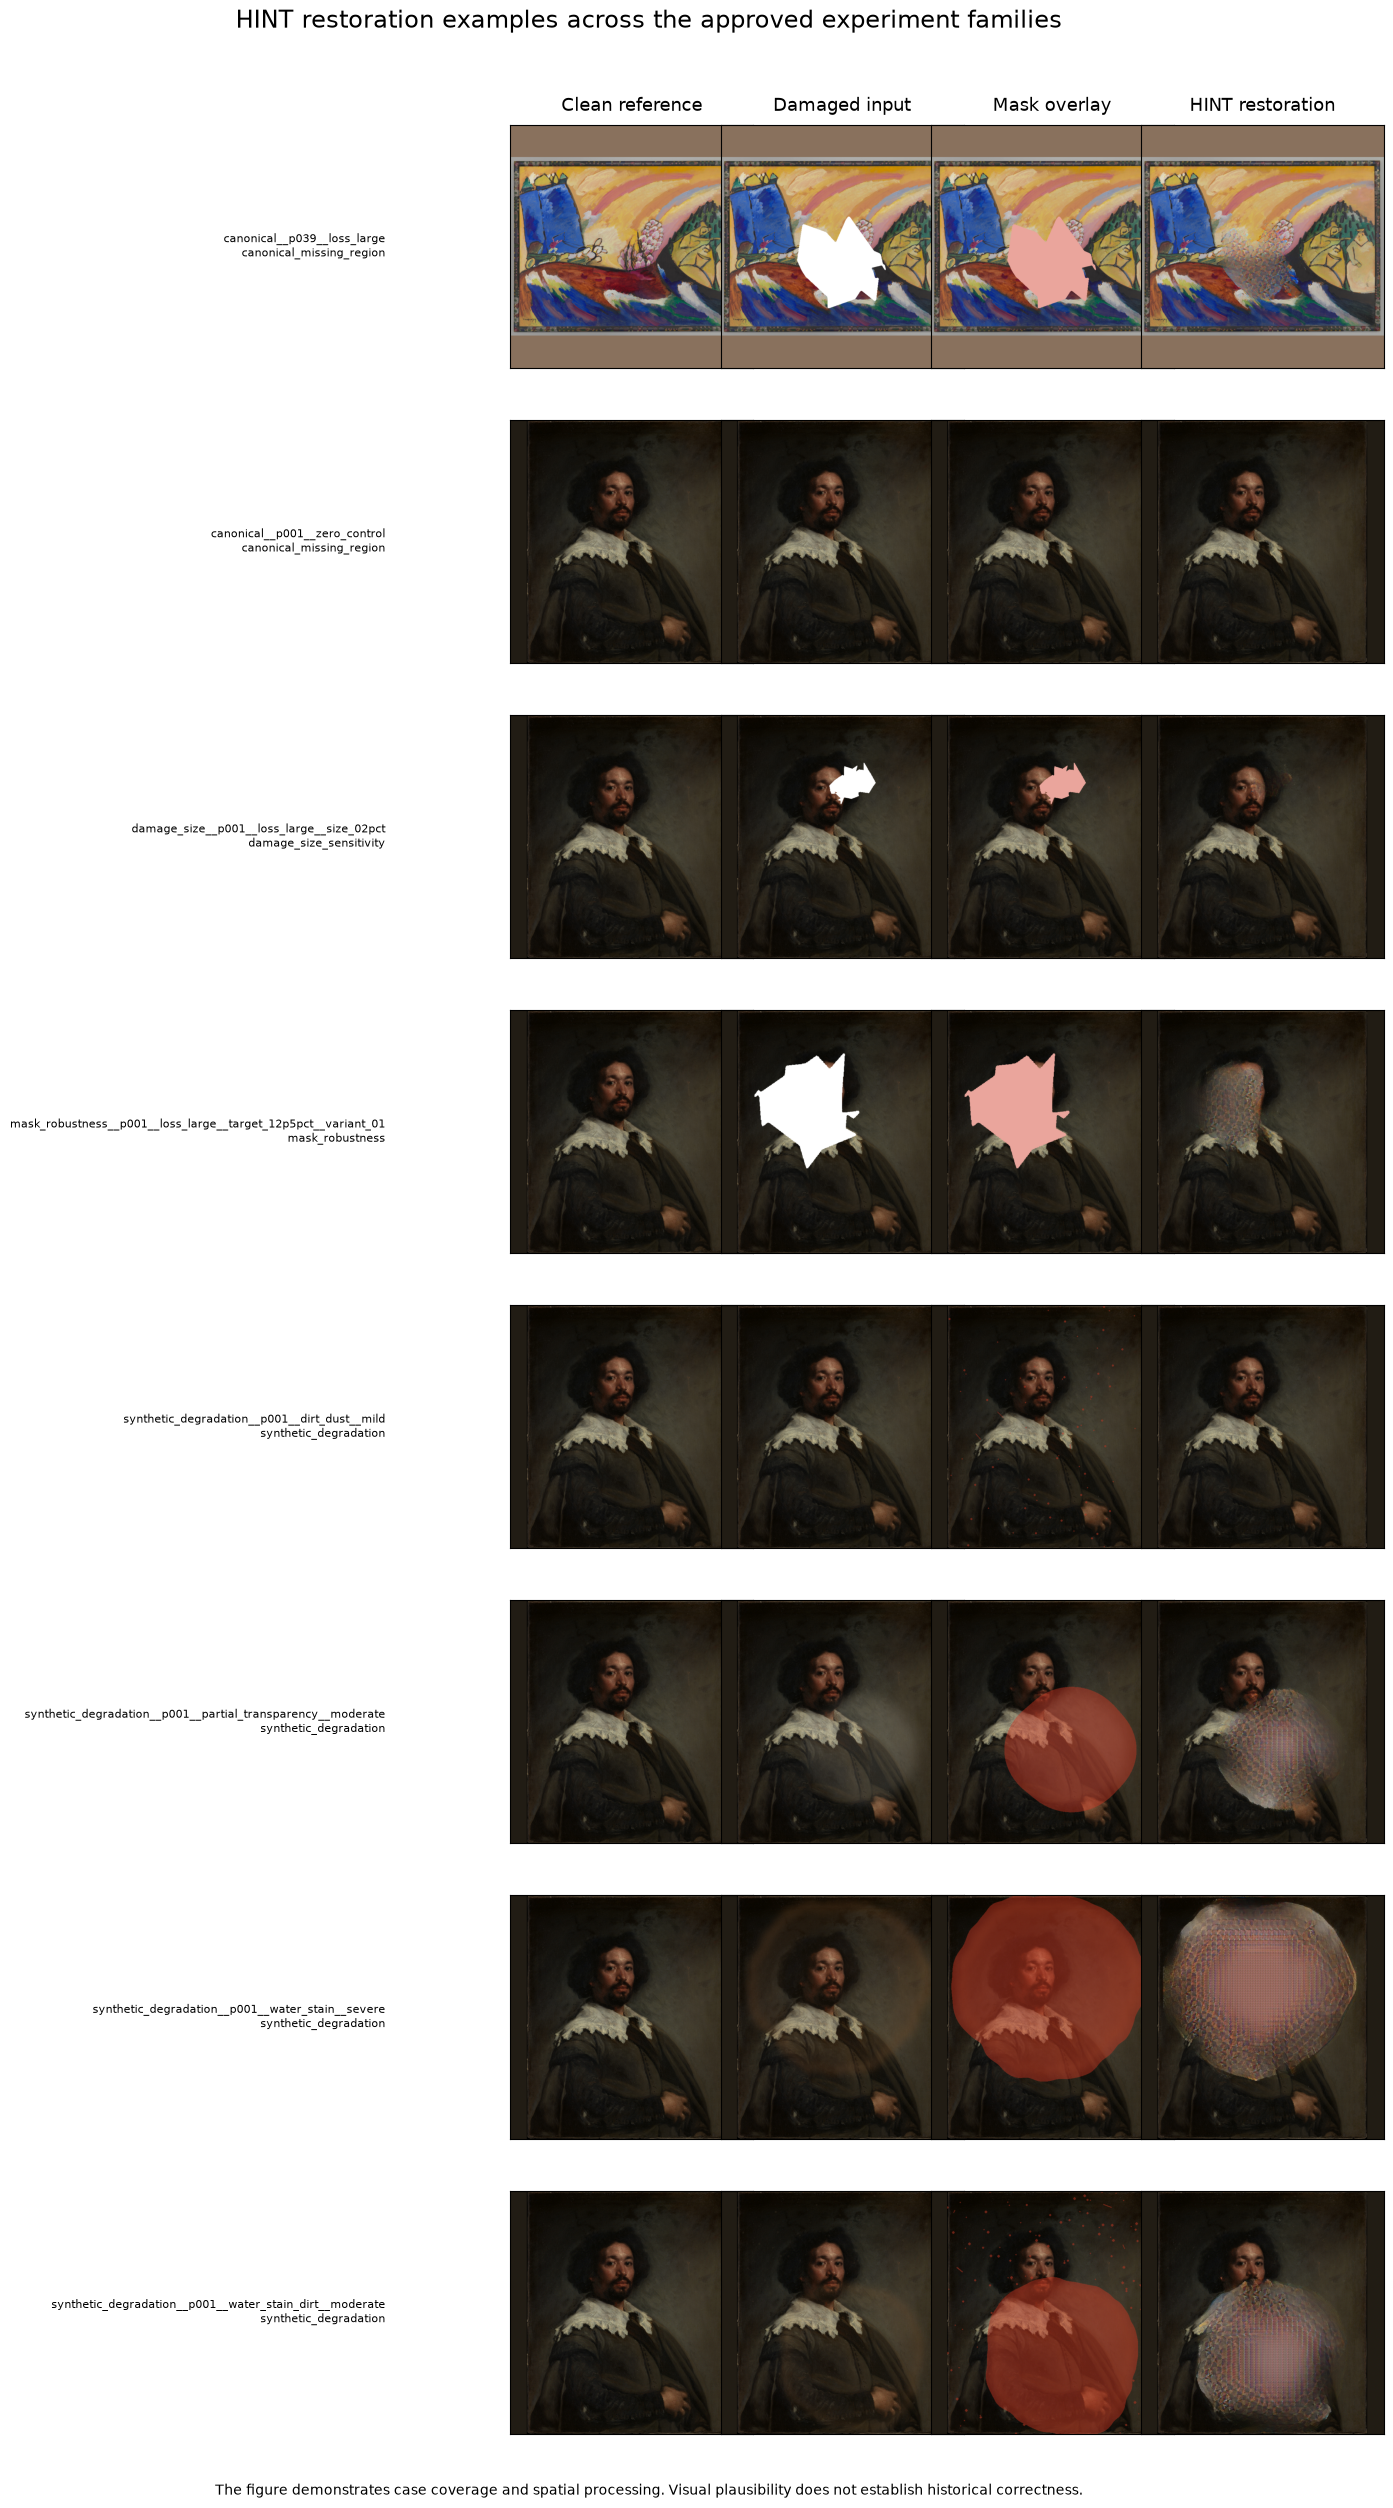

Representative cases: 8
Representative figure: {'format': 'PNG', 'mode': 'RGBA', 'width': 2497, 'height': 4515, 'size_bytes': 7470769, 'sha256': '0d5e2b5953c7053978c6c3054d7c695654caae15fb838810180da883382a0003'}


In [22]:
# ---------------------------------------------------------------------------
# Render the eight-case representative figure
# ---------------------------------------------------------------------------

REPRESENTATIVE_CASE_IDS = list(
    hint_config[
        "representative_case_ids"
    ]
)

representative_order = {
    case_id: index
    for index, case_id in enumerate(
        REPRESENTATIVE_CASE_IDS
    )
}

REPRESENTATIVE_CASES = (
    HINT_PLAN.loc[
        HINT_PLAN[
            "case_id"
        ].isin(
            REPRESENTATIVE_CASE_IDS
        )
    ]
    .assign(
        representative_order=lambda frame: (
            frame["case_id"].map(
                representative_order
            )
        )
    )
    .sort_values(
        "representative_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

if (
    REPRESENTATIVE_CASES[
        "case_id"
    ].tolist()
    != REPRESENTATIVE_CASE_IDS
):
    raise ValueError(
        "Representative HINT cases do not "
        "match the approved ordered selection."
    )


def mask_overlay(input_array, mask_array, threshold):
    active = mask_array >= int(threshold)

    overlay = input_array.astype(
        np.float32
    ).copy()

    overlay[active] = (
        0.55 * overlay[active]
        + 0.45
        * np.array(
            [210, 55, 35],
            dtype=np.float32,
        )
    )

    return np.clip(
        overlay,
        0,
        255,
    ).astype(np.uint8)


figure, axes = plt.subplots(
    len(REPRESENTATIVE_CASES),
    4,
    figsize=(15, 25),
)

column_titles = (
    "Clean reference",
    "Damaged input",
    "Mask overlay",
    "HINT restoration",
)

for column_index, title in enumerate(
    column_titles
):
    axes[0, column_index].set_title(
        title,
        fontsize=13,
        pad=10,
    )

for row_index, row in enumerate(
    REPRESENTATIVE_CASES.itertuples(
        index=False
    )
):
    clean_path = resolve_project_file(
        row.clean_image_path
    )
    input_path = resolve_project_file(
        row.input_image_path
    )
    mask_path = resolve_project_file(
        row.mask_path
    )
    restored_path = resolve_project_file(
        row.restored_path
    )

    with Image.open(
        clean_path
    ) as image:
        clean_array = np.asarray(
            image.convert("RGB"),
            dtype=np.uint8,
        )

    with Image.open(
        input_path
    ) as image:
        input_array = np.asarray(
            image.convert("RGB"),
            dtype=np.uint8,
        )

    with Image.open(
        mask_path
    ) as image:
        mask_array = np.asarray(
            image.convert("L"),
            dtype=np.uint8,
        )

    with Image.open(
        restored_path
    ) as image:
        restored_array = np.asarray(
            image.convert("RGB"),
            dtype=np.uint8,
        )

    images = (
        clean_array,
        input_array,
        mask_overlay(
            input_array,
            mask_array,
            row.mask_threshold,
        ),
        restored_array,
    )

    for column_index, image_array in enumerate(
        images
    ):
        axes[
            row_index,
            column_index,
        ].imshow(image_array)

        axes[
            row_index,
            column_index,
        ].set_xticks([])

        axes[
            row_index,
            column_index,
        ].set_yticks([])

    axes[
        row_index,
        0,
    ].set_ylabel(
        (
            f"{row.case_id}\n"
            f"{row.experiment_id}"
        ),
        fontsize=8,
        rotation=0,
        ha="right",
        va="center",
        labelpad=90,
    )

figure.suptitle(
    (
        "HINT restoration examples across "
        "the approved experiment families"
    ),
    fontsize=17,
    y=0.998,
)

figure.text(
    0.5,
    0.004,
    (
        "The figure demonstrates case coverage "
        "and spatial processing. Visual plausibility "
        "does not establish historical correctness."
    ),
    ha="center",
    fontsize=10,
)

figure.tight_layout(
    rect=(0.08, 0.015, 1, 0.992)
)

OUTPUTS[
    "restoration_examples"
].parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    OUTPUTS[
        "restoration_examples"
    ],
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(figure)

with Image.open(
    OUTPUTS[
        "restoration_examples"
    ]
) as representative_figure:
    REPRESENTATIVE_FIGURE_AUDIT = {
        "format": (
            representative_figure.format
        ),
        "mode": (
            representative_figure.mode
        ),
        "width": (
            representative_figure.width
        ),
        "height": (
            representative_figure.height
        ),
        "size_bytes": (
            OUTPUTS[
                "restoration_examples"
            ].stat().st_size
        ),
        "sha256": sha256_file(
            OUTPUTS[
                "restoration_examples"
            ]
        ),
    }

print(
    "Representative cases:",
    len(REPRESENTATIVE_CASES),
)
print(
    "Representative figure:",
    REPRESENTATIVE_FIGURE_AUDIT,
)

In [23]:
# ---------------------------------------------------------------------------
# Rerunnable Batch 6 validation
# ---------------------------------------------------------------------------

BATCH_6_STAGE = (
    "batch_6_scientific_and_technical_validation"
)

expected_total = int(
    EXPECTED_COUNTS["restorations_row_count"]
)
expected_zero = int(
    EXPECTED_COUNTS["zero_control_case_count"]
)
expected_nonzero = int(
    EXPECTED_COUNTS["model_inference_case_count"]
)

zero_audit = SCIENTIFIC_AUDIT.loc[
    SCIENTIFIC_AUDIT[
        "execution_action"
    ].eq("identity_noop")
]

nonzero_audit = SCIENTIFIC_AUDIT.loc[
    SCIENTIFIC_AUDIT[
        "execution_action"
    ].eq("hint_inpaint")
]

expected_restored_files = {
    (
        PROJECT_ROOT / path
    ).resolve()
    for path in CANONICAL_RESTORATIONS[
        "restored_path"
    ].astype(str)
}

observed_restored_files = {
    path.resolve()
    for path in OUTPUTS[
        "restored_images"
    ].rglob("*.png")
    if path.is_file()
}

batch_6_checks = [
    {
        "check_id": "scientific_audit_population",
        "description": (
            "Every candidate has one independent "
            "persisted-image audit."
        ),
        "expected": expected_total,
        "observed": {
            "rows": len(
                SCIENTIFIC_AUDIT
            ),
            "unique_candidates": int(
                SCIENTIFIC_AUDIT[
                    "candidate_id"
                ].nunique()
            ),
        },
        "passed": bool(
            len(SCIENTIFIC_AUDIT)
            == expected_total
            and SCIENTIFIC_AUDIT[
                "candidate_id"
            ].is_unique
        ),
    },
    {
        "check_id": "image_geometry",
        "description": (
            "Every output reloads as a "
            "768x768 RGB PNG."
        ),
        "expected": expected_total,
        "observed": int(
            (
                SCIENTIFIC_AUDIT[
                    "readable"
                ]
                & SCIENTIFIC_AUDIT[
                    "format"
                ].eq("PNG")
                & SCIENTIFIC_AUDIT[
                    "mode"
                ].eq("RGB")
                & SCIENTIFIC_AUDIT[
                    "width"
                ].eq(768)
                & SCIENTIFIC_AUDIT[
                    "height"
                ].eq(768)
            ).sum()
        ),
        "passed": bool(
            SCIENTIFIC_AUDIT[
                "readable"
            ].all()
            and SCIENTIFIC_AUDIT[
                "format"
            ].eq("PNG").all()
            and SCIENTIFIC_AUDIT[
                "mode"
            ].eq("RGB").all()
            and SCIENTIFIC_AUDIT[
                "width"
            ].eq(768).all()
            and SCIENTIFIC_AUDIT[
                "height"
            ].eq(768).all()
        ),
    },
    {
        "check_id": "restoration_checksums",
        "description": (
            "Every persisted image matches its "
            "recorded SHA-256 digest."
        ),
        "expected": expected_total,
        "observed": int(
            SCIENTIFIC_AUDIT[
                "checksum_matches"
            ].sum()
        ),
        "passed": bool(
            SCIENTIFIC_AUDIT[
                "checksum_matches"
            ].all()
        ),
    },
    {
        "check_id": "outside_mask_invariance",
        "description": (
            "No HINT result changes pixels "
            "outside its approved mask."
        ),
        "expected": 0,
        "observed": int(
            SCIENTIFIC_AUDIT[
                "changed_outside_mask_pixels"
            ].sum()
        ),
        "passed": bool(
            SCIENTIFIC_AUDIT[
                "changed_outside_mask_pixels"
            ].eq(0).all()
        ),
    },
    {
        "check_id": "zero_control_identity",
        "description": (
            "All 300 zero controls preserve "
            "their inputs exactly."
        ),
        "expected": {
            "rows": expected_zero,
            "valid": expected_zero,
        },
        "observed": {
            "rows": len(zero_audit),
            "valid": int(
                zero_audit[
                    "zero_control_valid"
                ].sum()
            ),
        },
        "passed": bool(
            len(zero_audit) == expected_zero
            and zero_audit[
                "zero_control_valid"
            ].all()
        ),
    },
    {
        "check_id": "nonzero_inside_change",
        "description": (
            "Every nonzero HINT case changes "
            "at least one permitted pixel."
        ),
        "expected": {
            "rows": expected_nonzero,
            "valid": expected_nonzero,
        },
        "observed": {
            "rows": len(nonzero_audit),
            "valid": int(
                nonzero_audit[
                    "inside_change_valid"
                ].sum()
            ),
        },
        "passed": bool(
            len(nonzero_audit)
            == expected_nonzero
            and nonzero_audit[
                "inside_change_valid"
            ].all()
        ),
    },
    {
        "check_id": "worker_validation_agreement",
        "description": (
            "Every independent result also passed "
            "the worker's technical gate."
        ),
        "expected": expected_total,
        "observed": int(
            SCIENTIFIC_AUDIT[
                "worker_validation_passed"
            ].sum()
        ),
        "passed": bool(
            SCIENTIFIC_AUDIT[
                "worker_validation_passed"
            ].all()
        ),
    },
    {
        "check_id": "exact_image_filesystem",
        "description": (
            "The restored-image tree contains "
            "exactly the approved files."
        ),
        "expected": {
            "files": expected_total,
            "missing": 0,
            "unexpected": 0,
        },
        "observed": {
            "files": len(
                observed_restored_files
            ),
            "missing": len(
                expected_restored_files
                - observed_restored_files
            ),
            "unexpected": len(
                observed_restored_files
                - expected_restored_files
            ),
        },
        "passed": bool(
            expected_restored_files
            == observed_restored_files
        ),
    },
    {
        "check_id": "representative_selection",
        "description": (
            "The figure uses exactly the eight "
            "predeclared representative cases."
        ),
        "expected": (
            REPRESENTATIVE_CASE_IDS
        ),
        "observed": (
            REPRESENTATIVE_CASES[
                "case_id"
            ].tolist()
        ),
        "passed": bool(
            REPRESENTATIVE_CASES[
                "case_id"
            ].tolist()
            == REPRESENTATIVE_CASE_IDS
        ),
    },
    {
        "check_id": "representative_figure",
        "description": (
            "The representative figure is a "
            "non-empty readable PNG."
        ),
        "expected": {
            "format": "PNG",
            "positive_size": True,
        },
        "observed": (
            REPRESENTATIVE_FIGURE_AUDIT
        ),
        "passed": bool(
            REPRESENTATIVE_FIGURE_AUDIT[
                "format"
            ] == "PNG"
            and REPRESENTATIVE_FIGURE_AUDIT[
                "size_bytes"
            ] > 0
        ),
    },
    {
        "check_id": "complete_scientific_gate",
        "description": (
            "Every independent scientific audit "
            "row passes."
        ),
        "expected": expected_total,
        "observed": int(
            SCIENTIFIC_AUDIT[
                "validation_passed"
            ].sum()
        ),
        "passed": bool(
            SCIENTIFIC_AUDIT[
                "validation_passed"
            ].all()
        ),
    },
]

VALIDATION = replace_validation_stage(
    VALIDATION,
    BATCH_6_STAGE,
    batch_6_checks,
)

BATCH_6_CHECKS = validation_stage_frame(
    VALIDATION,
    BATCH_6_STAGE,
)

print("Batch 6 validation checks:")
display(
    BATCH_6_CHECKS[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nScientific audit summary:")
display(
    SCIENTIFIC_AUDIT.groupby(
        [
            "experiment_id",
            "execution_action",
        ],
        sort=True,
    )
    .agg(
        cases=("case_id", "size"),
        passed=(
            "validation_passed",
            "sum",
        ),
        inside_changed_pixels=(
            "changed_inside_mask_pixels",
            "sum",
        ),
        outside_changed_pixels=(
            "changed_outside_mask_pixels",
            "sum",
        ),
    )
    .reset_index()
)

failed_scientific_rows = (
    SCIENTIFIC_AUDIT.loc[
        ~SCIENTIFIC_AUDIT[
            "validation_passed"
        ]
    ]
)

if not failed_scientific_rows.empty:
    print("\nFailed scientific rows:")
    display(failed_scientific_rows.head(25))

print("\nBatch 6 completed.")
print("Checks:", len(BATCH_6_CHECKS))
print(
    "Passed:",
    int(
        BATCH_6_CHECKS[
            "passed"
        ].sum()
    ),
)
print(
    "Scientific audit rows:",
    len(SCIENTIFIC_AUDIT),
)
print(
    "Scientific audit seconds:",
    SCIENTIFIC_AUDIT_SECONDS,
)
print(
    "Next: Batch 7 - canonical persistence "
    "and independent reload validation."
)

VALIDATION.raise_for_blocking()

Batch 6 validation checks:


,check_id,expected,observed,passed
0,scientific_audit_population,2620,"{""rows"": 2620, ""unique_candidates"": 2620}",True
1,image_geometry,2620,2620,True
2,restoration_checksums,2620,2620,True
3,outside_mask_invariance,0,0,True
4,zero_control_identity,"{""rows"": 300, ""valid"": 300}","{""rows"": 300, ""valid"": 300}",True
5,nonzero_inside_change,"{""rows"": 2320, ""valid"": 2320}","{""rows"": 2320, ""valid"": 2320}",True
6,worker_validation_agreement,2620,2620,True
7,exact_image_filesystem,"{""files"": 2620, ""missing"": 0, ""unexpected"": 0}","{""files"": 2620, ""missing"": 0, ""unexpected"": 0}",True
8,representative_selection,"[""canonical__p039__loss_large"", ""canonical__p0...","[""canonical__p039__loss_large"", ""canonical__p0...",True
9,representative_figure,"{""format"": ""PNG"", ""positive_size"": true}","{""format"": ""PNG"", ""height"": 4515, ""mode"": ""RGB...",True



Scientific audit summary:


,experiment_id,execution_action,cases,passed,inside_changed_pixels,outside_changed_pixels
0,canonical_missing_region,hint_inpaint,1200,1200,37990798,0
1,canonical_missing_region,identity_noop,300,300,0,0
2,damage_size_sensitivity,hint_inpaint,245,245,10108284,0
3,mask_robustness,hint_inpaint,525,525,14773663,0
4,synthetic_degradation,hint_inpaint,350,350,37518691,0



Batch 6 completed.
Checks: 11
Passed: 11
Scientific audit rows: 2620
Scientific audit seconds: 425.488
Next: Batch 7 - canonical persistence and independent reload validation.


## Batch 7 — Canonical persistence and reload validation

This batch atomically writes and independently reloads:

- `data/restorations.csv`;
- `metrics/runtime_summary.csv`;
- the consolidated validation table.

The representative figure was already written by Batch 6. Final manifests, project-path registration, temporary-work cleanup, and roadmap traceability remain in Batch 8.

In [24]:
from restoration_eval.restoration_hint import (
    atomic_write_csv,
)


# ---------------------------------------------------------------------------
# Atomically persist normalized canonical tables
# ---------------------------------------------------------------------------

atomic_write_csv(
    CANONICAL_RESTORATIONS,
    OUTPUTS["restorations"],
)

atomic_write_csv(
    RUNTIME_SUMMARY,
    OUTPUTS["runtime_summary"],
)


# ---------------------------------------------------------------------------
# Independently reload canonical tables
# ---------------------------------------------------------------------------

RELOADED_RESTORATIONS = pd.read_csv(
    OUTPUTS["restorations"],
    keep_default_na=False,
)

RELOADED_RUNTIME_SUMMARY = pd.read_csv(
    OUTPUTS["runtime_summary"],
    keep_default_na=False,
)

RELOADED_RESTORATIONS_SCHEMA = (
    validate_dataframe(
        RELOADED_RESTORATIONS,
        RESTORATIONS_SCHEMA,
        allow_extra_columns=False,
    )
)

RELOADED_RUNTIME_SCHEMA = (
    validate_dataframe(
        RELOADED_RUNTIME_SUMMARY,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)


def frames_match_without_dtype(
    expected,
    observed,
):
    try:
        pd.testing.assert_frame_equal(
            expected.reset_index(drop=True),
            observed.reset_index(drop=True),
            check_dtype=False,
            check_like=False,
        )
    except AssertionError:
        return False

    return True


restorations_reload_matches = (
    frames_match_without_dtype(
        CANONICAL_RESTORATIONS,
        RELOADED_RESTORATIONS,
    )
)

runtime_reload_matches = (
    frames_match_without_dtype(
        RUNTIME_SUMMARY,
        RELOADED_RUNTIME_SUMMARY,
    )
)

print(
    "Reloaded restoration rows:",
    len(RELOADED_RESTORATIONS),
)
print(
    "Reloaded runtime rows:",
    len(RELOADED_RUNTIME_SUMMARY),
)
print(
    "Restoration reload matches:",
    restorations_reload_matches,
)
print(
    "Runtime reload matches:",
    runtime_reload_matches,
)

Reloaded restoration rows: 2620
Reloaded runtime rows: 5
Restoration reload matches: True
Runtime reload matches: True


In [25]:
# ---------------------------------------------------------------------------
# Rerunnable Batch 7 persistence validation
# ---------------------------------------------------------------------------

BATCH_7_STAGE = (
    "batch_7_persistence_and_reload"
)

canonical_table_files = {
    "restorations": (
        OUTPUTS["restorations"]
    ),
    "runtime_summary": (
        OUTPUTS["runtime_summary"]
    ),
    "restoration_examples": (
        OUTPUTS["restoration_examples"]
    ),
}

batch_7_checks = [
    {
        "check_id": "canonical_files_exist",
        "description": (
            "Both tables and the representative "
            "figure exist and are non-empty."
        ),
        "expected": {
            key: True
            for key in canonical_table_files
        },
        "observed": {
            key: bool(
                path.is_file()
                and path.stat().st_size > 0
            )
            for key, path in (
                canonical_table_files.items()
            )
        },
        "passed": all(
            path.is_file()
            and path.stat().st_size > 0
            for path in (
                canonical_table_files.values()
            )
        ),
    },
    {
        "check_id": (
            "reloaded_restoration_schema"
        ),
        "description": (
            "The persisted restoration table "
            "satisfies restorations.v1."
        ),
        "expected": True,
        "observed": (
            RELOADED_RESTORATIONS_SCHEMA
            .to_dict()
        ),
        "passed": (
            RELOADED_RESTORATIONS_SCHEMA
            .passed
        ),
    },
    {
        "check_id": "reloaded_runtime_schema",
        "description": (
            "The persisted runtime table satisfies "
            "its normalized schema."
        ),
        "expected": True,
        "observed": (
            RELOADED_RUNTIME_SCHEMA.to_dict()
        ),
        "passed": (
            RELOADED_RUNTIME_SCHEMA.passed
        ),
    },
    {
        "check_id": (
            "restoration_round_trip"
        ),
        "description": (
            "The restoration table survives "
            "the CSV round trip unchanged."
        ),
        "expected": True,
        "observed": (
            restorations_reload_matches
        ),
        "passed": (
            restorations_reload_matches
        ),
    },
    {
        "check_id": "runtime_round_trip",
        "description": (
            "The runtime summary survives "
            "the CSV round trip unchanged."
        ),
        "expected": True,
        "observed": (
            runtime_reload_matches
        ),
        "passed": (
            runtime_reload_matches
        ),
    },
    {
        "check_id": (
            "persisted_population_reconciliation"
        ),
        "description": (
            "Reloaded tables retain their exact "
            "approved row populations."
        ),
        "expected": {
            "restorations": int(
                EXPECTED_COUNTS[
                    "restorations_row_count"
                ]
            ),
            "runtime_rows": int(
                EXPECTED_COUNTS[
                    "runtime_summary_row_count"
                ]
            ),
        },
        "observed": {
            "restorations": len(
                RELOADED_RESTORATIONS
            ),
            "runtime_rows": len(
                RELOADED_RUNTIME_SUMMARY
            ),
        },
        "passed": bool(
            len(RELOADED_RESTORATIONS)
            == int(
                EXPECTED_COUNTS[
                    "restorations_row_count"
                ]
            )
            and len(
                RELOADED_RUNTIME_SUMMARY
            )
            == int(
                EXPECTED_COUNTS[
                    "runtime_summary_row_count"
                ]
            )
        ),
    },
]

VALIDATION = replace_validation_stage(
    VALIDATION,
    BATCH_7_STAGE,
    batch_7_checks,
)

BATCH_7_CHECKS = validation_stage_frame(
    VALIDATION,
    BATCH_7_STAGE,
)

VALIDATION.raise_for_blocking()

# Provisional write; Batch 8 replaces it with
# the final consolidated validation table.
VALIDATION.write_csv(
    OUTPUTS["validation_checks"]
)

RELOADED_VALIDATION = pd.read_csv(
    OUTPUTS["validation_checks"],
    keep_default_na=False,
)

RELOADED_VALIDATION_SCHEMA = (
    validate_dataframe(
        RELOADED_VALIDATION,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not RELOADED_VALIDATION_SCHEMA.passed:
    raise ValueError(
        "The provisional consolidated validation "
        "table failed reload validation."
    )

print("Batch 7 validation checks:")
display(
    BATCH_7_CHECKS[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nPersisted canonical tables:")
display(
    pd.DataFrame(
        [
            {
                "artifact": key,
                "path": to_repo_relative(
                    path,
                    PROJECT_ROOT,
                ),
                "size_bytes": (
                    path.stat().st_size
                ),
                "sha256": sha256_file(
                    path
                ),
            }
            for key, path in (
                canonical_table_files.items()
            )
        ]
    )
)

print("\nBatch 7 completed.")
print("Checks:", len(BATCH_7_CHECKS))
print(
    "Passed:",
    int(
        BATCH_7_CHECKS[
            "passed"
        ].sum()
    ),
)
print(
    "Consolidated checks so far:",
    len(RELOADED_VALIDATION),
)
print(
    "Next: Batch 8 - final manifests, "
    "cleanup, registry, and traceability."
)

Batch 7 validation checks:


,check_id,expected,observed,passed
0,canonical_files_exist,"{""restoration_examples"": true, ""restorations"":...","{""restoration_examples"": true, ""restorations"":...",True
1,reloaded_restoration_schema,True,"{""column_count"": 30, ""duplicate_primary_key_ro...",True
2,reloaded_runtime_schema,True,"{""column_count"": 12, ""duplicate_primary_key_ro...",True
3,restoration_round_trip,True,True,True
4,runtime_round_trip,True,True,True
5,persisted_population_reconciliation,"{""restorations"": 2620, ""runtime_rows"": 5}","{""restorations"": 2620, ""runtime_rows"": 5}",True



Persisted canonical tables:


,artifact,path,size_bytes,sha256
0,restorations,outputs/12a_hint_restoration/data/restorations...,1974624,e4b5a22f7bc4ccb9bd24c9ec121954362556d542b9b366...
1,runtime_summary,outputs/12a_hint_restoration/metrics/runtime_s...,692,0d936354f68a44295f37c37649ec9539995ccc9fcc2088...
2,restoration_examples,outputs/12a_hint_restoration/figures/restorati...,7470769,0d5e2b5953c7053978c6c3054d7c695654caae15fb8388...



Batch 7 completed.
Checks: 6
Passed: 6
Consolidated checks so far: 77
Next: Batch 8 - final manifests, cleanup, registry, and traceability.


## Batch 8 — Final manifests and completion gate

This final batch:

- records the notebook responsibility-completion table;
- removes only temporary files below the Notebook 12A `work/` directory;
- writes the final consolidated validation table;
- constructs the five-record artifact manifest;
- writes the completed run manifest;
- registers the validated artifacts in the project-path registry;
- verifies the exact final output set and artifact checksums.

This batch is safe to rerun after successful completion.

In [26]:
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.paths import (
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Preserve execution evidence before cleaning temporary work
# ---------------------------------------------------------------------------

EXECUTION_EVIDENCE = {
    "worker_status": (
        FULL_RESULT.get("status")
    ),
    "worker_runtime_seconds": (
        FULL_RESULT.get("runtime_seconds")
    ),
    "parent_runtime_seconds": (
        FULL_PROCESS_RUNTIME_SECONDS
    ),
    "worker_return_code": (
        FULL_PROCESS_RETURN_CODE
    ),
    "worker_launched": (
        FULL_EXECUTION_NEEDED
    ),
    "execution_skipped_as_complete": (
        FULL_EXECUTION_SKIPPED
    ),
    "timed_out": (
        FULL_PROCESS_TIMED_OUT
    ),
    "timeout_reason": (
        FULL_PROCESS_TIMEOUT_REASON
    ),
    "resolved_rows": len(FULL_ROWS),
    "completed_rows": int(
        FULL_ROWS[
            "status"
        ].eq("completed").sum()
    ),
    "failed_rows": int(
        FULL_ROWS[
            "status"
        ].eq("failed").sum()
    ),
    "model_load_seconds": (
        FULL_RESULT.get(
            "model_load_seconds"
        )
    ),
    "checkpoint_revision": (
        hint_asset[
            "checkpoint_sha256"
        ]
    ),
    "repository_revision": (
        hint_asset[
            "actual_repository_revision"
        ]
    ),
}


# ---------------------------------------------------------------------------
# Roadmap responsibility traceability
# ---------------------------------------------------------------------------

ROADMAP_TRACEABILITY = pd.DataFrame(
    [
        {
            "requirement_id": "hint_selection",
            "responsibility": (
                "Use the HINT method selected by D01."
            ),
            "status": "complete",
            "evidence": (
                "D01 decision and pinned HINT "
                "revision validated in Batch 1."
            ),
        },
        {
            "requirement_id": "eligible_population",
            "responsibility": (
                "Consume every Notebook 08 case "
                "marked HINT-eligible."
            ),
            "status": "complete",
            "evidence": (
                "2,620 exact eligible cases "
                "validated in Batches 1-4."
            ),
        },
        {
            "requirement_id": "candidate_identity",
            "responsibility": (
                "Produce one deterministic primary "
                "candidate per eligible case."
            ),
            "status": "complete",
            "evidence": (
                "2,620 unique candidate, restoration, "
                "and case identities."
            ),
        },
        {
            "requirement_id": "guarded_execution",
            "responsibility": (
                "Use progress, checkpointing, resume, "
                "stall protection, and an upper budget."
            ),
            "status": "complete",
            "evidence": (
                "Guarded worker completed with "
                "ten-case progress and checkpoints."
            ),
        },
        {
            "requirement_id": "fixed_adapter",
            "responsibility": (
                "Preserve native 768x768 processing, "
                "mask policy, and exact compositing."
            ),
            "status": "complete",
            "evidence": (
                "Fixed configuration and all image "
                "audits passed."
            ),
        },
        {
            "requirement_id": "zero_controls",
            "responsibility": (
                "Preserve all 300 zero controls "
                "as exact identity outputs."
            ),
            "status": "complete",
            "evidence": (
                "Independent pixel comparison passed "
                "for all zero controls."
            ),
        },
        {
            "requirement_id": "outside_invariance",
            "responsibility": (
                "Change no pixel outside each "
                "approved mask."
            ),
            "status": "complete",
            "evidence": (
                "Zero outside-mask changed pixels "
                "across all 2,620 cases."
            ),
        },
        {
            "requirement_id": "normalized_handoff",
            "responsibility": (
                "Preserve normalized restoration and "
                "runtime schemas for downstream use."
            ),
            "status": "complete",
            "evidence": (
                "Canonical tables passed schema and "
                "independent reload validation."
            ),
        },
        {
            "requirement_id": "representative_figure",
            "responsibility": (
                "Render the predeclared eight-case "
                "restoration figure."
            ),
            "status": "complete",
            "evidence": (
                "Readable canonical PNG generated "
                "from all four experiment families."
            ),
        },
        {
            "requirement_id": "interpretation_boundary",
            "responsibility": (
                "Retain the method's scientific "
                "interpretation limits."
            ),
            "status": "complete",
            "evidence": (
                "Known limitations retained in the "
                "notebook and final run manifest."
            ),
        },
    ]
)

ROADMAP_TRACEABILITY_PASSED = bool(
    ROADMAP_TRACEABILITY[
        "status"
    ].eq("complete").all()
)


# ---------------------------------------------------------------------------
# Remove only Notebook 12A temporary work files
# ---------------------------------------------------------------------------

WORK_ROOT = (
    OUTPUT_ROOT / "work"
).resolve()

WORK_ROOT.relative_to(
    OUTPUT_ROOT.resolve()
)

work_files_before_cleanup = sorted(
    path.resolve()
    for path in WORK_ROOT.rglob("*")
    if path.is_file()
)

for work_file in work_files_before_cleanup:
    work_file.relative_to(WORK_ROOT)
    work_file.unlink()

work_directories = sorted(
    [
        path.resolve()
        for path in WORK_ROOT.rglob("*")
        if path.is_dir()
    ],
    key=lambda path: len(path.parts),
    reverse=True,
)

for work_directory in work_directories:
    work_directory.relative_to(WORK_ROOT)

    if (
        work_directory != WORK_ROOT
        and not any(
            work_directory.iterdir()
        )
    ):
        work_directory.rmdir()

WORK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

work_files_after_cleanup = sorted(
    path.resolve()
    for path in WORK_ROOT.rglob("*")
    if path.is_file()
)

print(
    "Temporary work files before cleanup:",
    len(work_files_before_cleanup),
)
print(
    "Temporary work files after cleanup:",
    len(work_files_after_cleanup),
)
print(
    "Roadmap requirements complete:",
    ROADMAP_TRACEABILITY_PASSED,
)

Temporary work files before cleanup: 13
Temporary work files after cleanup: 0
Roadmap requirements complete: True


In [28]:
# ---------------------------------------------------------------------------
# Final Batch 8 validation before manifest construction
# ---------------------------------------------------------------------------

BATCH_8_STAGE = (
    "batch_8_finalization_and_traceability"
)

expected_core_paths = (
    expected_restored_files
    | {
        OUTPUTS[
            "restorations"
        ].resolve(),
        OUTPUTS[
            "runtime_summary"
        ].resolve(),
        OUTPUTS[
            "restoration_examples"
        ].resolve(),
        OUTPUTS[
            "validation_checks"
        ].resolve(),
    }
)

expected_final_paths = (
    expected_core_paths
    | {
        OUTPUTS[
            "artifact_manifest"
        ].resolve(),
        OUTPUTS[
            "run_manifest"
        ].resolve(),
    }
)

observed_before_final = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and WORK_ROOT
        not in path.resolve().parents
    )
}

unexpected_before_final = (
    observed_before_final
    - expected_final_paths
)

missing_core_before_final = (
    expected_core_paths
    - observed_before_final
)

batch_8_checks = [
    {
        "check_id": "prior_validation_layers",
        "description": (
            "Every earlier blocking validation "
            "layer passes before finalization."
        ),
        "expected": True,
        "observed": (
            VALIDATION.summary()
        ),
        "passed": (
            VALIDATION.overall_passed
        ),
    },
    {
        "check_id": "roadmap_traceability",
        "description": (
            "Every approved Notebook 12A "
            "responsibility is complete."
        ),
        "expected": {
            "requirements": len(
                ROADMAP_TRACEABILITY
            ),
            "incomplete": 0,
        },
        "observed": {
            "requirements": len(
                ROADMAP_TRACEABILITY
            ),
            "incomplete": int(
                ROADMAP_TRACEABILITY[
                    "status"
                ].ne("complete").sum()
            ),
        },
        "passed": (
            ROADMAP_TRACEABILITY_PASSED
        ),
    },
    {
        "check_id": "temporary_work_cleanup",
        "description": (
            "No temporary work file remains "
            "after successful canonical persistence."
        ),
        "expected": 0,
        "observed": len(
            work_files_after_cleanup
        ),
        "passed": (
            not work_files_after_cleanup
        ),
    },
    {
        "check_id": "pre_final_output_set",
        "description": (
            "All canonical core artifacts exist "
            "and no undeclared output is present."
        ),
        "expected": {
            "missing_core": 0,
            "unexpected": 0,
        },
        "observed": {
            "missing_core": len(
                missing_core_before_final
            ),
            "unexpected": len(
                unexpected_before_final
            ),
        },
        "passed": bool(
            not missing_core_before_final
            and not unexpected_before_final
        ),
        "details": {
            "missing_core": [
                to_repo_relative(
                    path,
                    PROJECT_ROOT,
                )
                for path in sorted(
                    missing_core_before_final
                )
            ],
            "unexpected": [
                to_repo_relative(
                    path,
                    PROJECT_ROOT,
                )
                for path in sorted(
                    unexpected_before_final
                )
            ],
        },
    },
    {
        "check_id": "final_population",
        "description": (
            "The final handoff retains 2,620 "
            "completed restoration records."
        ),
        "expected": {
            "rows": 2620,
            "completed": 2620,
            "failed": 0,
        },
        "observed": {
            "rows": len(
                RELOADED_RESTORATIONS
            ),
            "completed": int(
                RELOADED_RESTORATIONS[
                    "status"
                ].eq("completed").sum()
            ),
            "failed": int(
                RELOADED_RESTORATIONS[
                    "status"
                ].eq("failed").sum()
            ),
        },
        "passed": bool(
            len(
                RELOADED_RESTORATIONS
            ) == 2620
            and RELOADED_RESTORATIONS[
                "status"
            ].eq("completed").all()
        ),
    },
]

VALIDATION = replace_validation_stage(
    VALIDATION,
    BATCH_8_STAGE,
    batch_8_checks,
)

VALIDATION.raise_for_blocking()

FINAL_VALIDATION = (
    VALIDATION.to_dataframe()
)

FINAL_VALIDATION_SCHEMA = validate_dataframe(
    FINAL_VALIDATION,
    VALIDATION_CHECKS_SCHEMA,
    allow_extra_columns=False,
)

if not FINAL_VALIDATION_SCHEMA.passed:
    raise ValueError(
        "Final validation table does not "
        "satisfy validation_checks.v1."
    )

VALIDATION.write_csv(
    OUTPUTS["validation_checks"]
)

print("Batch 8 validation checks:")
display(
    validation_stage_frame(
        VALIDATION,
        BATCH_8_STAGE,
    )[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nRoadmap traceability:")
display(ROADMAP_TRACEABILITY)

Batch 8 validation checks:


,check_id,expected,observed,passed
0,prior_validation_layers,True,"{""blocking_failure_count"": 0, ""check_count"": 7...",True
1,roadmap_traceability,"{""incomplete"": 0, ""requirements"": 10}","{""incomplete"": 0, ""requirements"": 10}",True
2,temporary_work_cleanup,0,0,True
3,pre_final_output_set,"{""missing_core"": 0, ""unexpected"": 0}","{""missing_core"": 0, ""unexpected"": 0}",True
4,final_population,"{""completed"": 2620, ""failed"": 0, ""rows"": 2620}","{""completed"": 2620, ""failed"": 0, ""rows"": 2620}",True



Roadmap traceability:


,requirement_id,responsibility,status,evidence
0,hint_selection,Use the HINT method selected by D01.,complete,D01 decision and pinned HINT revision validate...
1,eligible_population,Consume every Notebook 08 case marked HINT-eli...,complete,"2,620 exact eligible cases validated in Batche..."
2,candidate_identity,Produce one deterministic primary candidate pe...,complete,"2,620 unique candidate, restoration, and case ..."
3,guarded_execution,"Use progress, checkpointing, resume, stall pro...",complete,Guarded worker completed with ten-case progres...
4,fixed_adapter,"Preserve native 768x768 processing, mask polic...",complete,Fixed configuration and all image audits passed.
5,zero_controls,Preserve all 300 zero controls as exact identi...,complete,Independent pixel comparison passed for all ze...
6,outside_invariance,Change no pixel outside each approved mask.,complete,"Zero outside-mask changed pixels across all 2,..."
7,normalized_handoff,Preserve normalized restoration and runtime sc...,complete,Canonical tables passed schema and independent...
8,representative_figure,Render the predeclared eight-case restoration ...,complete,Readable canonical PNG generated from all four...
9,interpretation_boundary,Retain the method's scientific interpretation ...,complete,Known limitations retained in the notebook and...


In [29]:
# ---------------------------------------------------------------------------
# Construct the five-record artifact manifest
# ---------------------------------------------------------------------------

dataset_scope = str(
    hint_config[
        "dataset"
    ][
        "dataset_scope"
    ]
)

experiment_scope = str(
    hint_config[
        "dataset"
    ][
        "experiment_id"
    ]
)

artifact_records = [
    build_artifact_record(
        artifact_key="hint.restorations",
        producer_notebook=NOTEBOOK_STEM,
        path=OUTPUTS["restorations"],
        artifact_type="table",
        artifact_role="canonical",
        schema_version=(
            RESTORATIONS_SCHEMA.version
        ),
        dataset_scope=dataset_scope,
        experiment_id=experiment_scope,
        validation_status="passed",
        row_count=len(
            RELOADED_RESTORATIONS
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key="hint.restored_images",
        producer_notebook=NOTEBOOK_STEM,
        path=OUTPUTS["restored_images"],
        artifact_type="image_collection",
        artifact_role="canonical",
        schema_version=(
            hint_config[
                "schema_versions"
            ][
                "restored_images"
            ]
        ),
        dataset_scope=dataset_scope,
        experiment_id=experiment_scope,
        validation_status="passed",
        row_count=len(
            observed_restored_files
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key="hint.runtime_summary",
        producer_notebook=NOTEBOOK_STEM,
        path=OUTPUTS["runtime_summary"],
        artifact_type="table",
        artifact_role="canonical",
        schema_version=(
            RESTORATION_RUNTIME_SUMMARY_SCHEMA
            .version
        ),
        dataset_scope=dataset_scope,
        experiment_id=experiment_scope,
        validation_status="passed",
        row_count=len(
            RELOADED_RUNTIME_SUMMARY
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "hint.restoration_examples"
        ),
        producer_notebook=NOTEBOOK_STEM,
        path=OUTPUTS[
            "restoration_examples"
        ],
        artifact_type="figure",
        artifact_role="representative",
        schema_version=(
            hint_config[
                "schema_versions"
            ][
                "examples_figure"
            ]
        ),
        dataset_scope=dataset_scope,
        experiment_id=experiment_scope,
        validation_status="passed",
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "validation.12a_hint_restoration"
        ),
        producer_notebook=NOTEBOOK_STEM,
        path=OUTPUTS[
            "validation_checks"
        ],
        artifact_type="validation",
        artifact_role="canonical",
        schema_version=(
            VALIDATION_CHECKS_SCHEMA.version
        ),
        dataset_scope=dataset_scope,
        experiment_id=experiment_scope,
        validation_status="passed",
        row_count=len(
            FINAL_VALIDATION
        ),
        project_root=PROJECT_ROOT,
    ),
]

FINAL_ARTIFACT_MANIFEST = (
    artifact_records_dataframe(
        artifact_records
    )
)

write_artifact_manifest(
    OUTPUTS["artifact_manifest"],
    artifact_records,
)

RELOADED_ARTIFACT_MANIFEST = pd.read_csv(
    OUTPUTS["artifact_manifest"],
    keep_default_na=False,
)

RELOADED_ARTIFACT_SCHEMA = validate_dataframe(
    RELOADED_ARTIFACT_MANIFEST,
    ARTIFACT_MANIFEST_SCHEMA,
    allow_extra_columns=False,
)

if (
    not RELOADED_ARTIFACT_SCHEMA.passed
    or len(
        RELOADED_ARTIFACT_MANIFEST
    ) != int(
        EXPECTED_COUNTS[
            "artifact_record_count"
        ]
    )
):
    raise ValueError(
        "Final HINT artifact manifest failed "
        "schema or cardinality validation."
    )


# ---------------------------------------------------------------------------
# Build the completed run manifest
# ---------------------------------------------------------------------------

RUN_COMPLETED_AT_UTC = utc_now_iso()

configuration_paths = [
    to_repo_relative(
        CONFIG_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        INPUTS[
            "evaluation_contract_config"
        ],
        PROJECT_ROOT,
    ),
    to_repo_relative(
        INPUTS["decision_config"],
        PROJECT_ROOT,
    ),
]

configuration_checksums_by_path = {
    path: sha256_file(
        PROJECT_ROOT / path
    )
    for path in configuration_paths
}

manifest_inputs = (
    INPUT_CONTRACT[
        [
            "input_key",
            "relative_path",
            "required",
            "exists",
        ]
    ].to_dict("records")
)

manifest_outputs = (
    OUTPUT_CONTRACT[
        [
            "output_key",
            "relative_path",
            "schema_version",
            "expected_cardinality",
        ]
    ].to_dict("records")
)

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="completed",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc=RUN_COMPLETED_AT_UTC,
    inventory_run_id=(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            hint_config[
                "dataset"
            ][
                "dataset_id"
            ]
        ),
        "dataset_version": (
            hint_config[
                "dataset"
            ][
                "dataset_version"
            ]
        ),
        "dataset_scope": dataset_scope,
    },
    configuration_paths=(
        configuration_paths
    ),
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=manifest_inputs,
    outputs=manifest_outputs,
    expected_counts=EXPECTED_COUNTS,
    observed_counts={
        "restoration_rows": len(
            RELOADED_RESTORATIONS
        ),
        "restored_image_files": len(
            observed_restored_files
        ),
        "runtime_summary_rows": len(
            RELOADED_RUNTIME_SUMMARY
        ),
        "representative_cases": len(
            REPRESENTATIVE_CASES
        ),
        "artifact_records": len(
            RELOADED_ARTIFACT_MANIFEST
        ),
        "validation_checks": len(
            FINAL_VALIDATION
        ),
        "model_inference_cases": int(
            EXPECTED_COUNTS[
                "model_inference_case_count"
            ]
        ),
        "zero_control_cases": int(
            EXPECTED_COUNTS[
                "zero_control_case_count"
            ]
        ),
        "temporary_work_files": len(
            work_files_after_cleanup
        ),
        "canonical_output_files": (
            int(
                EXPECTED_COUNTS[
                    "restored_file_count"
                ]
            )
            + 6
        ),
    },
    validation_summary=(
        VALIDATION.summary()
    ),
    known_limitations=(
        hint_config[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "pandas",
        "numpy",
        "Pillow",
        "PyYAML",
        "torch",
        "einops",
        "timm",
    ),
    hardware=cuda_environment,
)

FINAL_RUN_MANIFEST.update(
    {
        "refactor_status": "complete",
        "validation_status": "passed",
        "completion_gate_passed": True,
        "configuration_fingerprint": (
            CONFIGURATION_FINGERPRINT
        ),
        "execution_evidence": (
            EXECUTION_EVIDENCE
        ),
        "roadmap_traceability": (
            ROADMAP_TRACEABILITY
            .to_dict("records")
        ),
        "storage_policy": {
            "local_canonical_output_complete": True,
            "bulk_media_git_policy": (
                "external_publication_after_"
                "validation"
            ),
            "pilot_50_tag": (
                "pilot-50-complete"
            ),
        },
    }
)

write_run_manifest(
    OUTPUTS["run_manifest"],
    FINAL_RUN_MANIFEST,
)


# ---------------------------------------------------------------------------
# Register all five validated artifacts
# ---------------------------------------------------------------------------

updated_project_paths = (
    upsert_project_path_artifacts(
        load_project_paths_registry(
            PROJECT_ROOT
        ),
        artifact_records,
    )
)

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_project_paths,
        PROJECT_ROOT,
    )
)

print(
    "Artifact records:",
    len(
        RELOADED_ARTIFACT_MANIFEST
    ),
)
print(
    "Completed run manifest:",
    to_repo_relative(
        OUTPUTS["run_manifest"],
        PROJECT_ROOT,
    ),
)
print(
    "Updated registry JSON:",
    to_repo_relative(
        registry_json_path,
        PROJECT_ROOT,
    ),
)
print(
    "Updated registry Markdown:",
    to_repo_relative(
        registry_markdown_path,
        PROJECT_ROOT,
    ),
)

Artifact records: 5
Completed run manifest: outputs/12a_hint_restoration/manifests/run_manifest.json
Updated registry JSON: outputs/inventory/project_paths.json
Updated registry Markdown: outputs/inventory/project_paths.md


In [30]:
# ---------------------------------------------------------------------------
# Independent final completion assertions
# ---------------------------------------------------------------------------

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    RELOADED_RUN_MANIFEST = json.load(
        handle
    )

FINAL_OUTPUT_FILES = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and WORK_ROOT
        not in path.resolve().parents
    )
}

missing_final_files = (
    expected_final_paths
    - FINAL_OUTPUT_FILES
)

unexpected_final_files = (
    FINAL_OUTPUT_FILES
    - expected_final_paths
)

artifact_checksum_failures = []

for artifact in (
    RELOADED_ARTIFACT_MANIFEST
    .to_dict("records")
):
    artifact_path = (
        PROJECT_ROOT
        / str(
            artifact[
                "relative_path"
            ]
        )
    ).resolve()

    observed_checksum = sha256_path(
        artifact_path
    )

    if (
        observed_checksum
        != str(
            artifact[
                "checksum"
            ]
        )
    ):
        artifact_checksum_failures.append(
            {
                "artifact_key": (
                    artifact[
                        "artifact_key"
                    ]
                ),
                "expected": (
                    artifact[
                        "checksum"
                    ]
                ),
                "observed": (
                    observed_checksum
                ),
            }
        )

final_registry = load_project_paths_registry(
    PROJECT_ROOT
)

final_registry_issues = (
    validate_project_paths_registry(
        final_registry
    )
)

registry_by_key = {
    str(
        artifact[
            "artifact_key"
        ]
    ): artifact
    for artifact in (
        final_registry[
            "artifacts"
        ]
    )
}

expected_registry_keys = set(
    RELOADED_ARTIFACT_MANIFEST[
        "artifact_key"
    ].astype(str)
)

missing_registry_keys = (
    expected_registry_keys
    - set(registry_by_key)
)

registry_checksum_failures = []

for artifact in (
    RELOADED_ARTIFACT_MANIFEST
    .to_dict("records")
):
    artifact_key = str(
        artifact["artifact_key"]
    )

    registry_record = (
        registry_by_key.get(
            artifact_key
        )
    )

    if (
        registry_record is not None
        and str(
            registry_record[
                "checksum"
            ]
        )
        != str(
            artifact[
                "checksum"
            ]
        )
    ):
        registry_checksum_failures.append(
            artifact_key
        )

FINAL_COMPLETION_PASSED = bool(
    not missing_final_files
    and not unexpected_final_files
    and not artifact_checksum_failures
    and not final_registry_issues
    and not missing_registry_keys
    and not registry_checksum_failures
    and RELOADED_RUN_MANIFEST[
        "run_status"
    ] == "completed"
    and RELOADED_RUN_MANIFEST[
        "validation_status"
    ] == "passed"
    and RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ] is True
    and VALIDATION.overall_passed
    and not work_files_after_cleanup
)

if not FINAL_COMPLETION_PASSED:
    raise RuntimeError(
        {
            "missing_final_files": [
                to_repo_relative(
                    path,
                    PROJECT_ROOT,
                )
                for path in sorted(
                    missing_final_files
                )
            ],
            "unexpected_final_files": [
                to_repo_relative(
                    path,
                    PROJECT_ROOT,
                )
                for path in sorted(
                    unexpected_final_files
                )
            ],
            "artifact_checksum_failures": (
                artifact_checksum_failures
            ),
            "registry_issues": (
                final_registry_issues
            ),
            "missing_registry_keys": sorted(
                missing_registry_keys
            ),
            "registry_checksum_failures": (
                registry_checksum_failures
            ),
        }
    )

FINAL_VALIDATION_SUMMARY = (
    FINAL_VALIDATION.groupby(
        "validation_stage",
        sort=True,
    )
    .agg(
        checks=("check_id", "size"),
        passed=("passed", "sum"),
        failures=(
            "passed",
            lambda values: int(
                (~values.astype(bool)).sum()
            ),
        ),
    )
    .reset_index()
)

print("Final validation summary:")
display(FINAL_VALIDATION_SUMMARY)

print("\nFinal artifact manifest:")
display(
    RELOADED_ARTIFACT_MANIFEST[
        [
            "artifact_key",
            "artifact_role",
            "relative_path",
            "row_count",
            "file_count",
            "size_bytes",
            "validation_status",
        ]
    ]
)

print("\nRoadmap completion:")
display(ROADMAP_TRACEABILITY)

print(
    "\nNotebook 12A completion gate passed:",
    FINAL_COMPLETION_PASSED,
)
print(
    "Completed restoration rows:",
    len(RELOADED_RESTORATIONS),
)
print(
    "Restored image files:",
    len(observed_restored_files),
)
print(
    "Runtime-summary rows:",
    len(RELOADED_RUNTIME_SUMMARY),
)
print(
    "Validation checks:",
    len(FINAL_VALIDATION),
)
print(
    "Artifact records:",
    len(RELOADED_ARTIFACT_MANIFEST),
)
print(
    "Final canonical files:",
    len(FINAL_OUTPUT_FILES),
)
print(
    "Remaining temporary work files:",
    len(work_files_after_cleanup),
)
print(
    "Run ID:",
    RELOADED_RUN_MANIFEST[
        "run_id"
    ],
)
print(
    "\nNotebook 12A is ready for final visual "
    "inspection, header-status update, baseline "
    "comparison, and inventory refresh."
)

Final validation summary:


,validation_stage,checks,passed,failures
0,batch_1_preflight,19,19,0
1,batch_2_worklist_and_input_validation,13,13,0
2,batch_3_representative_smoke_test,8,8,0
3,batch_4_guarded_full_execution,9,9,0
4,batch_5_canonical_tables_and_runtime,11,11,0
5,batch_6_scientific_and_technical_validation,11,11,0
6,batch_7_persistence_and_reload,6,6,0
7,batch_8_finalization_and_traceability,5,5,0



Final artifact manifest:


,artifact_key,artifact_role,relative_path,row_count,file_count,size_bytes,validation_status
0,hint.restorations,canonical,outputs/12a_hint_restoration/data/restorations...,2620,1,1974624,passed
1,hint.restored_images,canonical,outputs/12a_hint_restoration/images/restored,2620,2620,1913956520,passed
2,hint.runtime_summary,canonical,outputs/12a_hint_restoration/metrics/runtime_s...,5,1,692,passed
3,hint.restoration_examples,representative,outputs/12a_hint_restoration/figures/restorati...,,1,7470769,passed
4,validation.12a_hint_restoration,canonical,outputs/12a_hint_restoration/validation/checks...,82,1,25707,passed



Roadmap completion:


,requirement_id,responsibility,status,evidence
0,hint_selection,Use the HINT method selected by D01.,complete,D01 decision and pinned HINT revision validate...
1,eligible_population,Consume every Notebook 08 case marked HINT-eli...,complete,"2,620 exact eligible cases validated in Batche..."
2,candidate_identity,Produce one deterministic primary candidate pe...,complete,"2,620 unique candidate, restoration, and case ..."
3,guarded_execution,"Use progress, checkpointing, resume, stall pro...",complete,Guarded worker completed with ten-case progres...
4,fixed_adapter,"Preserve native 768x768 processing, mask polic...",complete,Fixed configuration and all image audits passed.
5,zero_controls,Preserve all 300 zero controls as exact identi...,complete,Independent pixel comparison passed for all ze...
6,outside_invariance,Change no pixel outside each approved mask.,complete,"Zero outside-mask changed pixels across all 2,..."
7,normalized_handoff,Preserve normalized restoration and runtime sc...,complete,Canonical tables passed schema and independent...
8,representative_figure,Render the predeclared eight-case restoration ...,complete,Readable canonical PNG generated from all four...
9,interpretation_boundary,Retain the method's scientific interpretation ...,complete,Known limitations retained in the notebook and...



Notebook 12A completion gate passed: True
Completed restoration rows: 2620
Restored image files: 2620
Runtime-summary rows: 5
Validation checks: 82
Artifact records: 5
Final canonical files: 2626
Remaining temporary work files: 0
Run ID: run_f6c9353c31ce4ed9be5e5502571d635d

Notebook 12A is ready for final visual inspection, header-status update, baseline comparison, and inventory refresh.
